> **Author:** Maitreya Bhatkhande  
> **Version:** 1.0  
> **Last Updated:** July 2026

This notebook was written entirely from scratch for educational purposes. It builds every component of a Deep Neural Network—from the underlying mathematics to a complete working implementation—using only NumPy, without relying on high-level deep learning frameworks such as TensorFlow or PyTorch.

The notebook is intended to be read sequentially, as each section builds directly upon concepts introduced in the previous ones.

> **Note**
>
> Every mathematical derivation and implementation presented in this notebook has been developed step by step with the goal of building intuition before introducing code. The emphasis is not merely on obtaining a working Neural Network, but on understanding **why** every equation, algorithm, and implementation works.

---

> **Prerequisites**
>
> Basic Python programming, elementary algebra, and a little curiosity are all that is required. Every major mathematical concept used throughout this notebook is developed from first principles.

# 1. Introduction to Neural Nets
Neural networks are basically the fundamental or core framework that power any AI from simple spam email classifier to modern complex ones like LLM. They all require a fundamental mathematical model at their core which are called Neural Networks.

These artificial neural networks were first proposed in 1943 by neurophysiologist Warren McCulloch and mathematician Walter Pitts. So basically they were inspired by the network of neurons in our biological brain and their implementation was handled by mathematics.

---
## 1.1 Diving deeper
In very simple terms neural networks given some input perform large volumes of mathematical calculations on it and produce an output. This output often seems magical and this notebook aims at demystifying this in the simplest way possible without skipping anything.

<center>
<img src="https://images.stockcake.com/public/f/a/7/fa7058be-4b54-43f9-ab9f-44b880166155_large/complex-control-panel-stockcake.jpg" width=200>
</center>

Imagine a machine with lots of knobs. The machine produces different outputs when given some input where each output depends on the combinations of these knobs. These outputs can be right as expected or completely random and wrong. But the important thing to understand is each output has a relation or depends on how each and every knob in the machine is tuned for the given input. Now the job of the machine operator is to find out the best combination of the position of these knobs so as the machine produces right or the expected output for each and every input.

This machine is exactly what a neural network is. We being the machine operators our job is to write down the code to train the neural network or in other words to find out the best combination of the positions of knobs of the machine so that it produces the desired output for each and every input. In addition to this we also need to design the machine itself i.e the number of knobs, how they work together, etc. We do all of this stuff by heavily relying on Mathematics so much so that at certain point it feels that we are just trying to stack different mathematical operations and concepts together to get the desired output and at the end of the day this is exactly what it is.

---
# 2. What is a Neuron?
**A neuron is the most basic unit of a neural network.**

**A group of neurons when stacked together forms a layer and multiple such layers together form a neural network.**

A neuron can have multiple inputs but it always gives a single output by considering all of those inputs. Purpose of a neuron is to "weigh" its different inputs that is to decide how much importance should be given to each input and then add its own "unique" information and finally produce an output depending on this.

As said earlier when we imagine a neural network as a machine consisting of many knobs, these knobs belong either directly or indirectly to each of the individual neurons in the most simplest neural networks and these knobs are simply the "weights" (importance given by a neuron to each input) and "biases" (neurons own unique information).

So now mathematically speaking a neuron is just a multi-input function that generates a single output. Its often denoted as follows:
<center>
$z = \sum_{i=1}^n x_i w_i + b$
<br>
<br>
$x_i = i^{th}$ input to neuron

$w_i = i^{th}$ weight for the input

$b =$ bias of neuron

$z =$ preactivated output (explanation below)
</center>

---
## 2.1 Weights

Suppose you want to build a neural network to make a decision if you should go to a music concert or not. There can be multiple factors based on which you might or might not go, such as who is the artist? How is the weather? Are you going with your friends? How much does the ticket to the concert costs?
All of these are $x_i$ or the input to the neuron. <br>
Now, if you are a massive fan of the artist, you might completely ignore bad weather or whether your friends are going. Because of this, the weights $w_{i}$ corresponding to the weather and friends inputs will be very low, while the weight for the artist input will be exceptionally high.

What about the ticket price? Since a higher price makes you less likely to go, its weight will be a large negative number. If you love the artist, the massive positive weight of the artist input can overcome the heavy negative weight of the ticket price. That is exactly how weights balance out inside the mathematical equation.
## 2.2 Biases
In most neural networks, every neuron has its own bias $b$. Think of bias as an inherent tendency or a baseline starting point before any external factors are considered.Let’s look at the concert scenario through the lens of personality:
* *If you are an introvert:* Your default tendency to go to a crowded concert is low. Mathematically, you have a negative bias. Even if the factors are mostly favourable, the overall calculation won't be enough to convince you to go unless they are extremely favourable.
* *If you are an extrovert:* Your default tendency to go out is already high. You have a positive bias. You start closer to a "yes," so you might decide to go even if the weather is slightly bad or the ticket is a bit pricey.This baseline tendency is entirely controlled by the bias $b$ of a neuron.
## 2.3 Activation Functions
If you look closely at the equation $z = \sum_{i=1}^n x_i w_i + b$, you will notice it is entirely a linear equation. It is essentially a multidimensional(due to multiple inputs and weights) version of a straight line ($y = mx + c$).

However, the real-world problems we try to solve with neural networks—like recognizing faces or understanding language—are highly complex and non-linear. If a neural network can only perform linear computations, stacking a million layers together will still only produce a simple straight line. To give the network the ability to learn complex, curvy and non-linear patterns, we must introduce non-linearity. This is exactly what the activation function does.

<center> $ a = σ(z) $

$σ(z)$ is the activation function

$z$ is the preactivated or the linear output of neuron

$a$ is the output of the activation function
</center>

What it does is takes the output of neuron and adds some non-linearity to it.
Apart from this, activation function also acts as a gatekeeper for the neuron. If $z$ of a neuron is too low, activation function deactivates the neurons and doesn't allow whatever information that particular neuron has calculated to the neuron(s) in the next layer. In our concert scenario:

* *Neuron deactivates:* If the weather is terrible, the ticket is too expensive, and you are an introvert, your total linear score $z$ will be very low (or negative). The activation function looks at this and outputs a 0(or some other number depends on which activation function you are using, explained below). The neuron stays completely inactive and its information is not forwarded to rest of the neural network.
* *Neuron activates:* If your favorite artist is performing and your friends are going, your score $z$ will be highly positive. The activation function fires, outputting a 1 (or some other value again depending on the type of activation function). The neuron stays active and its information is forwarded to the rest of the neural network.

### 2.3.1 Types of activation functions
There are different types of activation functions used for different purposes.
* **Sigmoid**: This is one of the oldest activation function models and is commonly used in binary classification and very simple neural networks.
<br><center>
$σ(z)= \frac{1}{1+e^{-z}}$</center> <br>
<center><img src="https://cdn.britannica.com/64/264764-050-A2C174FD/graph-of-a-sigmoid-function.jpg" width=350></center>As you can see from the graph, the sigmoid function compresses any input value into a strict range between 0 and 1. It never returns negative values. Because it squeezes values between 0 and 1, it is incredibly useful for predicting probabilities (like a 0% to 100% chance of going to that concert).

However this often poses a massive problem in very large neural networks having many neurons per layer and large number of such layers. During calculations certain values due to this become so small that they essentially become insignificant and thus start vanishing as we go deeper into the network. This is famously known as vanishing gradient. Hence modern neural networks have replaced this activation function with ReLU which doesn't have this problem.

***More about vanishing gradient:<br>***
**!! Come back to this part and read it again once you understood backprop which is explained later in this notebook !!**<br>
During the training phase (called backpropagation), the network calculates gradients to update its weights and biases. Mathematically, the rate of change (derivative) of the sigmoid function is very small—reaching a maximum value of only 0.25. When a network has many layers, it must multiply these tiny gradient fractions together across every single layer. As you go deeper into the network, these multiplied values shrink so close to zero that they essentially "vanish." Because the updates become insignificant, the earliest layers of the network stop learning completely. Modern neural networks have largely replaced sigmoid in hidden layers with ReLU, which completely eliminates this specific bottleneck.

To get a quick intuition about this, what happens when you do $ 0.25 × 0.25 × 0.25 × 0.25 × 0.25 × 0.25 $? You get $0.000244140625$ that's already so small even though 0.25 is the maximum gradient of sigmoid.

<br>

* **ReLU:** ReLU stands for Rectified Linear Unit. It is a very simple activation function. It outputs $z$ as it is if it is greater than $0$ else it outputs $0$.

<center>
$σ(z)=max(0, z)$
<br>
<br>
<img src="https://ailephant.com/wp-content/uploads/2018/08/ReLU-function-graph-300x234.png">
</center>

As you can see from the graph, it acts like a simple filter: if the input $z$ is negative, it completely blocks it and outputs 0 (the neuron stays inactive). If the input $z$ is positive, it passes it straight through exactly as it is.

Why it fixes the Vanishing Gradient Problem: Because the positive side of a ReLU graph is a straight diagonal line with a constant slope, its rate of change (derivative) is always exactly 1 for any positive input. When you multiply $1 \times 1 \times 1$ across many layers during backpropagation, the value never shrinks. This allows very deep neural networks to learn quickly and efficiently without losing their signals.

<br>

* **Softmax:** This activation function is used very commonly on the last layer of neural network, when we expect the neural network to output a set of probabilities.
Instead of looking at each neuron in isolation, Softmax takes an entire vector (or list) of preactivated neuron outputs ($z$) and converts them into a clean probability distribution. The largest raw value gets assigned the highest probability, while the lowest raw values get the lowest probabilities.



<center>
$ σ(z)_i = \frac{e^{z_i}}{∑_{j=1}^K e^{z_j}}$
<br>

$z_i$ is preactivated output of a neuron

$K$ is the number of neurons in the layer or the vector $z$
</center>

<center>
<img src="https://www.researchgate.net/profile/Junaid-Qadir/publication/348703101/figure/fig5/AS:983057658040324@1611390618742/Graphic-representation-of-the-softmax-activation-function.ppm" width=300>
</center>
Unlike other activation functions that look at each neuron individually, Softmax divides each neuron's exponential value by the sum of all neurons' exponential values in that layer.

As a result, Softmax outputs a set of values where:
1. Every individual probability ranges strictly between $0$ and $1$.
2. The sum of all the probabilities combined is always exactly 1 i.e. $\sum_{i=1}^{K} \sigma(z)_i = 1$

This makes Softmax incredibly powerful for multi-class classification problems (like in our implementation we want to classify each hand written digit from 0-9 correctly), as the network can clearly express its confidence level for each possible choice.

---
## 2.4 Summary

So now if we quickly take a look at a neuron again, we can say that:
* It's a mathematical unit which takes multiple inputs and generates a single output based on these inputs.
* It consists of two functions: <br>
<center>
A linear function which is: <br>
$z = \sum_{i=1}^n x_i w_i + b$

<br>
and a non-linear function called activation function:
<br>
$ a = σ(z) $
</center>
<br>
<center>
<img src="https://towardsdatascience.com/wp-content/uploads/2021/12/1_1K2AV2rTjY3EWSJSvmPDQ.png" width=300>
</center>

*  Look at the above graphs of different activation functions. They are non-linear because they are curved or bent, meaning their slopes are not constant or they change. Hence an activation function introduces a non linearity to the neuron and hence helps the network solve complex problems.

---




































# 3. From Neuron to Neural Network
<center>
<img src="https://www.researchgate.net/profile/Pushparaj-Pal/publication/380604049/figure/fig1/AS:11431281244113959@1715843984736/Architecture-of-deep-neural-network-DNN-13-15.png" width=500>
</center>

As we learned earlier, a group of neurons stacked together forms a **layer** and these layers come together to build a full neural network. A neural network can have multiple layers and each layer can have multiple neurons depending on the complexity of the problem that it is trying to solve.<br>

The network is structurally divided into three distinct types of layers:
* **Input Layer:** This is the first layer of the neural network. It directly receives your data and does no mathematical processing on it. Instead, you can conceptually view these neurons as "forwarders" that pass the raw data straight into the network without altering it. Because of this, the number of neurons in the input layer is always exactly equal to the number of inputs (technically called as features) you want to feed into your model.

* **Output Layer:** This is the final layer of the neural network, responsible for producing the ultimate prediction. Consequently, the number of neurons in this layer is naturally equal to the number of outputs your network needs to generate. In our case since we want to classify handwritten digits from 0-9 we will require 10 neurons in the Output layer.

* **Hidden Layers:** All the remaining layers between the input and output layers are called hidden layers. The data processed here is conceptually "hidden" from the outside world and hence they are called "Hidden Layers". Both the number of hidden layers (the depth of the network) and the number of neurons within them depend entirely on the complexity of the problem the network is trying to solve.

When a neural network contains multiple hidden layers, it is broadly referred to as a Deep Neural Network (DNN).In the architectural model we are going to implement, these layers are fully connected **(also known as Dense layers)**. This means that every single neuron in one layer is connected to every single neuron in the very next layer. Thus the non-linear output of every single neuron is passed as an input to every neuron present in the very next layer.

---

# 4. Getting Started with Neural Network
Now that we have good knowledge about a neuron and neural network in general we can actually get our hands dirty with some code.
## 4.1 Defining the problem
Our ultimate goal is to build an entire neural network completely from scratch—using nothing but NumPy and mathematics—to accurately classify images of handwritten digits from 0 to 9.
### 4.1.1 Knowing the dataset
To train and test our network, we will be using the wildly popular MNIST dataset. This dataset is essentially the "Hello World" of machine learning. It contains a collection of 60,000 training images and an additional 10,000 testing images of handwritten digits. Each image is exactly 28 pixels $×$ 28 pixels and was collected from a diverse group of people, including high school students and census bureau employees.

Now let's first download the dataset.

In [ ]:
import torch #using pytorch only to download the dataset :)
import torchvision

#Download the training dataset (60,000 imgs)
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
)

#Download the testing dataset (10,000 imgs)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 460kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.3MB/s]


Check out `data/MNIST/raw` folder it now contains the compressed and uncompressed binary dataset files. Since we already have uncompressed binary files we can directly use them.

The dataset is split across four specific files:
* **`train-images-idx3-ubyte`:** The raw pixel data for the 60,000 training images.
* **`train-labels-idx1-ubyte`:** The matching 60,000 correct numerical labels for the training set.
* **`t10k-images-idx3-ubyte`:** The raw pixel data for the 10,000 testing images.
* **`t10k-labels-idx1-ubyte`:** The matching 10,000 correct numerical labels for the testing set. Conceptually similar to `train-images-idx3-ubyte` but for testing dataset.

---

#### 4.1.1.1 Training vs. Testing dataset

The training dataset is what we use to tune our "knobs" (the weights and biases) so the network learns how to recognize the digits.

The testing dataset is not revealed to the network until the end; we use it at the very end to evaluate how well our network generalizes to completely unseen handwriting. So it basically is used to conduct "an examination" for our trained neural network.

#### 4.1.1.2 What are Labels?
Labels are the ground-truth answers we want our neural network to guess. For example, if the first image matrix in the training dataset represents a handwritten "5", the first element in our training label file will simply be the integer. This also holds true for the testing dataset.

---

#### 4.1.1.3 Reading Binary Files with NumPy
To read these raw binary files we need `np.frombuffer()`. However we can't read these files from the very first byte.

This is because, the files contain a small block of metadata at the beginning which stores information like the magic number, total number of images, rows, and columns (and we don't need this metadata):
* **Image files have a 16-byte header**. We must skip the first 16 bytes (bytes 0–15) and start reading the actual image pixels from the 16th index.
* **Label files have an 8-byte header**. We must skip the first 8 bytes (bytes 0–7) and start reading the labels from the 8th index.

One more thing to know is each byte after the header in both the "image files" represents exactly one pixel of the image which is stored as an unsigned 8 bit integer (uint8) ranging from $0$ (absolute black) to $255$ (absolute white). Thus these images are actually grayscale (black and white) images of the digits which makes it easier for the neural network and strips away some extra colour channel processing which would have been needed otherwise.

Now, let's put this knowledge together and write a custom NumPy function to load our raw dataset:

In [ ]:
import numpy as np

def load_dataset(path, isLabel=False):
     with open(path, 'rb') as f:
         data = np.frombuffer(f.read(), dtype=np.uint8, offset=16 if not isLabel else 8)
         #dtype is type dof data that is to be read--unsigned 8-bit integer and offset is the index of the byte from which the file should be read
         print(data.shape)
         return data

#load training dataset into X_train
X_train = load_dataset("./data/MNIST/raw/train-images-idx3-ubyte")
#load training dataset labels into Y_train
Y_train = load_dataset("./data/MNIST/raw/train-labels-idx1-ubyte", True)

X_test = load_dataset("./data/MNIST/raw/t10k-images-idx3-ubyte")
Y_test = load_dataset("./data/MNIST/raw/t10k-labels-idx1-ubyte", True)

(47040000,)
(60000,)
(7840000,)
(10000,)


# 5. The Math Language of AI - Scalars, Vectors, Matrices and Tensors
Building any kind of neural network without understanding scalars, vectors, matrices, and tensors is like trying to talk to someone when neither of you speaks the same language. You will quickly get lost.

***IMPORTANT NOTE:*** **This section of the notebook is absolutely critical. You need to understand and remember these concepts right until the very end, because we will be constantly using them throughout our entire implementation.**

A few important terms before we proceed further:
* **Dimension:** Whenever this word appears it should be visualized in two of the following ways:
1. ***Graphical Way:***  A 1D graph has only 1 axis ($x$), a 2D graph has 2 axes ($x$ and $y$), a 3D graph has 3 axes ($x$, $y$, and $z$), and an $n$-dimensional graph has $n$ axes.
2. ***Axial Way:*** An $n$-dimensional object always has $n$ axes. Each axis represents a specific quantity or feature of your data.

   * Use `obj.ndim` to check the dimension of a numpy object.

* **Shape:** Shape tells us the exact number of elements present along each individual axis of a vector, matrix, or tensor.
    *  Use `obj.shape` to check the structure of an object.

  * In a way shape also helps us to visualize multi dimensional structure. For example, if an object is of shape `(1, 5)` we can immediately correspond the first value i.e. 1 to number of rows and the second value i.e. 5 to number of columns.
    * Similarly if object has 3-D shape of `(2, 3, 4)` it can be visualized as a cube where, 2 represents the number of rows, 3 represents the number of columns but now we have additional dimension which can be loosely visualized as the depth and hence 4 represents the number of elements present along the depth of the cube. This however in case of data and numpy is often visualized as 2 distinct matrices (or data objects) having 3 rows and 4 columns each.

  * However anything above 3 dimensions is practically impossible for us to visualize and hence we need to remember this abstract concept of how dimension and shapes go hand in hand and what they mean. For that we can remember this rule of thumb:
    * Each element in the shape tuple corresponds to a specific axis, and the value of that element tells you the size of that axis.

## 5.1 Scalars
* A scalar is just a singular numerical value.
* Conceptually, it can be visualized as a single, dimensionless point on a graph.
* Since a point has no width, height, or depth, a scalar has 0 dimensions and no axes.

Here is how a scalar can be created and inspected with numpy:

In [ ]:
scalar = np.array(5)
print(f"Scalar: {scalar} | Dimensions: {scalar.ndim} | Shape: {scalar.shape}")

Scalar: 5 | Dimensions: 0 | Shape: ()


## 5.2 Vectors
* When we stack multiple scalars together in a single sequence, they form a Vector.
* Mathematically, a pure vector is 1-dimensional because it only requires a single axis to locate any number inside it.
* In linear algebra, we typically categorize them into two structural orientations: row vectors and column vectors.

<center>
  $ \mathbf{v_1} = \begin{bmatrix} 1 \\ 2 \\ 3 \end{bmatrix}$       (Column vector),              $ \ \ \ \mathbf{v_2} = \begin{bmatrix} 1 & 2 & 3 \end{bmatrix} $ (Row vector)
</center>

* In case of neural networks (and computer science in general) we often "treat" vectors explicitly as 2D instead of 1D for convenience and to avoid shape or dimension related errors when performing complex mathematical calulations.
* So although vectors are 1D in the context of Mathematics **we need to look at them as 2D structures** having rows and columns when we are using them in our code.
Here is how vectors can be created with numpy:

In [ ]:
row_vector = np.array([1, 2, 3])
print(f"Vector: {row_vector} | Dimensions: {row_vector.ndim} | Shape: {row_vector.shape}")

column_vector = np.array([[1], [2], [3]])
print(column_vector)
print(f"Shape: {column_vector.shape} | Dimensions: {column_vector.ndim}")

Vector: [1 2 3] | Dimensions: 1 | Shape: (3,)
[[1]
 [2]
 [3]]
Shape: (3, 1) | Dimensions: 2


Notice the dimension and shape of row vector does not match our presumed values based on the above explanation of vectors.

Its dimension is $1$ instead of $2$ and its shape is `Shape: (3,)` instead of `Shape: (1, 3)`.
This is because NumPy treats basic 1D arrays as flat, directionless sequences, it does not inherently know if this is a row vector or a column vector. While this is fine for simple math, This can later on create errors in our code once we start performing mathematical operations on vectors inside our code. To protect our code, we must explicitly "reshape" this flat array into a true 2D matrix structure that mimics a vector. NumPy allows us to smoothly alter the shape of an object while preserving the original object using the `.reshape()` function:

So we can use `row_vector.reshape()` function as follows to explicitly change the shape to `(1, 4)`.

In [ ]:
row_vector = row_vector.reshape(1, 3)
print(f"Vector: {row_vector} | Dimensions: {row_vector.ndim} | Shape: {row_vector.shape}")

Vector: [[1 2 3]] | Dimensions: 2 | Shape: (1, 3)


## 5.3 Matrices
* Multiple vectors stacked together side-by-side or on top of each other   constitute a Matrix.
* The 2D structures we have been discussing up to this point have a definite name, and they are called matrices.
* Mathematically as well as in our context of neural networks these are treated as 2 dimensional structures (unlike vectors).
* If the shape of a matrix is `(x, y)`, then it has x number of rows and y number of columns.
* This brings us to an important realization: **Vectors in the context of neural networks (and computer science in general) are nothing but matrices that happen to have either exactly 1 row or 1 column.**

<center>
$A = \begin{bmatrix} 1 & 2 \\ 3 & 4 \end{bmatrix}$
</center>

* In this above example, A is a square matrix since it has same number of rows and columns. Shape of A: `(2, 2)`
* Now let's see how to create a matrix in numpy:

In [ ]:
matrix = np.array([[1, 2],
                   [3, 4]])

print(matrix)
print(f"Dimensions: {matrix.ndim} | Shape: {matrix.shape}")

## 5.4 Tensors
* A tensor is simply a generalized mathematical object that includes scalars, vectors, matrices, and higher-dimensional arrays.
* In practice, whenever a tensor has three or more dimensions, we usually stop giving it a special name and simply call it a Tensor.
* Unlike scalars, vectors and matrices, tensors are difficult for us to visualize once the number of dimensions exceeds three. However, mathematically they follow the exact same idea—each additional dimension simply introduces one more axis to organize the data.
* In Deep Learning, tensors are the fundamental data structure. Images, batches of images, videos, audio signals, and even the intermediate activations flowing through a Neural Network are all represented internally as tensors.

For example consider the following tensor:
$$
T=
\begin{bmatrix}
\begin{bmatrix}
1 & 2 \\
3 & 4
\end{bmatrix}
\quad
\begin{bmatrix}
5 & 6 \\
7 & 8
\end{bmatrix}
\end{bmatrix}
$$

* This tensor consists of 2 matrices, each having 2 rows and 2 columns.
* Therefore, its shape is `(2, 2, 2)`.
* Notice how every value in the shape corresponds to the size of one axis:
  * First axis : Number of matrices = 2
  * Second axis : Number of rows = 2
  * Third axis : Number of columns = 2
* Similarly, a tensor having shape `(32, 28, 28)` can be interpreted as 32 separate matrices, each consisting of 28 rows and 28 columns. In fact, this is exactly how a batch of 32 grayscale images from the MNIST dataset can be represented.

Now let's see how tensors can be created using NumPy:

In [ ]:
tensor = np.array([
    [[1, 2],
     [3, 4]],

    [[5, 6],
     [7, 8]]
])

print(tensor)
print(f"Dimensions: {tensor.ndim} | Shape: {tensor.shape}")

At this point we can observe that:
<center>

|Object|Dimensions|
| :---: | :---: |
|Scalar|0|
|Vector|1|
|Matrix|2|
|Tensor|3 or more|
</center>

The terms **Scalar**, **Vector**, and **Matrix** are actually just special names given to tensors of specific dimensionalities (often called the **rank** of the tensor):

<center>

| Tensor Rank | Common Name |
|:---:|:---:|
| Rank 0 | Scalar |
| Rank 1 | Vector |
| Rank 2 | Matrix |
| Rank 3 or higher | Tensor |
</center>

In other words, a **Scalar**, **Vector**, and **Matrix** can all be viewed as special cases of tensors. The only thing that changes is the number of axes (or dimensions) they possess. This unified viewpoint is widely used in Deep Learning because modern libraries such as **NumPy**, **CuPy**, **PyTorch**, and **TensorFlow** internally treat almost every piece of data as a tensor, regardless of whether it is a single number, a vector, a matrix, or a higher-dimensional data structure.

---
# *6. Data Pre-Processing*
## 6.1 Why do we need data pre-processing?
Now that we can speak the same language as our neural networks, we can move forward and think about what data we should actually "convey" to the model.

This is where data pre-processing becomes essential. Earlier, we learned about the two core operations inside a single neuron:
<center>
A linear function which is: <br>
$z = \sum_{i=1}^n x_i w_i + b$

<br>
and a non-linear function called activation function:
<br>
$ a = σ(z) $
</center>

On inspecting these equations from point of view of "data", we can conclude:
1. **Inputs must be numerical:** Whatever data a neuron receives must be formatted into clean mathematical objects (like arrays or matrices) containing numeric values. For example: a neural network cannot read a raw image file, it can only read the numbers representing its pixels.
2. **Large values break the math:** When we stack thousands of these neurons together, the network performs millions of calculations. You might think feeding raw pixel integers ranging from 0 to 255 is perfectly fine, but large inputs cause major mathematical bottlenecks.

### 6.1.1 The Danger of Large Numbers
* ***Danger 1 - The Flatness Trap:*** If we were to use an older activation function like Sigmoid, large numbers would immediately freeze the network. If the raw input pixels are large integers like 255, the resulting linear output ($z$) will become a massive positive or negative number. When you look at the Sigmoid graph, a massive number pushes the output to the extreme outer edges where the curve becomes completely, perfectly flat. When a curve is completely flat, its rate of change (slope) drops to exactly zero. Later, when the network tries to evaluate its mistakes and adjust its knobs, it relies heavily on the steepness of these curves to know which way to turn the knobs. If the curve is flat, the network receives a signal of zero change. The learning process stalls completely, and the network freezes, unable to improve.

The following code demonstrates this Danger visually:

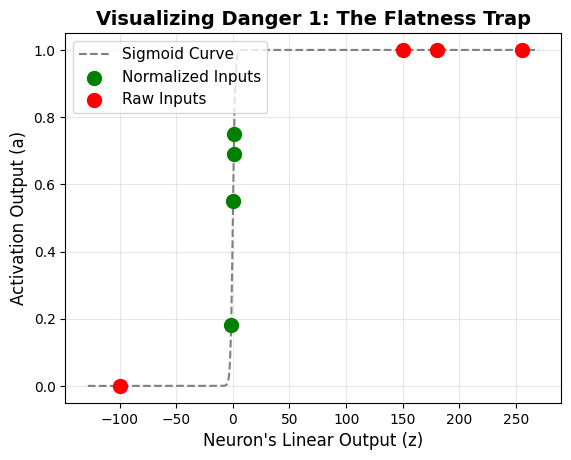

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z): #sigmoid function
    return 1 / (1 + np.exp(-z))

z_curve = np.linspace(-128, 270, 1000) #Generate 200 evenly spaced numbers from -10 (inclusive) to +10(also inclusive)
a_curve = sigmoid(z_curve) #Apply sigmoid to these generated numbers

good_inputs = np.array([-1.5, 0.2, 0.8, 1.1]) # inputs of small magnitude
bad_inputs  = np.array([-100.0, 150.0, 180.0, 255.0]) # inputs of much larger magnitudes

plt.plot(z_curve, a_curve, color='gray', linestyle='--', label='Sigmoid Curve') #z_curve sigmoid function background

plt.scatter(good_inputs, sigmoid(good_inputs), color='green', s=100, zorder=5, label='Normalized Inputs') #plot good_inputs on the graph

plt.scatter(bad_inputs, sigmoid(bad_inputs), color='red', s=100, zorder=5, label='Raw Inputs') #plot good_inputs on the graph

plt.title("Visualizing Danger 1: The Flatness Trap", fontsize=14, fontweight='bold')
plt.xlabel("Neuron's Linear Output (z)", fontsize=12)
plt.ylabel("Activation Output (a)", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left', fontsize=11)

plt.show()

If you look at sigmoid graph in the section `2.3.1: Types of activation functions` it is drawn as a gentle, curvy "S" shape. But in our graph above, it looks like a flat line, a sharp vertical cliff right around zero, and another flat line.

This squished look isn't a bug—it is the ultimate visual proof of The Flatness Trap.

The active "sweet spot" of a Sigmoid neuron is incredibly narrow, taking place almost entirely between inputs of $-6$ and $+6$. Because we zoomed out our X-axis to fit unnormalized raw pixels (from $-140$ to $290$), that beautiful "S" curve gets squished into a tiny vertical wall.
* The Green Dots (Normalized Inputs): By scaling our data down to a small range, our inputs sit safely right on that steep cliff. Here, even a tiny change in the input creates a massive change in the output. The neuron is alive, active, and highly responsive.
* The Red Dots (Raw Inputs): Because our raw pixel values are so large (like 150, 180, or 255), they are pushed miles away into the endless, flat plains on the right and left. Look at the curve under those red dots—it has zero slope. If you change a raw input from 150 to 250, the output stays stuck at exactly 1.0. The neuron becomes completely numb to changes, blinding the network and freezing its ability to learn.

* ***Danger 2 - The Snowball Effect:*** Even though we will be going to use ReLU as an activation function in our implementation, we still can't use very large values and this is because ReLU doesn't have a flatness trap on the positive side but large numbers create an equally dangerous problem: uncontrolled compounding math.

  Remember, a neural network isn't just one single neuron; it is a massive chain of layers stacked back-to-back. The output of one layer becomes the input for the next.

  Let's look at what happens if we don't "downscale" our input data and feed a large pixel value like $200$ into a network where the starting knob values (weights) happen to be set around something like $2$:
  1. Layer 1: The neuron takes the input of $200$ and multiplies it by a starting weight of $2$. The output is now $400.$
  2. Layer 2: That $400$ is passed forward as the new input and multiplied by another weight knob set to $2$. The output swells to $800$.
  3. Layer 3: The $800$ is multiplied by another weight of $2$, turning into $1,600$.

  By the time this calculation passes through just a few layers, the numbers will exponentially compound to millions, billions, and trillions!

  Also computers have a strict physical limit on how large a floating-point number can be. When network's numbers grow too massive, they overwhelm the computer's memory. The numbers will literally break the math environment, causing NumPy to crash and return nothing but NaN (Not a Number) errors.

---

Hence to feed the data to the neural network, first we need to convert it to a pure mathematical form and then we need to downscale or normalize it so as to avoid these above discussed dangers irrespective of the type of neural network or the type of activation functions used in the network.

The operations that we perform on the input data before feeding it to the nureal network such as normalization always ensure that all the information contained within the dataset is absolutely intact and unmodified in the slightest. These set of operations performed on the raw data before feeding it into the neural network is called as **"Data Pre-Processing"**.

## 6.2 Pre-processing MNIST Dataset
### 6.2.1 Pre-processing Training and Testing images
MNIST dataset is already present in the form of pixel values ranging from $0-255$. So the first step of converting the dataset into pure mathematical values is already done for us.

If you remember, inside [load_dataset function](#scrollTo=Zc95daH_uFvA&line=2&uniqifier=1) we printed the shape of raw data before the return statement.
So when we loaded our training and testing dataset the function printed:
```
(47040000,) — Raw Training Images Vector
(60000,)  — Raw Training Labels Vector
(7840000,)  — Raw Testing Images Vector
(10000,) — Raw Testing Labels Vector
```
Let's first look at the first shape `(47040000,)` and the third shape `(7840000,).`

* **`(47040000,)`:** As discussed earlier this type of shape corresponds to 1D flat numpy array. This means that the "mathematical" data of all the 60,000 images is cramped into this single large, flat 1D array. To manipulate our data effectively, we need to separate the images so each one can be accessed individually. How can we do this?  We know that each image is of 28px $ × $ 28px resolution-meaning each image can be represented as a 2D matrix of 28 rows and 28 columns. So we can just reshape or organize the current flat sequence into a 3 dimensional tensor consisting of 60,000 matrices each of 28 rows and 28 columns. Hence, the new shape will be `(60000,28,28)`. Let's write the code to do so:




In [ ]:
X_train = X_train.reshape(-1, 28, 28) #passing -1 means we are allowing numpy to automatically calculate the number of matrices needed to accomodate the original array
                                      #given each matrix contains 28 rows and 28 columns
X_train.shape

(60000, 28, 28)

Numpy automatically deduces that, exactly 60,000 matrices are needed. This fits our training dataset perfectly since we have exactly 60,000 unique handwritten digits. So if we decide to assign a matrix to each image to "hold" its pixels then obviously we will have 60,000 such matrices.
* **`(7840000,)`:** This shape represents the 10,000 images from the testing dataset cramped into single 1D large flattened numpy array. So in this case too we will exactly do what we did above with the training dataset. The only difference here is that now the shape of the resulting array will be `(10000,28,28)`.

In [ ]:
X_test = X_test.reshape(-1, 28, 28)
X_test.shape

(10000, 28, 28)

Now let's look at the remaining shapes printed by [load_dataset function](#scrollTo=Zc95daH_uFvA&line=2&uniqifier=1).

***`(60000,)`*** and  ***`(10000,)`*** these represent the 60,000 and 10,000 correct labels for the training and testing dataset. Read [section 4.1.1.2: What are Labels? ](#scrollTo=3IbPUFILxtNg) once again to recall what are labels.

Now since we have properly organized the data we need to downscale its values. To do this safely without corrupting the underlying patterns or information, we use normalization. We achieve this by dividing every single pixel value in both training as well as testing datasets by the absolute maximum possible pixel value: $255.0$.

The intution behind this normalization technique is very simple:
* If you divide an entire dataset by a common constant($255.0$ in our case), the scaling change preserves the original geometric relationships and patterns completely.
* Also if we divide a number by a number larger than the number itself then we will always end up with a smaller number and how small that resulting number is depends on how small that original number was with respect to the larger number.

So let's now normalize our training and testing datasets:


Training dataset before normalizing
Range: 0 - 255
Training dataset after normalizing
Range: 0.0 - 1.0
Testing dataset before normalizing
Range: 0 - 255
Testing dataset after normalizing
Range: 0.0 - 1.0


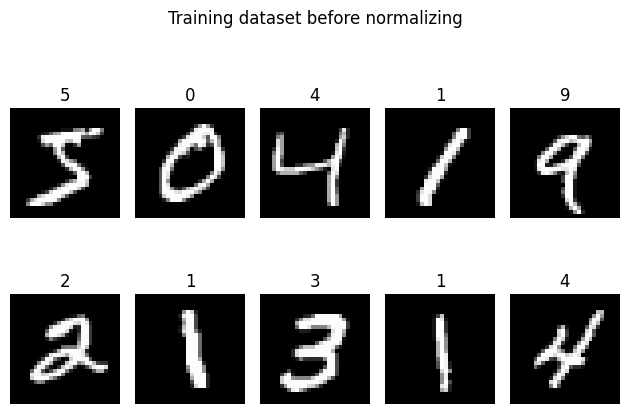

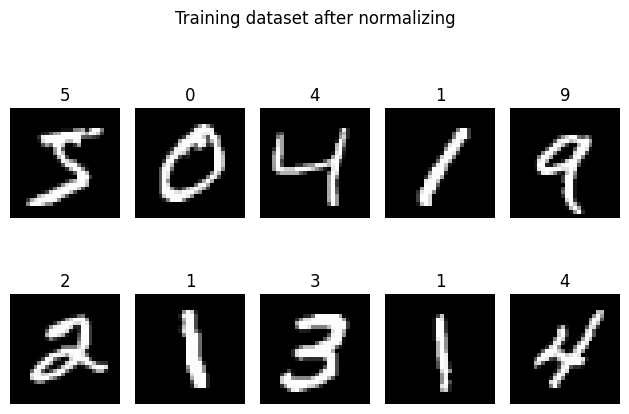

In [ ]:
import matplotlib.pyplot as plt

#Checking out the first 10 images before normalizing by plotting how they look
plt.figure()
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(Y_train[i])
  plt.axis('off')
plt.suptitle("Training dataset before normalizing")
plt.tight_layout()


print("Training dataset before normalizing")
print(f"Range: {X_train.min()} - {X_train.max()}") #Check out the range before normalizing it will be 0-255
X_train = X_train.astype(np.float32) / 255.0 #We require the result as float instead of integer so as to retain the details perfectly.
                                             #We don't want to end up loosing the information while rounding of to integers.
print("Training dataset after normalizing") # After normalizing the range will be 0.0(cause 0/255.0 = 0)  to 1.0 (255.0/255.0 = 1)
print(f"Range: {X_train.min()} - {X_train.max()}")

print("Testing dataset before normalizing")
print(f"Range: {X_test.min()} - {X_test.max()}")
X_test = X_test.astype(np.float32) / 255.0      #This is an elementwise operation meaning that we are dividing each element of our dataset by 255.0
print("Testing dataset after normalizing")
print(f"Range: {X_test.min()} - {X_test.max()}")

#Checking out the first 10 images after normalizing by plotting how they look
plt.figure()
for i in range(10):
  plt.subplot(2, 5, i + 1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(Y_train[i])
  plt.axis('off')
plt.suptitle("Training dataset after normalizing")
plt.tight_layout()
#Hence we have downscaled the dataset values from 0 to 255 to 0.0 to 1.0 while retaining all the geometric patterns and shapes exactly as they are. Check out the output of this cell!!


### 6.2.2 Pre-processing Training and testing labels
To identify pre-processing needed for the labels we need to first think about the output of our neural network. We need to classify each digit correctly. So if the output layer of the neural network contains 10 neurons each individually classifying individual digits 0-9, then we need to convert each label into a row vector which will contain value of each neuron from the output layer for correct classification of the input image according to the label.

To understand it more clearly first understand that we have 10 neurons in the output layer each corresponding to a digit from 0-9 sequentially; $0^{th}$ neuron corresponds to digit 0, $1^{st}$ neuron corresponds to digit 1, $2^{nd}$ neuron corresponds to digit 2 and so on. Each neuron fires up or its value changes to  $1$ only if the neural network thinks that the digit corresponding to that neuron is present in the input image. The value of all the other neurons except this neuron stays $0$.

So let's say we input an image of digit $5$ to the neural network then considering that it identifies that image correctly, its output layer should somewhat look like the following table:

| Neurons | Values | Corresponding Digit |
| :---: | :---: | :---: |
| 0 | 0 | 0 |
| 1 | 0 | 1 |
| 2 | 0 | 2 |
| 3 | 0 | 3 |
| 4 | 0 | 4 |
| 5 | 1 | 5 |
| 6 | 0 | 6 |
| 7 | 0 | 7 |
| 8 | 0 | 8 |
| 9 | 0 | 9 |

Only the neuron corresponding to digit $5$ has value $1$, rest all neurons have $0$ as their values.

This means we need to transform our simple scalar labels (like the integer 5) into a vector format that matches our 10-neuron output layer. In this target vector, the index equal to our label must be set to 1, while all other values are set to 0. This technique is called **One-Hot Encoding**. The following table illustrates a few examples of One-Hot Encoding applied to our use case

|Label|Vector|
|:---:|:---:|
|5| $\begin{bmatrix} 0 & 0 & 0 & 0 & 0 & 1 & 0 & 0 & 0 & 0 \end{bmatrix}$
|0| $\begin{bmatrix} 1 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 \end{bmatrix}$
|8| $\begin{bmatrix} 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 & 0 \end{bmatrix}$
|9| $\begin{bmatrix} 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 0 & 1 \end{bmatrix}$

To create these One-Hot Encoded Vectors we will first create a common identity matrix by using `np.identity(10)`. This will create a 10$×$10 identity matrix. This matrix is actually nothing but One Hot Encoded Label Vectors for labels 0-9 stacked together sequentially. Once we have that, we will do numpy's "magic indexing" which will assign a vector from this matrix automatically to its corresponding label.

To understand more clearly, let's first create a 10$×$10 identity matrix:

In [ ]:
eye = np.identity(10)
eye

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

As you can see from the output the first row of this matrix (row index 0) is One Hot Encoded Vector for label 1(label index 0), similarly the second row (row index 1)corresponds to label 2(row index 1), so on and so forth.

In [ ]:
print("First element or label of Y_train before encoding: ", Y_train[0])
print("First element or label of Y_test before encoding: ", Y_test[0])
Y_train = eye[Y_train]
Y_test = eye[Y_test]
print("First element or label of Y_train after encoding: ", Y_train[0])
print("First element or label of Y_train after encoding: ", Y_test[0])

First element or label of Y_train before encoding:  5
First element or label of Y_test before encoding:  7
First element or label of Y_train after encoding:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
First element or label of Y_train after encoding:  [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


As you can see from the output we now have One Hot Encoded each label with its correct corresponding encoded row vector.

---
# 7. Forward Pass
## 7.1 Designing architecture of NN
Now since we have our data ready we can start feeding the data into the neural network. But before that, we must map out the structural layout of our model's layers.

Our neural network will follow a 3-layer architecture (excluding the input layer, as it performs no calculations):
* **Input Layer:** Since each image is of 28px$×$28px and is present in the form of 28$×$28 matrix in our dataset, hence to feed one complete image to the neural network we will require $28 × 28 = 784$ neurons where each neuron will be dedicated to a single pixel value from that image. Hence we need to have 784 neurons in our Input Layer.
  * In machine learning, any raw piece of data the network uses to make a prediction is called a Feature. In our case, the network relies on 784 raw pixel values, meaning our dataset contains 784 features. The number of neurons in an input layer always equals the exact number of features required by the problem.
* **Hidden Layers:** The number of hidden layers and the number of neurons present in the hidden layer are architectural choices left up to the programmer(often called hyperparameters). This choice is influenced by the complexity of the problem and computational efficiency. For learning purposes, we will keep our model simple and lean by using **two hidden layers containing 16 neurons each.**
* **Output Layer:** Because we are building a multi-class classification model targeting 10 unique options (the digits 0 through 9), our final layer must contain exactly 10 output neurons, as established during our one-hot encoding design.

So our architecture of neural network is this: <br>
784 neurons ---> 16 neurons ---> 16 neurons ---> 10 neurons <br>

Input Layer--->Hidden Layer1--->Hidden Layer2--->Output Layer

### 7.1.1 Data Pre-Processing -- The Last Step
This step was skipped earlier because it directly depends on the number of neurons present in the Input Layer.

Since we have 784 neurons in the Input Layer, we cannot directly pass it 2D 28$×28$ matrix. We need to pass the image in the form of a vector, either row vector (1, 784) or column vector (784, 1). By convention we will choose to work with row vector (but it doesn't matter once you understand the math and shape management).

So let's complete this last step of data pre-processing by reshaping the training and testing dataset. This means that we now change X_train(training dataset) from a 3D tensor of shape (60000, 28, 28) to 2D matrix of shape (60000, 784) represents one distinct image holding 784 pixels sequentially, giving us 60,000 rows. We will apply this same reshaping to X_test(testing dataset) too, except in this case since we have 10,000 images hence the resulting shape will be (10,000, 784).

In [ ]:
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)
print(X_train.shape)
print(X_test.shape)

(60000, 784)
(10000, 784)


### 7.1.2 Choosing Activation Functions
Now that we have designed the skeleton of our architecture, we need to choose the "gatekeepers" (activation functions) for our layers. We will not use the same activation function across the entire network. Instead, we use different functions tailored to what each section of the network needs to accomplish.

* **ReLU for Hidden Layers $(a = max(0, z))$:** For our two hidden layers, we will use ReLU (Rectified Linear Unit). It is a gold standard for hidden layers in modern NNs due to two primary reasons:
  * **Immunity to the Flatness Trap:** As we demonstrated visually in our pre-processing section, older functions like Sigmoid flatten out (zero-slope) for large numbers, completely freezing the network's ability to learn. ReLU is a straight diagonal line on its positive side. Its slope is always exactly 1.0, meaning it never saturates or chokes on large values. This ensures our network trains quickly and stably.
  * **Computational Efficiency:** Calculating exponential curves like Sigmoid millions of times requires serious computer processing power. ReLU only requires checking if a number is greater than zero $(max(0, z))$. For a computer, this is very fast, allowing us to train deeper networks much faster.
* **Softmax for Output Layer $ \left(σ(z)_i = \frac{e^{z_i}}{∑_{j=1}^K e^{z_j}}\right)$:** For the final output layer we will use Softmax. Our network needs to classify handwritten digits into 10 distinct classes (0 through 9). If we used ReLU on the output layer, the network would output raw, arbitrary numbers like `[12.5, 0.0, 150.2, ...]`. It is impossible to interpret how confident the network is based on those numbers. In other words we need to convert the networks output into significant meaningful output and using ReLU as activation function won't allow us to do that.

  Softmax solves this by looking at all 10 output neurons together. It takes those raw, chaotic numbers and compresses them into a clean probability distribution, as discussed earlier in Softmax activation function section:
    * Every individual output value is forced into a range between 0.0 and 1.0.
    * The sum of all 10 outputs combined is always exactly 1.0 (100%).
  If the neuron matching the digit 5 outputs 0.85, while the others output tiny numbers, we can clearly read that the network is 85% confident that the input image is a 5. This also matches our One-Hot Encoded labels perfectly.
Here is a clear example of pre activated (zs) and softmax activated values of neurons in the output layer:
<center>

| **Neuron index** | **z** | **a** | Confidence (a$×$100) |
| :---: | :---: | :---: | :---: |
| 0 | 0.1 | 0.0128 | 1.28% |
| 1 | -1.2 | 0.0035 | 0.35% |
| 2 | 2.3 | 0.1153 | 11.53% |
| 3 | 0.5 | 0.0191 | 1.91% |
| 4 | -0.5 | 0.0070 | 0.70% |
| 5 | 4.2 | 0.7709 | 77.09% |
| 6 | 1.1 | 0.0347 | 3.47% |
| 7 | -2.0 | 0.0016 | 0.16% |
| 8 | 0.8 | 0.0257 | 2.57% |
| 9 | -0.2| 0.0095 | 0.95% |
</center>

From this confidence values we can say that our network has classified input image as 5 with confidence score of 77%. Since this is the highest confidence score hence we can interpret it as *"the network thinks that the input image is of digit 5"*.



---
## 7.2 Indexing for neural network parameters
Before going further its very important to ourselves with standard indexing conventions. In the following explanation, element of NN refers to any of the weights(ws), biases(bs), pre-activated outputs of neurons(zs), activated outputs of neurons(as) and a neuron itself.
<center>
<img src="https://www.researchgate.net/profile/Pushparaj-Pal/publication/380604049/figure/fig1/AS:11431281244113959@1715843984736/Architecture-of-deep-neural-network-DNN-13-15.png" width=500>
</center>

Look at this neural network, the following explanation is in context to this architectural diagram of NN. To represent any element belonging to a particular layer the symbol of that element is given a superscript indicating the layer index. Also,the layers are indexed from 0:
* **Layer 0:** $L^0$ - Input Layer
* **Layer 1:** $L^1$ - Hidden Layer
* **Layer 2:** $L^2$ - Hidden Layer
* **Layer 3:** $L^3$ - Output Layer
### 7.2.1 Neurons
Neurons are often represented by the symbol of their activated output (a). The following table maps how we represent the collective neurons of each layer:
<center>

| Layer Index | Neurons | Meaning |
| :---: | :---: | :---: |
| $0$ (Input Layer) | $a^0$ | All input features (raw pixels) |
| $1$ (Hidden Layer 1) | $a^1$ | All activation outputs of Hidden Layer 1 |
| $2$ (Hidden Layer 2) | $a^2$ | All activation outputs of Hidden Layer 2 |
| $3$ (Output Layer) | $a^3$ | All activation outputs of the Output Layer |
</center>

An individual neuron of a particular layer can be represented as follows:
<center>

| Layer Index | Neurons Index | Notation | Meaning |
| :---: | :---: | :---: | :---: |
| $0$ (Input Layer) | 2(3rd Neuron) | $a^0_2$ | The 3rd input feature |
| $1$ (Hidden Layer) | 1(2nd Neuron) | $a^1_1$ | The 2nd neuron of Hidden Layer 1 |
| $2$ (Hidden Layer) | 3(4th Neuron) | $a^2_3$ | TThe 4th neuron of Hidden Layer 2 |
| $3$ (Output Layer) | 0(1st Neuron) | $a^3_0$ | The 1st neuron of the Output Layer |
</center>

### 7.2.2 Weights


The weights of the neural network can be visually associated with the arrows present between the layers in the NN. The entire set of weights pointing into a specific layer is represented by $w^{L}$. Visually, $w^{L}$ represents all connection arrows traveling into the neurons of Layer L:

<center>

| Destination Layer Index | Collective Weight Matrix |
| :---: | :---: |
| $1$(Hidden layer1) | $w^1$ |
| $2$(Hidden layer2) | $w^2$ |
| $3$(Output layer2) | $w^3$ |
</center>

Obviously $w^0$ is never possible because Input layer does not perform any operation on the input dataset and hence it has no weights associated to it.

An individual weight connecting two single neurons is written as $w_{ij}^{L}$. In this notation:
* **L:** The destination layer (where the arrow points).
* **i:** The specific neuron in destination layer L (where the arrow lands).
* **j:**  The specific neuron in the preceding layer L-1 (where the arrow originates).
<center>

| Destination Layer (L) | Target Neuron (i) | Origin Neuron (j) | Notation |
| :---: | :---: | :---: | :---: |
| $1$(Hidden Layer) | $2$(Third Neuron) | $3$(Fourth Neuron) | $w^1_{23}$ |
| $2$(Hidden Layer) | $3$(Fourth Neuron) | $1$(Second Neuron) | $w^2_{31}$|
| $3$(Output Layer) | $2$(Third Neuron) | $0$(First Neuron) | $w^3_{20}$  |
</center>

### 7.2.3 Biases
Set of biases for a particular layer of index 'L' is represented by $b^L$.
<center>

| Layer Index | Bias |
| :---: | :---: |
| $1$(Hidden layer1) | $b^1$ |
| $2$(Hidden layer2) | $b^2$ |
| $3$(Output layer2) | $b^3$ |
</center>

Since neurons in input layer do not perform any mathematical operations on the input data hence $b^0$ is never possible.

Bias of an individual neuron is represented by $b^L_i$ where L is the index of layer neuron belongs to and i is the index of the neuron.
<center>

| Layer Index | Neuron Index | Notation |
| :---: | :---: | :---: |
| $1$(Hidden layer1) | $1$(Second Neuron) | $b^1_1$ |
| $2$(Hidden layer2) | $3$(Fourth Neuron) | $b^2_3$ |
| $3$(Output layer2) | $0$(First Neuron) | $b^3_0$ |
</center>

### 7.2.4 Pre-Activated Outputs (zs)
A set of zs for a particular layer and z of an individual neuron are represented with the exact same conventions followed to represent biases.

The collective pre-activations for an entire layer:
<center>

| Layer Index | Notation |
| :---: | :---: |
| $1$(Hidden layer1) | $z^1$ |
| $2$(Hidden layer2) | $z^2$ |
| $3$(Output layer2) | $z^3$ |
</center>

The raw pre-activation values for individual neurons:
<center>

| Layer Index | Neuron Index | Notation |
| :---: | :---: | :---: |
| $1$(Hidden layer1) | $2$(Third Neuron) | $z^1_2$ |
| $2$(Hidden layer2) | $3$(Fourth Neuron) | $z^2_3$ |
| $3$(Output layer2) | $0$(First Neuron) | $z^3_0$ |
</center>

---

## 7.3 Initializing parameters
### 7.3.1 Initializing Weights
We know that we require a set of weights $w^L$ for each layer $L$, except for the Input Layer i.e. $L =0$. From these set of weights each weight connects a pair of neurons: one neuron from layer $L-1$ and another neuron from layer $L$.

The neural network that we will implement has 3 layers (ignoring input layer), so we will require 3 sets of neurons:
* **$w^1$:** Weights for Hidden Layer 1
* **$w^2$:** Weights for Hidden Layer 2
* **$w^3$:** Weights for Output Layer 3

We can represent these set of weights required for any layer $L$ as a 2D matrix.By coding convention, we will arrange this matrix such that the rows represent the sending neurons $(j)$ from layer $L-1$, and the columns represent the receiving neurons $(i)$ from layer $L$. **This means for our weight matrix configuration, rows correspond to the index j and columns correspond to the index i.**

For Hidden Layer 1 the arrows of weights originate from 784 neurons in the input layer $(L-1)$ and point to 16 neurons of the hidden layer 1 $(L)$.

$$w^1 = \begin{bmatrix}
w^1_{0,0} & w^1_{1,0} & \dots & w^1_{15,0} \\
w^1_{0,1} & w^1_{1,1} & \dots & w^1_{15,1} \\
\vdots & \vdots & \ddots & \vdots \\
w^1_{0,783} & w^1_{1,783} & \dots & w^1_{15,783}
\end{bmatrix}_{(784 \times 16)}$$

For Hidden Layer 2 the arrows of weights originate from 16 neurons in the hidden layer 1 $(L-1)$ and point to 16 neurons of the hidden layer 1 $(L)$.

$$w^2 = \begin{bmatrix}
w^1_{0,0} & w^1_{1,0} & \dots & w^1_{15,0} \\
w^1_{0,1} & w^1_{1,1} & \dots & w^1_{15,1} \\
\vdots & \vdots & \ddots & \vdots \\
w^1_{0,15} & w^1_{1,15} & \dots & w^1_{15,15}
\end{bmatrix}_{(16 \times 16)}$$

For Output Layer the arrows of weights originate from 16 neurons in the hidden layer 2 $(L-1)$ and point to 10 neurons of the output layer $(L)$.

$$w^3 = \begin{bmatrix}
w^1_{0,0} & w^1_{1,0} & \dots & w^1_{10,0} \\
w^1_{0,1} & w^1_{1,1} & \dots & w^1_{10,1} \\
\vdots & \vdots & \ddots & \vdots \\
w^1_{0,15} & w^1_{1,15} & \dots & w^1_{10,15}
\end{bmatrix}_{(16 \times 10)}$$

From the above matrices we can clearly observer that the shape of:
* $w^1$ is $(784, 16)$
* $w^2$ is $(16, 16)$
* $w^3$ is $(16, 10)$

Now, the next logical question is: What should the initial values of these weights be?

To answer this question we need to consider following scenarios:
* **Large values:** Initializing weights with large numbers will instantly trigger the Snowball Effect we discussed during data pre-processing. As the values pass through the layers, the numbers will explode exponentially, crashing our code with `NaN` errors.
* **Near-Zero or Very small Values:** Making earlier weight values very small or near 0 can result in opposite problem. The neuron outputs will become so tiny that by the time they reach the deep layers, the signals will vanish entirely, resulting in a severe loss of information.

This means we need to find a mathematical "sweet spot" that sits safely between these two extremes. But should these initial weights be exclusively positive numbers?

Let's bring back our initial music concert example. Ticket cost is a negative factor—a higher price should decrease your chances of going. If we initialized all weights as positive numbers, the high ticket price would accidentally increase the final score, completely reversing the logic of the problem!

Because a brand-new neural network has no idea which features (pixels) have a positive or negative impact on which specific digit classes, we must initialize the weights with a balanced mix of equal positive and negative values. This removes any statistical initial bias, that the NN might have otherwise and provides it a fair and neutral starting line from which it can accurately learn.

This mathematical "sweet spot" can be precisely calculated by defining an optimal boundary range. For any given weight matrix $w^{L}$, the initial weight values should be drawn uniformly between a minimum value (inclusive) and a maximum value (exclusive).

This bounded range is determined by the number of incoming connections from the previous layer, given by the formula:
<center> $$ \left (- \frac{1}{\sqrt{\text{no. of neurons in L - 1}}}, \frac{1}{\sqrt{\text{no. of neurons in L - 1}}} \right]$$</center>

There are various ways to initialize weights depending on the choice of activation function such as Xavier and He initialization. The method we just calculated is one of the most foundational, known as LeCun Initialization. In this notebook, we continue using LeCun Initialization because it is simple, mathematically intuitive, and performs well for our small educational network. Modern deep learning models using ReLU often prefer He Initialization, which slightly adjusts the initialization range to better preserve the variance of activations in deeper networks.

For now let's actually initialize the three weight matrices using uniform distribution with our calculated boundary:

In [ ]:
from numpy.random import default_rng

rng = default_rng() #Initialize numpy's random number generator

limit = 1 / np.sqrt(784) #for w1 L-1 layer (i.e input layer) contains 784 neurons
w1 = rng.uniform(low=-limit, high=limit, size=(784, 16)) #generates random but uniformly distributed values within the given boundary; size helps to specify the shape of the resulting matrix
                                                         #in gerneal shape of weight matrix w^L is given by (no. of neurons in L-1, no. of neurons in L)

limit = 1 / np.sqrt(16) #for w2 and w3 L-1 layers(i.e. hidden layer 1 and hidden layer 2 respectively) have 16 neurons
w2 = rng.uniform(low=-limit, high=limit, size=(16, 16))
w3 = rng.uniform(low=-limit, high=limit, size=(16, 10))

### 7.3.2 Intializing Biases
Since each neuron has its own bias, we need a separate bias value for each individual neuron. To represent a collection of biases $b^L$ for a layer, we can use row vector of shape (1, no. of neurons in L). So each value from this row vector will correspond to a single neuron's bias.

Unlike weights biases are easier to initialize. We simply set all initial bias values to 0. Unlike in case of weights we can do this because:

* If all weights start at zero, every neuron calculates the exact same output, paralyzing the network's ability to learn distinct features.

* However, because biases simply shift the activation function left or right along the graph, starting them at zero simply means every neuron begins at a perfectly neutral baseline. The biases will naturally update and shift away from zero as the network begins to learn.

Let's now initialize the three bias row vectors:

In [ ]:
b1 = np.zeros((1, 16))
b2 = np.zeros((1, 16))
b3 = np.zeros((1, 10))

---

## 7.4 Implementing Forward Pass
### 7.4.1 Implementing Activation functions
As discussed earlier, in section [7.1.2 Choosing Activation Functions](#scrollTo=C7RxTXgcDENG&line=15&uniqifier=1), we are using ReLU for two hidden layers and Softmax for output layer. So let's first implement ReLU $(a = max(0, z))$:


In [ ]:
def relu (x):
  return np.maximum(0, x) #compares each element of x (element-wise) with 0 and returns the element if it is greater than 0 else returns 0

To implement softmax we can't use the raw softmax function:
<center> $$σ(z)_i = \frac{e^{z_i}}{∑_{j=1}^K e^{z_j}}$$ </center>

While the formuala itself is correct, it is numerically unstable in a computer's memory, because of large exponentiations. . If a neuron outputs a raw score of even just 100, calculating $e^{100}$ produces an astronomical number that physically overflows your computer's floating-point capacity, crashing your code with `NaN` errors.

To solve this problem, we use stable softmax trick:
<center>
$$σ(z)_i = \frac{e^{z_i - m}}{∑_{j=1}^K e^{z_j - m}}$$
</center>

Here, $m = max(z)$, represents maximum raw score within the specific output layer vector. This mathematically guarantees that the largest value becomes exactly $0$ $(e^0 = 1)$, and all other numbers become negative (resulting in exponentials between $0$ and $1$). This simple shift leaves the final percentages completely unchanged while ensuring our code runs stably and never overflows. So now let's implement this stable softmax in our code:



In [ ]:
def softmax(x):
  return np.exp(x - np.max(x)) / np.sum(np.exp(x - np.max(x)))
  #First we calculate e raised to (x - max(x)) for all the elements in x then we divide each of this element by the sum of e raised to x - max(x) for each element in x
  # All the operations performed here are element wise, except np.sum(), which is an aggregration operation which takes in a vector as input and gives a sinlge scalar as its output.
  # this function is correct for now (for a single image), but few modifications must be done later on when we will process multiple images in the following sections of the notebook.

### 7.4.2 Coding the Network Layers
Implementing the forward pass is simply a matter of combining all the knowledge from our previous sections and executing the two foundational neuron equations we learned earlier:
<center>
The linear function which is: <br>
$$z = \sum_{i=1}^n x_i w_i + b$$

<br>
and the non-linear activation function called activation function:
<br>
$$ a = σ(z) $$
</center>

The final piece of the puzzle is understanding how we use a dot product to calculate the summation $\sum _{i=1}^{n}x_{i}w_{i}$ efficiently across an entire layer.

Here, the inputs $x$ and weights $w$, both are matrices (as explained earlier a vector, is also indirectly a matrix). Since we have fully connected layers hence every neuron's output from the preceding layer needs to be provided as an input for each neuron present in the current layer. For example: output of 0th neuron will be provided as an input to all the 16 neurons of first hidden layer and so will be the outputs of every other remaining 783 neurons from the input layer.<br>

This means that $a^{L-1}_i$ becomes $x_i$ for each neuron present in the layer L.

Every such connection between a neuron from previous layer and a neuron from the current layer is associated with a certain weight that is stored in matrix $w$. Hence we need to add up all such connections for the current neuron in the current layer, where each connections is defined by the product of $x_i$ and $w_i$. This is exactly what dot product between two matrices does.

To make it crystal clear, consider this example: Imagine we have a tiny, simple neural network. It has an Input Layer (Layer L=0) with only 2 neurons, which connects to a hidden layer with 3 neurons(Layer L=1).

Hence our input row vector will simply be of shape (1, 2). Consider the following as the input row vector:
<center>
$x=\left[\begin{matrix}4.0&5.0\end{matrix}\right]_{(1\times 2)}$
</center>

Since the input layer does no processing on the input vector hence:
* $a^0_0 = 4.0$ (0th neuron in the input layer)
* $a^0_1 = 5.0$ (1th neuron in the input layer)

The weight matrix for layer L=1 will be of shape (2, 3). Consider the following as the weight matrix:
<center>
$w=\left[\begin{matrix}0.2&0.1&-0.3\\ 0.5&-0.4&0.2\end{matrix}\right]_{(2\times 3)}$
</center>

In this matrix:
* Row 0 holds the weights originating from 0th input neuron($a^0_0$): 0.2 (points to hidden Neuron 0, $a^1_0$), 0.1 (points to hidden Neuron 1, $a^1_1$), and -0.3 (points to hidden Neuron 2, $a^1_2$)
* Row 1 holds the weights originating from our 1st input neuron($a^0_1$): 0.5 (points to hidden Neuron 0, $a^1_0$), -0.4 (points to hidden Neuron 1, $a^1_1$), and 0.2 (points to hidden Neuron 2, $a^1_2$).

Then dot product $x \cdot w$ is calculated as follows:<br>
Neuron 0 calculation ($a^1_0$):

We multiply our inputs by the 0th column of the weight matrix (0.2 and 0.5):
<center>
$z_{0}=(4.0\times 0.2)+(5.0\times 0.5) \\ z_{0}=0.8+2.5=\mathbf{3.3}$
</center>

Neuron 1 calculation ($a^1_1$):

We multiply our inputs by the 1st column of the weight matrix (0.1 and -0.4):
<center>
$z_{1}=(4.0\times 0.1)+(5.0\times -0.4) \\ z_{1}=0.8+(-2.0)=\mathbf{-1.6}$
</center>

Neuron 2 calculation ($a^1_2$):

We multiply our inputs by the 2nd column of the weight matrix (-0.3 and 0.2):
<center>
$z_{2}=(4.0\times -0.3)+(5.0\times 0.2) \\ z_{2}=-1.2+(1.0)=\mathbf{-0.2}$
</center>

NumPy bundles these three individual neuron outputs back into a clean 2D row matrix format. The resulting matrix $z$ has 1 row and 3 columns, matching our shape of (1, 3) perfectly:
<center>
$z=x\cdot w=\left[\begin{matrix}3.3&-1.6&-0.2\end{matrix}\right]_{(1\times 3)}$
</center>

As you can see, the dot product effortlessly calculated the unique combined influence of all input neurons for every single neuron in our next layer, completely bypassing the need for tedious manual math.



> **Remember these 3 points throughtout the notebook:**
> * **Anytime we require to condense all the information from two matrices into a single scalar we will use dot product.**
> * **To perform dot product operation on two matrices of shape $(p, q)$ and $(r, s)$ $q=r$ must be true, i.e. the inner dimensions must be the same, else dot product is not possible.**
> * **The matrix resulting from dot product between two matrices of shape $(p, q)$ and $(r, s)$, where $q=r$, always has $shape =(p, s)$**



So now let's actually write down the two equations of a neuron to calculate all the neuron outputs for each layer:


In [ ]:
#The input layer does no processing hence the output of input neurons is equal to the input data itself.
#For simplicity we will first use only the first image of training dataset:
img1 = X_train[0].reshape(1, 784)
print(f"Shape of img1 row vector: {img1.shape}\nShape of w1 matrix: {w1.shape}")
z1 = np.dot(img1, w1) + b1 #this performs neuronwise dot products and returns a matrix of shape (1, 16) to which we will add bias of each neuron i.e. b1 row vector.
                           #Here we perform elementwise addition between the resultant matrix of np.dot(img1, w1) and b1
                           #Hence finally z1 will be row vector of shape (1, 16) containing pre-activated outputs of each neuron from layer L=1
print("Shape of z1 row vector: ", z1.shape)
#Now we will apply activation function and get the activated outputs of each neuron in row vector a1.
a1 = relu(z1)
print("Shape of a1 row vector: ", a1.shape) #the shape will obviously be exactly equal to the shape of z1 as we are performing element wise operations inside the defined relu function

#Since we have two one more hidden layer we will repeat the same steps again, to calculate the output of neurons in layer L=2
z2 = np.dot(a1, w2) + b2 #since hidden layer 2 will receive the outputs of neurons in hidden layer 1 as input and since w2 is weight matrix for layer L=2,
                         #hence we will pass a1 and w2 to dot() and then finally add the biases of neurons in layer L=2
a2 = relu(z2)
print("Shape of a2 row vector: ", a2.shape)

z3 = np.dot(a2, w3) + b3
a3 = softmax(z3) #as decided earlier the output layer L=3 will have softmax activation funciton instead of relu
print("Shape of a3 row vector: ", a3.shape)

#Notice how the shapes of each a^L row vectors equal to (1, no of neurons in L). This helps to verify if our math is correct.

Shape of img1 row vector: (1, 784)
Shape of w1 matrix: (784, 16)
Shape of z1 row vector:  (1, 16)
Shape of a1 row vector:  (1, 16)
Shape of a2 row vector:  (1, 16)
Shape of a3 row vector:  (1, 10)


---
### 7.4.3 The Loss Function
#### 7.4.3.1 Understanding the Loss Function
Since we have passed the first image to the network let's view what the network predicts for the first image.
Given a vector we can use `np.argmax()` to get the index of the largest element among other elements of the vector.

If we use this function on the first One-Hot Encoded Vector from our training labels dataset then we will get the label of the first image i.e. which digit the first image from the training dataset contains.

Similarly if we use this function on the activations of the output layer of neurons $(a^3)$ then it will return the index of the neuron having the highest $a$ or confidence, meaning what digit does the network predicts from the given image.

In [ ]:
print("Actual digit in img1: ", np.argmax(Y_train[0]))
print("Digit calassified by NN: ", np.argmax(a3))

Actual digit in img1:  5
Digit calassified by NN:  8


Notice from the above prints, the prediction of the image by NN is not even close to the actual digit, let alone correct(in rare cases it maybe correct but that's just due to lucky weight initialization). So we need to tune the "knobs" or parameters of the NN so that it matches the correct output. But to do that,first we need some quantifiable measurement of ***"how much wrong is NN in comparison to the actual output"***.

This exactly is the use of Loss function. It quantifies how "off" the network's prediction is from the actual goal.

#### 7.4.3.2 Types of Loss Function
Just like there are different activation functions for different purposes, there are different loss functions depending on the type of problem NN is trying to solve. Let's look at the two of the most common ones:
1. **Mean Squared Error (MSE):** This is the most common loss function used for Regression problems (where the network needs to predict a continuous, real-world number rather than a category).
  * Examples: Predicting the price of a house, predicting tomorrow's temperature, or guessing a person's age
  *  It takes the network's numerical guess, subtracts it from the actual true value to find the error, and then squares that error. Finally, it averages these squared errors across all the data samples.
  <center>
  $\text{MSE} = \frac{1}{n}\sum_{i=1}^n (y_i - \hat{y}_i)^2 \\ \text {Here, } \hat{y}_i \text{ is NN predicted value and } \\ y_i \text { is the label or the true value}$
  </center>

2. **Categorical Cross-Entropy (CCE):** This is the loss function used for Multi-Class Classification problems, which matches our MNIST digits classification perfectly.
  * It expects the output layer to contain multiple neurons utilizing a Softmax activation function (giving a clean probability distribution that sums to 1.0). It measures how well the network distributes its confidence across all the available categories, heavily penalizing it if it assigns a low percentage to the true, correct class.
  * For a single image, the mathematical formula for Categorical Cross-Entropy is:<br>
  <center>
  $\text{Loss} = -\sum_{i=1}^{K} y_i \ln(p_i)$<br>$y_i = \text{the true label value for class } i \text{ (from our One-Hot vector)}$<br>$p_i = \text{the network's predicted Softmax probability for class } i$<br>$K = \text{the total number of classes (10 in our case)}$
  </center>

  * Because our true labels are One-Hot encoded (filled with zeros except for a single 1 at the correct digit), all the incorrect classes get multiplied by zero and disappear from the math. The formula simplifies to looking only at the correct target class:
  <center>
  $\text{Loss} = -\ln(p_{\text{correct}})$
  </center>

  * This function proves to be extremely useful over other loss functions like MSE for Softmax and Multi-Class Classification problems because:
    * **MSE causes learning to stall:** When the network is confidently wrong (e.g., guessing a 3 with high confidence when it is actually a 5), combining MSE with Softmax causes the mathematical curves to become completely flat. This creates a zero-slope situation where learning completely freezes exactly when the network needs to make its biggest corrections.
    * **CCE creates a perfect mathematical union:** The logarithm $(\ln )$ in CCE is the exact mathematical inverse of the exponential $(e^{z})$ used inside Softmax. When used together, they cancel each other's flattening effects out perfectly. This leaves the network with a clean, strong update signal that is always directly proportional to its error, ensuring the parameters(knobs) can be adjusted quickly and smoothly without ever freezing up. This is illustrated in detain in the backpropagation section of this notebook.

#### 7.4.3.3 Implementing Categorical Cross Entropy
From the above explanation it's crystal clear that we will use Categorical Cross Entropy (CCE) as the Loss function for our NN.
<center>
  $\text{Loss} = -\sum_{i=1}^{K} y_i \ln(p_i)$
</center>

To implement this formula, we need to negate the sum of the results of the element-wise products of our label matrix $y_{i}$ and the natural log of our probabilities $\ln(p_i)$ (the confidence from each output neuron).

However, we need to take a precaution when writing this in code: if our network is completely certain that an image does not belong to a class and it outputs a probability of exactly 0.0. In pure mathematics, the natural log of zero approaches negative infinity $ (-\infty) $, which will instantly freeze our computations and break the entire network.

By adding $e^{-15}$ to the probabilities of the neurons inside the natural log we ensure that $\ln(0)$ is actually never computed. Because the added value is drastically small (almost 0) it leaves the final loss scores completely unaffected.


In [ ]:
def cross_entropy(y_i, p_i):
  return -np.sum(y_i * np.log(p_i + 1e-15))

#computing the loss of NN
loss = cross_entropy(Y_train[0], a3) #a3 are the softmax activated outputs of neurons in the output layer which are nothing but probabilites/confidence scores of each class
print("Loss: ", loss)


Loss:  2.2730563715098855


---

This concludes the **"Forward Pass"**. In summary, the forward pass is simply the process of passing our data through the neural network once and calculating a loss score to see how far off our predictions are from the true answers.

Now that the neural network has a concrete, quantifiable measurement of exactly how incorrect it is, thanks to the loss function, we can move ahead and start tuning the "knobs" or parameters of the network to fix its mistakes. This corrective phase is exactly what happens in the "Backward Pass".

---

# 8. Backward Pass

As explained earlier, the backward pass is the process of tuning the parameters (the weights and biases) of the network based on the loss score that was calculated during the forward pass.

To tune these parameters, we use a foundational technique called "Gradient Descent". While there are advanced optimization algorithms like Adam or even completely different approaches like Evolutionary Algorithms, Gradient Descent remains the absolute bedrock of machine learning. Master the basic mechanics of Gradient Descent first, and all the advanced industry optimization techniques become much easier to understand because they are all built directly on top of its core mathematical principles.

## 8.1 Understanding Gradient Descent

The classic and most famous explanation to understand Gradient Descent is: <br>
Imagine you are stuck on a mountain at a completely random starting point. The weather is incredibly foggy, and you have zero visibility. Your ultimate goal is to get down to the base of the mountain as quickly as possible, but you cannot see a clear path because of the fog.

Instead of walking blindly and guessing, you use a clever strategy: you stand completely still and carefully feel the exact slope of the ground beneath your feet. Even without seeing the rest of the mountain, you can tell exactly which way tilts downhill. You take a small, controlled step in that precise downhill direction.

Once you keep your foot down, you stop, reassess the slope under your feet again, and take another step in the new downhill direction. By repeating this process over and over again—feeling the local slope and taking a step directly downward—you will eventually navigate through the fog and safely reach the bottom of the mountain.

This is exaclty how Gradient Descent works.
Let's map this adventurous mountain trek directly to our NN:
* **The Foggy Mountain:** This represents the **Loss Landscape** (a giant mathematical map of all the calculated losses or errors during the forward pass). The peaks of the mountain represent high loss (least accurate predictions), and the base of the mountain represents the lowest possible loss (perfect predictions).

* **The Starting Point:** The random point where you start stuck in the fog represents the initial knob settings (randomly initialized parameters) of a naive, brand-new neural network.

* **You - Gradient Descent:** You are the Gradient Descent Algorithm. Your job is to calculate the steepness of the error (the slope) right where you are standing and use that information to turn the knobs in the direction opposite to the slope so you move downhill and reduce this error.

### 8.1.1 Understanding Gradient Descent Mathematically
The fundamental mathematical equation of Gradient Descent is:
<center>
$ θ := θ - α∇J(θ)$
</center>

Here,
* $θ$ represents the parameters (weights and biases) being updated.
* $α$ is called learning rate.  It controls the size of each step taken in the direction of descent — a larger value means bigger steps, and a smaller value means more cautious, smaller steps.
* $∇J(θ)$ are the gradients of the parameters being updated. The gradient is a vector that points in the direction of steepest ascent in the loss landscape, and its magnitude tells us how steep that ascent is. Since we want to minimize the loss, we move in the direction opposite to it — hence the negative sign before $∇J(θ)\nabla J(\theta)$
* $:=$ is the assignement operator, meaning that the values of the older parameters are replaced by the newer values.

Mathematically, the objective of Gradient Descent is to find a point of sufficiently low loss within the error/loss landscape. We take small steps along the loss landscape in the direction opposite to the gradient — which is the direction of steepest descent — and repeatedly update the weights and biases so that the loss with the updated values can be re-evaluated to find the next direction to move in.

<center>
<img src="https://miro.medium.com/v2/1*2Y-5oNOwMG2p3Jr3F4hU6A.gif" width=400>
</center>

The above GIF perfectly illustrates how standard gradient descent works. The color transition of the landscape from red to blue corresponds to the transition from very high loss to minimum loss. The ball rolling downhill is a visualization of how, step by step, we move toward a region of low loss. Since our visualization is limited to 3 dimensions, the graph above assumes we have only 2 parameters to update. For any number of parameters greater than 2, the loss landscape easily exceeds 3 dimensions and becomes impossible to visualize directly. In our case of an extremely simple NN, we have a total of 13,002 parameters (12,960 weights and 42 biases), so its loss landscape would exist in a staggering 13,003 dimensions(1 extra dimension for the loss itself.).

To summarize gradient descent in the context of updating network parameters, it boils down to three steps:
1. Find the gradients (i.e., the slope) of each and every parameter with respect to the loss. In simpler terms: find out how a change in every single parameter affects the change in the loss.
2. Use equation $θ := θ - α∇J(θ)$ to update every parameter.
3. Repeat the above two steps until the loss stops meaningfully decreasing.

One important thing to understand here is what gradient descent is actually converging to. You might expect it to always land on a local minimum — a point that is lower than all nearby points. However, in practice, especially in very high-dimensional spaces like ours with 13,002 parameters, gradient descent almost never converges to a true local minimum. Instead, it most often stops at a saddle point — a critical point where the loss surface curves downward in some directions and upward in others, causing the gradients to become vanishingly small. This was formally studied by researchers (Dauphin et al., 2014) who showed that in high dimensions, true local minima become extraordinarily rare, and saddle points dominate the loss landscape.

As for global minima — the single lowest point across the entire loss landscape — we don't chase them either, and for good reason:
1. Finding the global minimum is computationally intractable for a loss landscape of this scale and complexity.
2. Even if we could reach it, the global minimum on training data would likely mean the network has overfit — memorizing the training data perfectly but failing to generalize to new inputs.
3. In practice, researchers have found that NNs perform almost identically, whether training stops at a saddle point or a local minimum, as long as the loss is sufficiently low.

So the real practical goal of gradient descent is not to find any specific special point, but simply to reach a region of the loss landscape where the loss is low enough for the network to generalize well over all the training dataset.















## 8.2 Calculus for Gradient Descent
Gradients are the absolute heart of the Gradient Descent algorithm. They are the mathematical tools that tell us exactly how our final loss score changes with respect to each individual parameter (knob) in the network. In our earlier foggy mountain adventure, calculating the gradient is what gives us the ability to accurately measure the slope beneath our feet.

### 8.2.1 Interpretation of Derivatives and Gradients
Consider a simple mathematical function $y=f(x)$. We can find out exactly how much $y$ reacts or changes when we tweak or change $x$ by calculating the derivative, written as:
<center>
$$\frac {\mathrm{d}y}{\mathrm{d}x}$$
</center>

These are knowna as complete or total derivatives.

We will rarely use total derivatives when implementing our neural network. Because a neural network contains millions of interconnected parameters, our equations deal strictly with multivariable calculus, which requires partial derivatives. Now let's transform our intial function into multi-input function: $y=f(s, v, w)$. If we want to isolate how the output $y$ changes when we tweak just **one specific** input while holding **all other inputs completely still**, we use partial derivatives:
* $\frac{\partial y}{\partial s}$: How y changes with resepect to s alone.
* $\frac{\partial y}{\partial v}$: How y changes with resepect to v alone.
* $\frac{\partial y}{\partial w}$: How y changes with resepect to w alone.

In general if a function has $n$ inputs, $y = f(x_1, x_2, \dots, x_n)$ then,  we can pack all of these individual partial slopes together into a single master row vector:<br>
<center>
$$\nabla f=\left[\frac{\partial f}{\partial x_{1}},\frac{\partial f}{\partial x_{2}},\dots ,\frac{\partial f}{\partial x_{n}}\right]$$
</center>

This combined row vector is formaly known as **Gradient Vector of $f$.**


***Remember these three simple but very important layout rules based on inputs and outputs:***
* **1 Input $\rightarrow$ 1 Output:** When a function takes a single input and produces a single output, we use a standard Derivative to see how the output changes.

* **Many Inputs $\rightarrow$ 1 Output:** When a function takes multiple inputs but collapses them into a single output value (like the Loss Function, which in our case takes the 10 confidence scores and 10 ideal values from our output layer and turns them into a single error score),, we use a Gradient Vector to track all the partial changes simultaneously.

* **Many Inputs $\rightarrow$ Many Outputs:** What happens in a case like our final Softmax Activation Function, which takes a vector of 10 raw neuron inputs and outputs a vector of 10 separate probabilities? Because every single output probability depends on every single input score, a simple list isn't enough. In this scenario, we require a 2D grid of partial derivatives known as a **Jacobian Matrix**.

### 8.2.2 Jacobians - 2D Matrices for Multi-Variable Calculus
In the case of a "Many Inputs $\rightarrow$ Many Outputs" function like Softmax—where every single input influences every single output—a simple gradient vector isn't enough. Instead, we calculate a separate gradient vector for each individual output variable and stack them together. This forms a 2D grid of partial derivatives called a Jacobian Matrix.

To see how this works, let's look at a simple vector-valued (many Inputs $\rightarrow$ many Outputs) function $\mathbf{f}$ that takes three inputs $(u, v, w)$ and maps them to three output equations $(f_1, f_2, f_3)$:
<center>
$$\mathbf{f}(u,v,w)=\left[\begin{matrix}f_{1}(u,v,w)\\ f_{2}(u,v,w)\\ f_{3}(u,v,w)\end{matrix}\right]$$
</center>

Because we have 3 outputs and each output depends on 3 inputs, our Jacobian matrix $(J)$ will be a 3×3 matrix. We build it by taking the gradient vector of the first output equation for the first row, the gradient of the second equation for the second row, and the gradient of the third equation for the third row:

<center>
$$J=\left[\begin{matrix}\frac{\partial f_{1}}{\partial u}&&\frac{\partial f_{1}}{\partial v}&&\frac{\partial f_{1}}{\partial w}\\ \\ \frac{\partial f_{2}}{\partial u}&&\frac{\partial f_{2}}{\partial v}&&\frac{\partial f_{2}}{\partial w}\\ \\ \frac{\partial f_{3}}{\partial u}&&\frac{\partial f_{3}}{\partial v}&&\frac{\partial f_{3}}{\partial w}\end{matrix}\right]_{(3\times 3)}$$
</center>

Tip: Sometimes viewing the three sub-functions $f_1, f_2, f_3$ as the individual outputs of the main function $\mathbf{f}$ helps to more clearly understand the concept behind Jacobians.

This Jacobian matrix can be expanded or generalized to any function with $n$ inputs and $m$ outputs, creating an $m \times n$ matrix of partial derivatives.

## 8.3 Backpropagation (Backprop)
The algorithm we use to calculate exactly how our final loss changes with respect to each and every parameter (weight and biases) in our neural network is called Backpropagation. To trace these errors backward from the final score down to the very first layer, the algorithm relies on a fundamental mathematical property known as the Chain Rule.

### 8.3.1 Dependency Graph and Chain Rule
To master the chain rule without getting lost in the math, it is incredibly helpful to build what can be thought of as a Dependency Graph.

Let's look at a simple chain of variables:
<center>
$$x→y→z→p→q→r→L$$
</center>

In this diagram, the arrows between the variables represent the mathematical dependencies established by the functions linking them. This means that a variable on the right depends entirely on the variable to its left to calculate its value. Changing $x$ causes a domino effect that alters $y$, which alters $z$, and so on, until it finally changes our ultimate output, $L$.

**The Universal Rule of Backpropagation:** To find out how a final target variable changes with respect to a starting variable located far back in the graph, you must find out how that target variable changes with respect to every single intermediate variable standing between them. You do this by starting at the very end of the chain and tracking the changes step-by-step backward, one connection at a time.

For our graph above, to track how $L$ changes with respect to $x$, we step backward through every intermediate dependency like this:

<center>
$$\frac{∂L}{∂r}→\frac{∂r}{∂q}→\frac{∂q}{∂p}→\frac{∂p}{∂z}→\frac{∂z}{∂y}→\frac{∂y}{∂x}$$
</center>

The Chain Rule tells us that to find the total combined impact of changing the starting variable on the final target variable, we simply take all of these individual, local step-by-step slopes and multiply them together:
<center>
$$\frac{∂L}{∂x}=\frac{∂L}{∂r}×\frac{∂r}{∂q}×\frac{∂q}{∂p}×\frac{∂p}{∂z}×\frac{∂z}{∂y}×\frac{∂y}{∂x}$$
</center>

If you look closely at the fractions, it's almost like the intermediate variables ($\partial r, \partial q, \partial p$, etc.) cancel each other out diagonally, leaving us with exactly what we wanted to find: $\frac{\partial L}{\partial x}$.

### 8.3.2 Breaking Down Backpropagation Step-by-Step
784 neurons ---> 16 neurons ---> 16 neurons ---> 10 neurons <br>
Input Layer--->Hidden Layer1--->Hidden Layer2--->Output Layer <br>

This is the exact architecture of our network. Our objective in the backward pass is to find out precisely how our final loss changes with respect to each and every weight and bias. Using the chain rule, we will derive the following partial derivatives:
* **$\frac{∂L}{∂w^L}$:** For our network, this means calculating $\frac{∂L}{∂w^1}$, $\frac{∂L}{∂w^2}$ and $\frac{∂L}{∂w^3}$.

* **$\frac{∂L}{∂b^L}$:** For our network, this means calculating $\frac{∂L}{∂b^1}$, $\frac{∂L}{∂b^2}$ and $\frac{∂L}{∂b^3}$.

Even for our very simple architecture of NN this might seem very hard, but not if we follow the following three steps:
* **$\frac{∂L}{∂z^L}$:** Find out how error propagates through each layer (except the input layer) starting from the output layer and going backwards towards the input layer. This is given by $\frac{∂L}{∂z^L}$ which is often referred to as "delta" and is represented by $δ^L$ for a particular layer.

* **$\frac{∂L}{∂w^L}$:** Once we know $δ^L$ for a particular layer, we can easily find out how the loss changes with respect to wegits of that particular layer with basic calculus. We know that:
<center>
$z = \sum_{i=1}^n x_i w_i + b$ <br>

To generalize this equation for a layer we can rewrite it as:

$z^L = a^{L-1} ⋅ w^{L} + b^{L}$   <br>
**Note: Here and for all other occurences of "$⋅$" represent dot product.**

Hence, $\frac{∂z^L}{∂w^L}=a^{L-1}$ <br>

By Chain Rule,
$\frac{∂L}{∂w^L} = \frac{∂L}{∂z^L} × \frac{∂z^L}{∂w^L}$

Which is, $ \boxed{\frac{∂L}{∂w^L} = δ^L × a^{L-1}} $
</center>

* **$\frac{∂L}{∂b^L}$:** Just like our weights, we can easily find how the loss changes with respect to the biases of a layer.  We have:
<center>
$z^L = a^{L-1} ⋅ w^{L} + b^{L}$ <br>

Hence, $\frac{∂z^L}{∂b^L}=1$ <br>

By Chain Rule,
$\frac{∂L}{∂w^L} = \frac{∂L}{∂z^L} × \frac{∂z^L}{∂b^L}$

Which is, $ \boxed{\frac{∂L}{∂b^L} = δ^L × 1} $

</center>

<br>

### 8.3.3 Applying Baackpropagation to our NN
#### Step 1: Calculating Deltas
##### Calculating $\frac{\partial L}{\partial z^3}$:

This is the hardest, yet one of the most interesting of all the derivatives.
By chain rule we have:

$$\frac{\partial L}{\partial z^3} = \frac{\partial L}{\partial a^3} \times \frac{\partial a^3}{\partial z^3}$$

Let's first derive $\frac{\partial L}{\partial a^3}$:

Our loss function is:

<center>

$$L = -\sum_{i=1}^{K} y_i \ln(\hat{y}_i)$$

Here and for all the further sections we will use the following notation:

$$\hat{y}_i = a^3_i : i^{th} \text{ activation from the output layer}$$

$$y_i \text{ is the value at the } i^{th} \text{ index of the One-Hot Encoded Label Vector}$$

$$K\text{ is the number of classes or number of neurons in the output layer}$$
</center>

So with our new notation, $\frac{\partial L}{\partial a^3}$ becomes $\frac{\partial L}{\partial \hat{y}_i}$:

The loss function can be expanded as follows:

$L = -y_1 \ln(\hat{y}_1) - y_2 \ln(\hat{y}_2) - \cdots - y_i \ln(\hat{y}_i) - \cdots - y_{K-1} \ln(\hat{y}_{K-1}) - y_K \ln(\hat{y}_K)$

Hence:

$$\frac{\partial L}{\partial \hat{y}_i} = 0 - 0 - \cdots + \frac{-y_i}{\hat{y}_i} + \cdots - 0 - 0$$

$$\boxed{\frac{\partial L}{\partial \hat{y}_i} = \frac{-y_i}{\hat{y}_i}}$$

Now to derive $\frac{\partial a^3}{\partial z^3}$ i.e. $\frac{\partial \hat{y}}{\partial z^3}$ we need to use a Jacobian because our activation function is Softmax, which is a multi-input and multi-output function. But the real question is: what would the elements of this Jacobian be? To answer that, let's take a look at our activation function:

<center>

$$\sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}$$

</center>

To differentiate this function we need to consider two cases — when $i = j$ and when $i \neq j$.

Let's first differentiate the function with respect to $z_i$ when $i = j$, meaning we need to derive $\frac{\partial \hat{y}_i}{\partial z_i}$ (where $\hat{y}_i = \sigma(z_i)$, the activated output of our activation function for $z_i$).

<center>

$$\text{Let, } \sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} = \frac{u}{v}$$

$$\text{Then, } \frac{\partial \hat{y}_i}{\partial z_i} = \frac{v u' - u v'}{v^2}$$

$$\text{Where, } u' = \frac{\partial e^{z_i}}{\partial z_i} \text{ and } v' = \frac{\partial \sum_{j=1}^{K} e^{z_j}}{\partial z_i}$$

$$\text{Now, } u' = e^{z_i} \text{, and } \sum_{j=1}^{K} e^{z_j} \text{ can be expanded as:}$$

$$e^{z_1} + e^{z_2} + \cdots + e^{z_i} + \cdots + e^{z_{K-1}} + e^{z_K}$$

$$\text{For } i = j \text{, differentiating with respect to } z_i \text{, all terms vanish except } e^{z_i} \text{, so:}$$

$$v' = e^{z_i}$$

$$\text{Hence, } \frac{\partial \hat{y}_i}{\partial z_i} = \frac{v e^{z_i} - u e^{z_i}}{v^2}$$

$$\frac{\partial \hat{y}_i}{\partial z_i} = \frac{e^{z_i}(v - u)}{v^2}$$

$$\frac{\partial \hat{y}_i}{\partial z_i} = \frac{e^{z_i}}{v} \times \frac{v - u}{v}$$

$$\frac{\partial \hat{y}_i}{\partial z_i} = \frac{e^{z_i}}{v} \times \left(1 - \frac{u}{v}\right)$$

$$\text{Substituting } u \text{ and } v \text{ in the above equation we get,}$$

$$\frac{\partial \hat{y}_i}{\partial z_i} = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \times \left(1 - \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}}\right)$$

$$\text{Since } \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \text{ is our original activation function, we can write the above equation simply as:}$$

$$\boxed{\frac{\partial \hat{y}_i}{\partial z_i} = \hat{y}_i \times (1 - \hat{y}_i)}$$
OR
$$\boxed{\frac{\partial \hat{y}_j}{\partial z_i} = \hat{y}_j \times (1 - \hat{y}_j)}$$

</center>

Now let's differentiate the function with respect to $z_j$ when $i \neq j$, meaning we need to derive $\frac{\partial \hat{y}_i}{\partial z_j}$:

<center>

$$\text{Like before, } \sigma(z)_i = \frac{e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} = \frac{u}{v}$$

$$\frac{\partial \hat{y}_i}{\partial z_j} = \frac{v u' - u v'}{v^2}$$

$$\text{Where, } u' = \frac{\partial e^{z_i}}{\partial z_j} \text{ and } v' = \frac{\partial \sum_{j=1}^{K} e^{z_j}}{\partial z_j}$$

$$\text{Now, since } i \neq j \text{, differentiating } e^{z_i} \text{ with respect to } z_j \text{ gives } u' = 0 \text{, and}$$

$$\sum_{j=1}^{K} e^{z_j} \text{ can be expanded as: } e^{z_1} + e^{z_2} + \cdots + e^{z_i} + \cdots + e^{z_j} + \cdots + e^{z_{K-1}} + e^{z_K}$$

$$\text{Differentiating with respect to } z_j \text{, only the } e^{z_j} \text{ term survives, so: } v' = e^{z_j}$$

$$\text{Thus, } \frac{\partial \hat{y}_i}{\partial z_j} = \frac{v \times 0 - u e^{z_j}}{v^2} = \frac{-u e^{z_j}}{v^2}$$

$$\text{Substituting } u \text{ and } v \text{ in the above equation we get,}$$

$$\frac{\partial \hat{y}_i}{\partial z_j} = \frac{-e^{z_i}}{\sum_{j=1}^{K} e^{z_j}} \times \frac{e^{z_j}}{\sum_{j=1}^{K} e^{z_j}}$$

$$\boxed{\frac{\partial \hat{y}_i}{\partial z_j} = -\hat{y}_i \times \hat{y}_j}$$

</center>

Now since we know the derivative of the activation function in both cases we can easily construct the Jacobian.

Since our output layer has 10 neurons, the Softmax function takes 10 inputs and produces 10 outputs. As a result we will have a $10 \times 10$ Jacobian:

<center>

$$J = \begin{bmatrix}\frac{\partial \hat{y}_0}{\partial z_0}&\frac{\partial \hat{y}_0}{\partial z_1}&\frac{\partial \hat{y}_0}{\partial z_2}&\dots&\frac{\partial \hat{y}_0}{\partial z_9} \\ \frac{\partial \hat{y}_1}{\partial z_0}&\frac{\partial \hat{y}_1}{\partial z_1}&\frac{\partial \hat{y}_1}{\partial z_2}&\dots&\frac{\partial \hat{y}_1}{\partial z_9} \\ \frac{\partial \hat{y}_2}{\partial z_0}&\frac{\partial \hat{y}_2}{\partial z_1}&\frac{\partial \hat{y}_2}{\partial z_2}&\dots&\frac{\partial \hat{y}_2}{\partial z_9} \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ \frac{\partial \hat{y}_9}{\partial z_0}&\frac{\partial \hat{y}_9}{\partial z_1}&\frac{\partial \hat{y}_9}{\partial z_2}&\dots&\frac{\partial \hat{y}_9}{\partial z_9}\end{bmatrix}_{(10 \times 10)}$$

</center>

**Notice that the diagonal elements of this Jacobian represent the case $i = j$ and the non-diagonal elements represent the case $i \neq j$.**

Substituting the derivatives case-wise we get:

<center>

$$J = \begin{bmatrix}\hat{y}_0(1-\hat{y}_0)&-\hat{y}_0\hat{y}_1&-\hat{y}_0\hat{y}_2&\dots&-\hat{y}_0\hat{y}_9 \\ -\hat{y}_1\hat{y}_0&\hat{y}_1(1-\hat{y}_1)&-\hat{y}_1\hat{y}_2&\dots&-\hat{y}_1\hat{y}_9 \\ -\hat{y}_2\hat{y}_0&-\hat{y}_2\hat{y}_1&\hat{y}_2(1-\hat{y}_2)&\dots&-\hat{y}_2\hat{y}_9\\ \vdots & \vdots & \vdots & \ddots & \vdots \\ -\hat{y}_9\hat{y}_0&-\hat{y}_9\hat{y}_1&-\hat{y}_9\hat{y}_2&\dots&\hat{y}_9(1-\hat{y}_9)\end{bmatrix}_{(10 \times 10)}$$

</center>

Now since we have found both components of:

$$\frac{\partial L}{\partial z^3} = \frac{\partial L}{\partial \hat{y}} \times \frac{\partial \hat{y}}{\partial z^3}$$

We now just need to multiply them. To compute $\frac{\partial L}{\partial z_j^3}$, we are asking: how does the loss $L$ change when $z_j$ changes? Since $z_j$ affects every output $\hat{y}_i$ through the Softmax (because the denominator is shared), we must sum contributions from every row $i$ of the Jacobian for column $j$. Again we consider our two cases separately.

**Case 1: $i = j$** (the diagonal element of column $j$)

<center>

$$\frac{\partial L}{\partial z_j^3}\bigg|_{i=j} = \frac{\partial L}{\partial \hat{y}_i} \times J_{ii}$$

$$= \frac{-y_i}{\hat{y}_i} \times \hat{y}_i(1 - \hat{y}_i)$$

$$= -y_i(1 - \hat{y}_i)$$

</center>

Since each column has exactly one diagonal element, there is only one such term — no summation needed here.

**Case 2: $i \neq j$** (all off-diagonal elements of column $j$)

<center>

$$\frac{\partial L}{\partial z_j^3}\bigg|_{i \neq j} = \sum^K_{i \neq j} \frac{\partial L}{\partial \hat{y}_i} \times J_{ij}$$

$$= \sum^K_{i \neq j} \frac{-y_i}{\hat{y}_i} \times (-\hat{y}_i \hat{y}_j)$$

$$= \sum^K_{i \neq j} y_i \hat{y}_j$$

</center>

**Combining both cases:**

The total gradient for $z_j^3$ is the sum of the contribution from the diagonal term and all the off-diagonal terms:

<center>

$$\frac{\partial L}{\partial z_j^3} = -y_j(1 - \hat{y}_j) + \sum^K_{i \neq j y_i} \hat{y}_j$$

$$= -y_j + y_j\hat{y}_j + \hat{y}_j\sum^K_{i \neq j} y_i$$

Since we are using One-Hot Encoding, only one element of the label vector is 1 and the rest are 0, hence:

$$\sum_{i=1}^{K} y_i = 1$$

This can also be written as:<br>
$$\sum_{i=1}^{K} y_i = y_j + \sum_{i \neq j}^{K} y_i$$
$$1 = y_j + \sum_{i \neq j}^{K} y_i$$
$$-\sum_{i \neq j}^{K} y_i = y_j - 1$$

Substituting this in the above equations for the combined cases:
$$\frac{\partial L}{\partial z_j^3} = -y_j + y_j\hat{y}_j + \hat{y}_j \times (1-y_j)$$

$$\frac{\partial L}{\partial z_j^3} = -y_j + y_j\hat{y}_j - \hat{y}_j y_j + \hat{y}_j$$

$$\boxed{\frac{\partial L}{\partial z_j^3} = \hat{y}_j - y_j}$$
</center>

This is a beautifully clean result. The gradient of the loss with respect to the pre-activation output $z_j^3$ of the final layer is simply the difference between the predicted probability $\hat{y}_j$ and the true label $y_j$. This is why the combination of Softmax and Cross-Entropy loss is so widely used — the complexity of the Jacobian completely cancels out, leaving an elegant and computationally cheap gradient.

##### Calculating $\frac{\partial L}{\partial z^2}$:
Once we have $δ^3$ calculating $δ^2$ is very easy.
Let's first construct the dependency graph to apply chain rule:
$$z^2 → a^2 → z^3 → a^3 → L$$
Hence to calculate $δ^2$ we need:
$$\frac{∂L}{∂a^3} → \frac{∂a^3}{∂z^3} → \frac{∂z^3}{∂a^2} → \frac{∂a^2}{∂z^2}$$

By chain rule:
$$\frac{∂L}{∂z^2} = \frac{∂L}{∂a^3} \times \frac{∂a^3}{∂z^3} \times \frac{∂z^3}{∂a^2} \times \frac{∂a^2}{∂z^2}$$

$$\frac{∂L}{∂z^2} = δ^3 \times \frac{∂z^3}{∂a^2} \times \frac{∂a^2}{∂z^2}$$

$$\text{But, } z^3 = a^2 ⋅ w^3 + b^3$$

$$\text{Hence, } \frac{∂z^3}{∂a^2}=w^3 $$

$$\boxed{\frac{∂L}{∂z^2} = δ^3 \times w^3 \times \frac{∂a^2}{∂z^2}}$$

##### Calculating $\frac{\partial L}{\partial z^1}$:
Calculating $δ^1$ is exactly similar to $δ^2$.
Let's first construct the dependency graph to apply chain rule:
$$z^1 → a^1 → z^2 → a^2 → z^3 → a^3 → L$$
Hence to calculate $δ^1$ we need:
$$\frac{∂L}{∂a^3} → \frac{∂a^3}{∂z^3} → \frac{∂z^3}{∂a^2} → \frac{∂a^2}{∂z^2} → \frac{∂z^2}{∂a^1} → \frac{∂a^1}{∂z^1}$$

By chain rule:
$$\frac{∂L}{∂z^1} = \frac{∂L}{∂a^3} \times \frac{∂a^3}{∂z^3} \times \frac{∂z^3}{∂a^2} \times \frac{∂a^2}{∂z^2} \times \frac{∂z^2}{∂a^1} \times \frac{∂a^1}{∂z^1}$$

$$\frac{∂L}{∂z^1} = δ^2 \times \frac{∂z^2}{∂a^1} \times \frac{∂a^1}{∂z^1}$$

$$\text{But, } z^2 = a^1 ⋅ w^2 + b^2$$

$$\text{Hence, } \frac{∂z^2}{∂a^1}=w^2 $$

$$\boxed{\frac{∂L}{∂z^1} = δ^2 \times w^2 \times \frac{∂a^1}{∂z^1}}$$

<br>

##### Implementing Delta Calculations:

Before we write the code to calculate our layer deltas, we must understand exactly how error flows through individual neurons.

Because we are building fully connected layers, a single neuron's output during the forward pass is broadcasted to every single neuron in the next layer. Consequently, during the backward pass, the error in each neuron of layer $L+1$ contributes back to the error of all the neurons in layer $L$.

To find the total delta error ($\delta ^{L}$) for a single neuron, we must gather and sum up all the individual error contributions flowing back from every neuron it connected to in the next layer.

This can also be visualized like this: Think of it like this: during the forward pass, a single neuron sends out multiple connection arrows to feed every neuron in the next layer. During the backward pass, those exact same arrows are used to carry error feedback backward. To find out how much this single neuron contributed to the final mistake, we simply collect the error signals traveling back along all of its outgoing arrows and add them together:
<center>
$$δ^L=\frac{∂L}{∂z^L}=\left(\sum_iδ^{L+1}_i \cdot \frac{∂z^{L+1}}{∂a^L} \right) \times \frac{∂a^L}{∂z^L}$$
OR
$$δ^L=\frac{∂L}{∂z^L}=\left(\sum_iδ^{L+1}_i \cdot w^{L+1} \right) \times \frac{∂a^L}{∂z^L}$$
</center>

This means we need dot product between $δ^{L+1}$ and $w^{L+1}$.

Another way to understand this is through our earlier point to remember about dot product: we use a dot product whenever we want to condense information from two non-scalar elements into a single scalar value. Applying that exact analogy here, we are calculating how error propagates back to a single neuron from all the different neurons connected to it in the next layer. The dot product compresses that entire layer's worth of incoming feedback down into a single, clean scalar number. This number represents the total, combined mistake that our specific neuron is responsible for.

However we don't require the same type of condensation of information when calculating the result of the abvoe dot product and multiplying it with the differentiation of activation functions so we simply multiply these two together.

The following summation tells us exactly what kind of matrix operations we need to write in NumPy to calculate deltas:
1. **Dot Product:** By performing a dot product between the next layer's error vector $\delta ^{L+1}$ and the connecting weight matrix $w^{L+1}$, we effortlessly calculate the total accumulated incoming error for every neuron in our current layer.
2. **Element-Wise Multiplication (Applying the Activation Slope):** Once we have the condensed error sum, we need to multiply it by the derivative (slope) of the current layer's activation function ($\frac{\partial a^{L}}{\partial z^{L}}$). Because this step does not require any condensation, we don't use a dot product. Instead, we perform a straightforward element-wise multiplication to scale the incoming error by the steepness of the neuron's gatekeeper curve.

One last thing before we can actually code delta is:<br>
The shape of $δ^{L+1}$ matrix (or row vector) will obviously always be (1, number of neurons in layer L+1).

But the shape of $w^{L+1}$ matrix as discussed earlier will be (no. of neurons in layer L, number of neurons in L+1).

Hence to apply dot product we need to transpose $w^{L+1}$ (interchange rows and columns) so as to satisfy the rule of matching inner dimensions for the dot product.

Transposing $w^{L+1}$ will make its shape (no. of neurons in layer L+1, number of neurons in L), which in a way makes sense as during the backward pass we are going from layer L+1 to L instead of from layer L to layer L+1 as in case of forward pass.

Now that we have all the knowledge required to code the deltas and know how to calculate them we can actually start coding them:



In [ ]:
def diff_relu(x): #differentiaiton of ReLU
  return np.where(x > 0, 1.0, 0.0) #return 1.0 for each element of x which is greater than 0, else return 0.0

#Calculating deltas
img1_label = Y_train[0].reshape(1, 10) #One Hot Encoded row vector of label of the first image from the training dataset
delta3 = a3 - img1_label #element-wise subtraction
print(f"Delta3 Shape: {delta3.shape}") #Notice how the sape exactly matches the output layer of 10 neurons

print(f"w3 shape: {w3.shape}")
delta2 = np.dot(delta3, w3.T) * diff_relu(z2) #w3.T is the transpose of w3 matrix
print(f"delta2 shape: {delta2.shape}") #Notice how the sape exactly matches the hidden layer 2 (L=2) of 16 neurons

print(f"w2 shape: {w3.shape}")
delta1 = np.dot(delta2, w2.T) * diff_relu(z1)
print(f"delta1 shape: {delta1.shape}") #Notice how the sape exactly matches the hidden layer 1 (L=1) of 16 neurons

Delta3 Shape: (1, 10)
w3 shape: (16, 10)
delta2 shape: (1, 16)
w2 shape: (16, 10)
delta1 shape: (1, 16)


#### Step 2: Calculating weight gradients
Let's try to calculate gradients for $w^3$ weight matrix $\left(\frac{\partial L}{\partial w^3}\right)$ i.e how Loss chnages with respect to each weight $w^3_{ji}$ within $w^3$ matrrix.

Let's build the dependency graph first:
$$w^3 → z^3 → a^3 → L$$

Hence we require:
$$\frac{∂L}{∂a^3} → \frac{∂a^3}{∂z^3} → \frac{\partial z^3}{\partial w^3}$$

By chain Rule:
$$\frac{\partial L}{\partial w^3} = \frac{∂L}{∂a^3} \times \frac{∂a^3}{∂z^3} \times \frac{\partial z^3}{\partial w^3}$$

Hence,
$$\frac{\partial L}{\partial w^3} = δ^3 \times \frac{\partial z^3}{\partial w^3}$$

Now, $$z^3 = a^2 ⋅ w^3 + b^3$$ <br>
Hence, substituting: $$\frac{\partial z^3}{\partial w^3} = a^2$$

$$\boxed{\frac{\partial L}{\partial w^3} = δ^3 \times a^2}$$

This can be generalized to any layer as,
$$\boxed{\frac{\partial L}{\partial w^L} = δ^L \times a^{L-1}}$$

One important thing to understand here before we move towards writing the code is, we are going to use **outer product** betweent $δ^L$ and $a^{L-1}$. So the above equation while implementing in the code actually becomes:
$$\boxed{\frac{\partial L}{\partial w^L} = δ^L ⊗ a^{L-1}}$$

Remember, a weight isn't just an isolated number — conceptually it is a physical connection arrow bridging a sending neuron from the previous layer to a receiving neuron in the current layer.

To know exactly how much a single weight parameter contributed to the final mistake, we will have to look at both ends of its connection arrow:
1. **The Sender:** How strong was the signal passing through this arrow? (The activation, $(a^{L-1})$.
2. **The Receiver:** How much did the destination neuron mess up? (The delta error, $(\delta ^{L})$

To find the gradient for that specific weight knob, you simply multiply those two values together:

$\text{Weight Adjustment} = \text{Incoming Activation} \times \text{Destination Error}$

Now, because our layers are fully connected, every single sending neuron has an arrow pointing to every single receiving neuron. This means we have a massive grid of connection bridges, and we need to calculate this multiplication for every single bridge in the layer.

This is exactly why we use an Outer Product (represented by $\otimes$).

Instead of doing a standard dot product that squashes numbers together, an outer product acts like a cross-referencing grid.

**For two vectors of shape $(1, m)$ (or $(m, 1)$) and $(1, n)$ (or $(n, 1)$), an outer product generates a resulting matrix of shape $(m, n)$ by performing pairwise multiplication — meaning it multiplies every single element of the first vector with every single element of the second vector.**

The following example illustrates how outer product exactly works:
Consider we have 4 activations (or 4 neurons in layer L-1) - $a^{L-1}_0, a^{L-1}_1, a^{L-1}_2, a^{L-1}_3$ and three deltas (or 3 neurons in layer L) - $δ^L_0, δ^L_1, δ^L_2$. Then the outer product between these two will result in the following $4 \times 3$ matrix:

$$\begin{bmatrix}
a^{L-1}_0 \times δ^L_0 && a^{L-1}_0 \times δ^L_1 && a^{L-1}_0 \times δ^L_2 \\
a^{L-1}_1 \times δ^L_1 && a^{L-1}_1 \times δ^L_1 && a^{L-1}_1 \times δ^L_2 \\
a^{L-1}_2 \times δ^L_2 && a^{L-1}_2 \times δ^L_1 && a^{L-1}_2 \times δ^L_2 \\
a^{L-1}_3 \times δ^L_3 && a^{L-1}_3 \times δ^L_1 && a^{L-1}_3 \times δ^L_2 \\
\end{bmatrix}_{(4 \times 3)}$$

**Notice from the above example that for two vectors: A of shape $(1, m)$ (or $(m, 1)$) and B of shape $(1, n)$ (or $(n, 1)$) the resulting matrix in case of $A⊗B$ will be of shape $(m, n)$ and that in case of $B⊗A$ will be of shape (n, m).**

Now let's code the gradients for weight matrices:







In [ ]:
print(f"a3 shape: {a2.shape} and delta3 shape {delta3.shape}\nRequired shape: {w3.shape}")
#To get a resultant matrix of the same shape as w3 we need to a2 ⊗ delta3 and not delta3 ⊗ a2
dw3 = np.outer(a2, delta3)
#Similarly we will get the gradient matrices for remaining w matrices by doing a^(L-1) ⊗ delta^(L)
dw2 = np.outer(a1, delta2)
dw1 = np.outer(img1, delta1) #Here a^(L-1) are the activations of input layer which is the input image itself

a3 shape: (1, 16) and delta3 shape (1, 10)
Required shape: (16, 10)


#### Step 3: Calculating bias gradients
Let's try to calculate gradients for $b^3$ ($\frac{∂L}{∂b^3}$) i.e. how Loss changes with respect to each bias $b^3_i$ present in $b^3$.

Let's create the dependency graph first:
$$b^3 → z^3 → a^3 → L$$

Hence we require:
$$\frac{∂L}{∂a^3} → \frac{∂a^3}{∂z^3} → \frac{\partial z^3}{\partial w^3}$$

By chain Rule:
$$\frac{\partial L}{\partial b^3} = \frac{∂L}{∂a^3} \times \frac{∂a^3}{∂z^3} \times \frac{\partial z^3}{\partial b^3}$$

Hence,
$$\frac{\partial L}{\partial b^3} = δ^3 \times \frac{\partial z^3}{\partial b^3}$$

Now, $$z^3 = a^2 ⋅ w^3 + b^3$$ <br>
Hence, substituting: $$\frac{\partial z^3}{\partial b^3} = 1$$

$$\boxed{\frac{\partial L}{\partial b^3} = δ^3 \times 1}$$

This can be generalized to any layer as,
$$\boxed{\frac{\partial L}{\partial b^L} = δ^L}$$

Now, let's code these bias gradients for each layer:



In [ ]:
db3 = delta3
db2 = delta2
db1 = delta1
#The shape of these gradients is the same as that of their respective deltas and hence exactly match each layer.

### 8.3.4 Gradient Checking
So far, we have manually derived every gradient required during Backpropagation and implemented them in code. However, before trusting these gradients to update our parameters, it is worth asking one important question:

How do we know that our implementation is actually correct?

Observing the loss decrease after Gradient Descent is certainly encouraging, but it is not a mathematical proof. Even if one of our gradient equations contains a small mistake, the remaining parameters may still update in roughly the correct direction, causing the loss to decrease by coincidence.

To independently verify our implementation, we use a technique called Gradient Checking. Instead of relying on the gradients produced by Backpropagation, we temporarily ignore calculus altogether and return to the original definition of a derivative.

Suppose we wish to verify a particular weight parameter, say $w^1_{0,0}$.

Backpropagation has already computed an analytical gradient for this weight,
$$\frac{∂L}{∂w^1_{0,0}}$$

using the Chain Rule.

Now we estimate exactly the same gradient numerically. We first increase the weight by a very small amount +ε and measure the new loss. We then decrease the same weight by −ε and measure the loss once again.

If increasing the weight causes the loss to rise while decreasing it causes the loss to fall, then the loss must have a positive slope around that point. Likewise, if the opposite occurs, the slope must be negative. The steeper this change in the loss, the larger the gradient must be.

Using the central difference approximation, this numerical slope is given by:
$$\frac{∂L}{∂w} ≈ \frac{L(w+ε) - L(w-ε)}{2ε}$$

Notice that both the methods attempt to compute the exact same quantity:

* Backpropagation computes it analytically using calculus.
* Gradient Checking computes it numerically by observing how the loss actually changes when the parameter is slightly increased or decreased.

If both values are nearly identical, we gain strong confidence that our Backpropagation implementation is mathematically correct.

Since this procedure requires two complete forward passes for every parameter being verified, it is computationally expensive and is therefore used only while debugging — not during normal training. In our implementation, we verify only a single weight parameter because every trainable parameter in the network is differentiated using the exact same mathematical principles. If the analytical and numerical gradients match for one correctly chosen parameter, it provides strong confidence that the entire Backpropagation implementation is correct.

Before performing the check, we locate the weight having the largest analytical gradient using:
```
row, col = np.unravel_index(np.argmax(np.abs(dw1)), dw1.shape)
```
Here, `np.abs(dw1)` converts all gradients to their absolute values so that both large positive and large negative gradients are treated equally. `np.argmax()` then returns the index of the largest value in this flattened array, while `np.unravel_index()` converts that flat index back into its original `(row, column)` location inside the weight matrix.

We intentionally choose the weight with the largest gradient because changing it is guaranteed to produce a measurable change in the loss, making the comparison more reliable. Alternatively, you can replace dw1 and w1 with the corresponding gradient and weight (or bias) matrices of any other layer to verify those parameters instead, or simply remove this automatic selection and manually specify any weight you wish to test.

In [ ]:
epsilon = 1e-4
row, col = np.unravel_index(np.argmax(np.abs(dw1)), dw1.shape)
og_param = w1[row, col]

#L(w + ε)
w1[row, col] = og_param + epsilon
z1 = np.dot(img1, w1) + b1
a1 = relu(z1)
z2 = np.dot(a1, w2) + b2
a2 = relu(z2)
z3 = np.dot(a2, w3) + b3
a3 = softmax(z3)
loss_plus = cross_entropy(img1_label, a3)

#L(w - ε)
w1[row, col] = og_param - epsilon
z1 = np.dot(img1, w1) + b1
a1 = relu(z1)
z2 = np.dot(a1, w2) + b2
a2 = relu(z2)
z3 = np.dot(a2, w3) + b3
a3 = softmax(z3)
loss_minus = cross_entropy(img1_label, a3)

#restore original parameter
w1[row, col] = og_param

numerical_gradient = (loss_plus - loss_minus) / (2 * epsilon)
#Gradient from backpropagation
analytical_gradient = dw1[row, col]

print(f"Parameter Checked   : w1[{row}, {col}]")
print("Analytical Gradient :", analytical_gradient)
print("Numerical Gradient  :", numerical_gradient)
print("Absolute Difference :", abs(analytical_gradient - numerical_gradient)) #this is extremely small meaning that our analytically calculated gradients are correct

Parameter Checked   : w1[161, 4]
Analytical Gradient : -0.10020842996327405
Numerical Gradient  : -0.10020842996283363
Absolute Difference : 4.404115960809918e-13


### 8.3.5 Updating parameters
Now that we have successfully calculated and mathematically verified the gradients required for Gradient Descent, we can use its fundamental equation to compute our updated parameters. This step will take our model one step closer to becoming accurate:
$$θ := θ - α∇J(θ)$$
This is the fundamental equation of Gradient Descent. Here, $θ$ collectively represents every trainable parameter in the network — including all weight matrices and bias vectors.

Before we can translate this equation into code, we need to choose a value for our learning rate, represented by $α$ (alpha). The learning rate is a hyperparameter—(explained in the next section) a setting chosen by the programmer rather than learned by the network. It dictates exactly how big of a step our algorithm takes down the mountain with each update. Because it is a hyperparameter, there is no single formula to calculate the perfect value. Let's start with a conservative yet effective setting for our architecture: 0.02.

Because we designed our gradient matrices to have the exact same shape as our weight matrices, we simply multiply our scalar learning rate (α) by the gradient matrix. We then perform a straightforward element-wise subtraction from our original parameters, where each gradient is subtracted exactly from its corresponding weight or bias respectively.

Now let's update the weight and bias matrices:


In [ ]:
lr = 0.02
w1 -= lr * dw1 # performing element-wise subtraction of the result of multiplying each element of dw1 with lr from w1 and then assigning the result matrix to w1 itself
               #so w1 now contains the updated w1 weights
w2 -= lr * dw2
w3 -= lr * dw3

b1 -= lr * db1
b2 -= lr * db2
b3 -= lr * db3

With our parameters updated, we have officially completed the backward pass. The combined sequence of performing one forward pass followed by a backward pass is called an **iteration**.

We run these iterations repeatedly over time to continuously improve the network's accuracy. Because our parameters have just been tuned, we can run a fresh forward pass on the exact same image to verify our progress.

When we compare the new loss to our initial loss, the difference may appear tiny — which is completely normal since we have completed only a single iteration. At this point, we have already mathematically verified that our Backpropagation gradients are correct using Gradient Checking. Therefore, this final comparison simply demonstrates that Gradient Descent is successfully using those gradients to update the parameters in the correct direction, causing the loss to decrease.

So let's verify this:

In [ ]:
z1 = np.dot(img1, w1) + b1
a1 = relu(z1)
z2 = np.dot(a1, w2) + b2
a2 = relu(z2)
z3 = np.dot(a2, w3) + b3
a3 = softmax(z3)
loss = cross_entropy(img1_label, a3)
print("Loss: ", loss)

Loss:  2.2049750657251534


---

# 9. Hyperparameters
You must have encountered the word hyperparameter a couple of times until now in this notebook. For instance, we used it while chossing the number of layers and neurons for our network architecture, and just now when we picked our learning rate (α = 0.02). But what exactly makes a value a "hyperparameter"?

To understand this clearly, let’s divide the settings of our neural network machine into two distinct groups:

* **Parameters:** These are the weights and biases. The machine starts with random values for them, but it calculates its own errors during backpropagation and automatically tunes them using Gradient Descent. These values are not manually set; the network learns them on its own.
* **Hyperparameters:** These are the external settings that the programmer must choose manually before the network ever starts learning. The neural network cannot calculate or change these numbers on its own. They act like the master gears that dictate how the automated parameters will behave. Because there is no specific formula to derive the perfect value for them, finding the best hyperparameters often involves a bit of trial, error, and intuition.

## 9.1 Types of Hyperparameters
We can broadly categorize the hyperparameters we deal with into two types based on what part of the NN they control:

1. **Architectural Hyperparameters:** These settings define the physical layout and structure of your neural network before any data passes through it.
* Number of Hidden Layers: How deep should our chain of layers go? (We chose 2).
* Number of Neurons per Layer: How wide should each hidden layer be? (We chose 16).
* Choice of Activation Functions: Which activation functions should govern the hidden and output layers? (We chose ReLU and Softmax).

2. **Optimization Hyperparameters:** These settings control the speed, behavior, and rules of the learning process itself during Gradient Descent.
* Learning Rate (α): As explained earlier, it is controls how big of a step our algorithm takes down the loss landscape towards the saddle point. Turn it too high, and the NN over-corrects and breaks; turn it too low, and the NN trains too slowly.
* Number of Epochs: It is the number of times the network sees the entire training dataset.
* Batch Size: It is the number of "data points" from the training dataset after which the network performs a backward pass.

---

# 10. Mini-Batch Gradient Descent

## 10.1 Batches
Up to this point, we have performed our forward and backward passes using only one single image. However, to tune our parameters effectively and truly train our neural network, this is nowhere near sufficient. Our network needs to see the entire training dataset over and over again to properly train itself so it can accurately recognize any handwritten digit image.

This brings up another critical architectural question: Should the parameters be updated after the forward pass of each and every individual image?
Technically, we can absolutely do this. This approach is a real machine learning technique known as **Stochastic Gradient Descent (SGD)**.

However, because every single handwritten image is slightly unique—even when representing the exact same digit—updating the weights and biases after every single image turns out to be incredibly noisy. The network tries to "perfect itself" for each individual image it looks at. But when zoomed out, the network ends up running in circles; it loses its ability to generalize over a wider group of images because it constantly overwrites what it just learned from the previous image.

Imagine trying to teach a preschool student how to recognize digits. Under a strict Stochastic Gradient Descent approach, you show the child a single card with a messy, tilted handwritten 5. You tell them: "Look closely, this is exactly how a 5 looks. Change how you think". But a split-second later, you yank that card away, show a completely different image of a loopy handwritten 3, and yet again you say: "No, forget that last shape, this is exactly how a 3 looks!" Then you show them a tilted 7, then a messy 0. By forcing the child to constantly wipe their memory, over-correct, and shift their focus entirely after every single random example, the child will end up completely confused. The updates are too erratic, and the child's brain chases its own tail.

To solve this problem, we introduce Batching. We group together a fixed number of images—decided by a hyperparameter called **Batch Size**—and each group is called a batch.

Crucially, a batch is not a collection of the same digit. It is a completely random, messy mixture of different digits all thrown together.

Instead of updating the parameters one by one, we perform a forward pass on the entire batch simultaneously. This allows the network to evaluate a whole crowd of images at once. At the end of batch to update the parameters we calculate the average gradient across that entire group of images, and then update the weights and biases using that stable, averaged signal. Although the parameter update equation remains exactly the same as before, the gradients are now computed by averaging over a mini-batch of training examples. This variant of Gradient Descent is therefore known as Mini-Batch Gradient Descent.

Returning to our analogy, batching is like giving the preschooler a workbook page containing twenty random, mixed digits all at the same time. You tell the child: "Study this entire page. Look at how this 5 tilts compared to that 3, and look at how this 7 curves compared to that 0."

By looking at a diverse batch together, the child—and our neural network—doesn't panic or over-correct for any single messy drawing. The network takes a calm, calculated step that makes it slightly better at recognizing all digits on the page simultaneously. This dampens the individual handwriting noise and allows our NN to learn smooth, stable patterns.

A quick example of batching: suppose we have a training dataset containing a total of 20 images, and our chosen batch size is 5. We will divide our dataset into exactly $20 / 5 = 4$ separate batches. The network will perform a forward pass on 5 images at a time, calculating the average gradient for those 5 images, and then update its parameters exactly at the end of each individual batch.

One more thing to note is what happens if your batch size is not perfectly divisible by the total number of data points in your training dataset. In that scenario, the final batch will simply contain fewer data points than the others. For example, if you have 22 images and a batch size of 5, your last batch will just hold the remaining 2 images. This is incredibly common and does not cause any problems for the network's mathematical pipelines.

## 10.2 Epochs
Let's return to our analogy of a child learning digits from a workbook. If we show the child every page of the workbook repeatedly over and over again, the child will obviously become much better at recognizing the digits perfectly compared to a scenario where they look through the entire workbook just one single time.

This exact same logic holds true for our neural network, and it is implemented using Epochs.

An epoch is defined as one complete pass where the neural network looks at and trains on the entire dataset from start to finish. When you combine the repetition of multiple epochs with the stability of batch processing, you create the ideal environment that truly increases the final accuracy of the neural network.

## 10.3 Validation Dataset
Let's look at another analogy involving a student. This time, imagine a high school student trying to learn trigonometric proofs. Because the student is dedicated to getting good grades, he frequently evaluates his skills by attempting his homework assignments. The student then adjusts his study patterns based on how well he performs on that homework. He applies those refined study habits the next day during classwork, where he continues to learn and practice. Finally, at the end of the semester, the student appears for a final exam containing completely unseen questions that must be solved by applying the core concepts he mastered during classwork and homework.

In this scenario:
* The Classwork is our main Training Dataset.
* The Homework is our Validation Dataset.
* The Final Exam is our Testing Dataset.

To implement this, our original training data is typically split into two parts: the training dataset $(90-95\%)$ and the validation dataset $(5-10\%)$. While the training dataset is actively used to tune the weights and biases, the validation dataset is used exclusively to evaluate what the network has learned at the end of each epoch.

After every epoch concludes, we perform a forward pass on all the images in the validation dataset and calculate the validation loss. As the network trains over more and more epochs, this validation loss should steadily decrease. Advanced training techniques—such as Early Stopping (turning off the training process if the homework scores stop improving) and Model Checkpointing (saving a backup of the parameters whenever a new homework high-score is hit)—rely entirely on this validation dataset to yield the best results.


## 10.4 Why we still need a separate test dataset ?

Because the validation dataset is used to guide the training process (since the programmer, will change hyperparameters based on the validation score), it cannot be used to truly evaluate the network's final accuracy once training is complete.

Over multiple epochs, the neural network indirectly gets extremely good at recognizing the specific patterns inside the validation dataset. However, this does not guarantee that the network has learned the true underlying logic of handwritten digits — it might have simply memorized the quirks of our specific validation images (a problem known as overfitting).

To solve this exact problem, we use the logic of the final exam. We introduce a completely independent Testing Dataset that remains 100% hidden from the network and the programmer during the entire training process. Only after all epochs are finished do we run a final forward pass on this test dataset. This gives us an honest, unbiased evaluation of exactly how well our trained neural network can generalize and recognize completely unseen handwritten digits out in the real world.

## 10.5 Shuffling the dataset
Before we can split our data into training and validation sets, or group them into batches, there is one non-negotiable step we must perform first: Shuffling the data.

Let's return to our high school student analogy. Imagine a teacher wants to create a homework assignment (the validation set) and a classwork assignment (the training set) from a giant pool of practice questions. If the pool is ordered such that the first 50 questions are incredibly easy addition problems, and the next 50 are complex calculus problems, splitting the data without shuffling would be a disaster. The student would end up training entirely on easy addition and then fail miserably when given a homework assignment consisting purely of calculus.

This exact same trap happens with neural networks. Datasets are frequently collected or stored in a specific sequence. For example, our MNIST dataset might have all the images of the digit 0 stacked at the beginning, followed by all the 1s, all the 2s, and so on.

If we don't shuffle this raw stack before processing it, our network will suffer from two major breakdowns:
* **Flawed Data Splits:** If we blindly cut off the last 10% of the un-shuffled data to act as our validation dataset, that validation set might contain nothing but the digits 8 and 9. The network would never get its "homework" evaluated on digits 0 through 7.
* **Biased Batches:** When grouping data into batches, we want each batch to be a random, diverse cocktail of different digits. If we don't shuffle, our first batch will contain nothing but 0s. The network will aggressively adjust its knobs to recognize zero, completely destroying what it learned about other numbers in previous steps.

By randomly shuffling our dataset at two distinct stages:
* before forming the initial training and validation splits and
* before starting each epoch,

we ensure that the validation split is completely random, and that all the batches of our training dataset contain a highly diverse and random mixture of digits. This forces our network to focus on learning true, generalized visual patterns from the very first step.

---

## 10.6 Implementing Mini-Batch Training
The core code and fundamental mathematical concepts will remain exactly the same as those we used above to perform the forward and backward passes on a single image. The only things we need to change or add to scale up our pipeline are:

1. Shuffling the main dataset and then splitting it into the final training and validation subsets.
2. Shuffling our training dataset again at the start of each epoch and then grouping it into batches according to our chosen batch size.
3. Managing the shapes of our matrices, performing adjustments wherever required to accommodate the new multi-image dimensions.
4. Wrapping our entire implementation using nested for loops to handle the repetitive epochs and batch iterations.

### 10.6.1 Step 1: Train and Validation Splits
We will define a split percentage variable to determine how much of our main dataset will be assigned to the training set, while the remaining will be left out for the validation set.

To shuffle our data safely, we will use NumPy's random generator `.permutation()` function. This function will generate a randomly ordered list of indices ranging from 0 up to the total number of images in our dataset (60,000 - exclusive). We will use this exact same list of random indices to rearrange both our main image matrix and our labels matrix simultaneously. Doing this ensures that our images and labels stay locked together in the exact same sequence, preventing any catastrophic mismatch between an image and its true label.

Once our data is successfully shuffled, we will calculate the exact split boundary index using our chosen percentage, and cleanly slice our shuffled dataset into its final training and validation subsets.

In [ ]:
split = 0.95 #Split percentage - use 95% of the main data for the training split and the remaining 5% for the validation split

shuffle = rng.permutation(len(X_train))#len(X_train) returns the length of X_train which is 60,000 in our case.
                                       #This generates indices from 0 to 59999 in a random order.
X_train, Y_train = X_train[shuffle], Y_train[shuffle] # Shuffles both the images and labels in the exact same random sequence generated above to prevent any mismatches

train_split = int(len(X_train) * split) #Calculate the cutoff index where the training split ends and the validation split begins
X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]#Slice the dataset from the start to the cutoff index to form the training split
                                                                           #the corresponding labels also need to be sliced
X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]# Slice the dataset from the cutoff index to the very end to form the validation split

### 10.6.2 Step 2, Step 3 and Step 4 (Training Loop)
We need to address our next steps together because shuffling, shape management, and loop wrapping are tightly interleaved under the hood.

First, let's look at how our matrix shapes change. Until now, we were working with input vectors of shape $(1, x)$ because we were processing exactly one single image at a time. However, now that we are pushing an entire batch through the network simultaneously, our data structures expand to a shape of $(\text{batch_size}, x)$, where each individual row represents a complete image.

If we inspect our forward pass operations, NumPy handles this multi-row expansion beautifully without any changes — **except for Softmax and Categorical Cross-Entropy functions**.

#### 10.6.2.1 Softmax Function
If we look closely at our original, single-image Softmax code:
```
np.exp(x - np.max(x)) / np.sum(np.exp(x - np.max(x)))
```
The operations `np.max()` and `np.sum()` pose a major problem for batches.

Previously, because our input array was just one single row, NumPy would default to checking that entire row — `np.max()` returned the lone maximum value along the row, and `np.sum`() summed all the elements of the row into a single total score.

But now, our input matrix contains rows equal to our batch_size, where each row represents a completely different image's raw neuron outputs. If we leave the code as it is:
* `np.max()` will fail because it will hunt through the entire batch matrix and pick one single maximum number across all images, ruining our individual mathematical scales.
* `np.sum()` will fail because it will add up every single exponential score across all images in the batch combined, flattening everything into one giant, useless scalar number instead of returning a sum for each individual image row.

To fix this, we must explicitly pass two parameters into both functions: `axis=1 and keepdims=True`.
* `axis=1`: Forces NumPy to perform the calculation horizontally along each individual row (across columns), calculating a unique maximum or sum for each individual row (image) separately.
* `keepdims=True`: Prevents NumPy from collapsing the 2D matrix into a flat 1D list, forcing the resulting vector to retain its 2D grid structure so it cleanly returns the matrix whose shape matches with the input matrix.

So let's modify the softmax function so it works perfectly with batching:

In [ ]:
def batch_softmax(x): #shape of x will be (number of images in the batch, 10 neurons from the output layer)
 return np.exp(x - np.max(x, axis=1, keepdims=True)) / np.sum(np.exp(x - np.max(x, axis=1, keepdims=True)), axis=1, keepdims=True)

#### 10.6.2.2 Cross Entropy Function
Until now we were calculating the loss for only one image at a time and then immediately tuning our parameters to minimize that single error. But now, for batch processing, we need to update our parameters after performing a forward pass on an entire batch of images simultaneously.

This introduces an important question: What exactly are we trying to optimize now?

We want our neural network to train itself on the entire batch of images together, not just a single picture. Naturally, we need a single metric that takes into account the performance of every individual image present in that batch. To achieve this, we calculate the mathematical mean (average) over the individual losses of all the images present in our batch. In machine learning, this average of losses across a batch is formally called the **Cost**.

To compute this in code, we will perform our element-wise cross-entropy multiplication and use `axis=1` alongside `keepdims=True` inside `np.sum`(). Just like we saw in our Softmax update, this ensures that NumPy calculates a distinct, separate loss score for each individual image row instead of flattening the whole batch matrix. Finally, we will take the average of all those row scores.

So let's implement the new cross_entropy function to return the cost for the batch:


In [ ]:
def batch_cross_entropy(y, y_hat): #shape of both y, y_hat will be (number of images in the batch, 10 neurons from the output layer)
  #Calculate the cross-entropy loss horizontally for each individual image row
  #This results in a column matrix of shape (number of images in the batch, 1)
  total_loss = -np.sum(y * np.log(y_hat + 1e-15), axis=1, keepdims=True)
  #Collapse the column matrix into a single scalar representing the average batch cost
  return np.mean(total_loss) #calculates the mean of all the rows

#### 10.6.2.3 Updating the parameters
Once we calculate how each parameter changes with respect to the loss, we need to find the average gradient for each weight and bias across all the images in our batch. We will then feed these averaged signals into our Gradient Descent equation to update our parameters.

However, batching introduces a fascinating structural change to our weight gradient formula.

Earlier, for a single image, we used an outer product (`np.outer()`) to map every incoming activation row vector to every destination delta row vector. But now, we are working with full 2D batch matrices:
* $a^{L-1}$ has a shape of (no. images in batch, neurons in L-1)
* $\delta ^{L}$ has a shape of (no. images in batch, neurons in L)

Because an outer product requires vectors of shape (1, x) or (x, 1) as its operands, trying to operate matrices with it will definitely throw an error. If we inspect our requirements closely, we discover two vital clues that reveal the solution:
1. To find the average adjustment for a specific weight knob, we must first add up its individual gradients across every single image in our batch. This means multiplying a sending activation by a destination delta for Image 1, adding it to the same product for Image 2, and continuing this sum across the entire batch.
2. Our final weight gradient matrix must perfectly match our weight parameters shape: (neurons in L-1, neurons in L). If we transpose our activation matrix into a shape of (neurons in L-1, batch_size) and look at it next to our delta matrix (batch_size, neurons in L), the inner dimensions align perfectly.

Both of these hints point directly to a standard matrix dot product.
This dot product will be performed on transpose of $a^{L-1}$ and $δ^L$.

Before transposing $a^{L-1}$, each of its rows represented the activations of layer \(L-1\) for a single image, and each column represented the activation of a single neuron across different images

$$\begin{bmatrix}a_{0_{1}}^{L-1}&a_{1_{1}}^{L-1}&a_{2_{1}}^{L-1}&\dots &a_{m_{1}}^{L-1}\\ a_{0_{2}}^{L-1}&a_{1_{2}}^{L-1}&a_{2_{2}}^{L-1}&\dots &a_{m_{2}}^{L-1}\\ a_{0_{3}}^{L-1}&a_{1_{3}}^{L-1}&a_{2_{3}}^{L-1}&\dots &a_{m_{3}}^{L-1}\\ \vdots &\vdots &\vdots &\ddots &\vdots \\ a_{0_{n}}^{L-1}&a_{1_{n}}^{L-1}&a_{2_{n}}^{L-1}&\dots &a_{m_{n}}^{L-1} \end{bmatrix}_{(\text{no. of images in batch }(n) \times  \text{neurons in }L-1 \ (m))}$$

However, after transposing, its columns represent the activations of neurons for each individual image, and its rows represent the activation of a single neuron across the different images in the batch:

$$\begin{bmatrix}a_{0_{1}}^{L-1}&a_{0_{2}}^{L-1}&a_{0_{3}}^{L-1}&\dots &a_{0_{n}}^{L-1}\\ a_{1_{1}}^{L-1}&a_{1_{2}}^{L-1}&a_{1_{3}}^{L-1}&\dots &a_{1_{n}}^{L-1}\\ a_{2_{1}}^{L-1}&a_{2_{2}}^{L-1}&a_{2_{3}}^{L-1}&\dots &a_{2_{n}}^{L-1}\\ \vdots &\vdots &\vdots &\ddots &\vdots \\ a_{m_{1}}^{L-1}&a_{m_{2}}^{L-1}&a_{m_{3}}^{L-1}&\dots &a_{m_{n}}^{L-1}\end{bmatrix}_{(\text{neurons in }L-1\ (m) \times \text{no. of images in batch }(n))}$$

<br>

Alongside this, our delta matrix is structured as follows:
$$\begin{bmatrix}\delta _{0_{1}}^{L}&\delta _{1_{1}}^{L}&\delta _{2_{1}}^{L}&\dots &\delta _{k_{1}}^{L}\\ \delta _{0_{2}}^{L}&\delta _{1_{2}}^{L}&\delta _{2_{2}}^{L}&\dots &\delta _{k_{2}}^{L}\\ \delta _{0_{3}}^{L}&\delta _{1_{3}}^{L}&\delta _{2_{3}}^{L}&\dots &\delta _{k_{3}}^{L}\\ \vdots &\vdots &\vdots &\ddots &\vdots \\ \delta _{0_{n}}^{L}&\delta _{1_{n}}^{L}&\delta _{2_{n}}^{L}&\dots &\delta _{k_{n}}^{L} \end{bmatrix}_{(\text{no. of images in batch }(n)\ \times \text{neurons in L } (k))}$$

Hence, a dot product between these two matrices, automatically returns a resultant matrix where each element is calculated by summing up the product of a source neuron's activation and a destination neuron's delta error across every single image.

For example, the very first element of the resulting matrix will be computed as:
$$a_{0_{1}}^{L-1}\times \delta _{0_{1}}^{L}+a_{0_{2}}^{L-1}\times \delta _{0_{2}}^{L}+a_{0_{3}}^{L-1}\times \delta _{0_{3}}^{L}+\dots +a_{0_{n}}^{L-1}\times \delta _{0_{n}}^{L}$$

Following this exact row-by-column pattern, the entire resulting matrix is calculated as:
<br>

$$\begin{bmatrix}
\sum_{i=1}^n a^{L-1}_{0_i} \delta^L_{0_i} & \sum_{i=1}^n a^{L-1}_{0_i} \delta^L_{1_i} & \dots & \sum_{i=1}^n a^{L-1}_{0_i} \delta^L_{k_i} \\
\sum_{i=1}^n a^{L-1}_{1_i} \delta^L_{0_i} & \sum_{i=1}^n a^{L-1}_{1_i} \delta^L_{1_i} & \dots & \sum_{i=1}^n a^{L-1}_{1_i} \delta^L_{k_i} \\
\sum_{i=1}^n a^{L-1}_{2_i} \delta^L_{0_i} & \sum_{i=1}^n a^{L-1}_{2_i} \delta^L_{1_i} & \dots & \sum_{i=1}^n a^{L-1}_{2_i} \delta^L_{k_i} \\
\vdots & \vdots & \ddots & \vdots \\
\sum_{i=1}^n a^{L-1}_{m_i} \delta^L_{0_i} & \sum_{i=1}^n a^{L-1}_{m_i} \delta^L_{1_i} & \dots & \sum_{i=1}^n a^{L-1}_{m_i} \delta^L_{k_i}
\end{bmatrix}$$
<br>

This reveals something interesting: the dot product automatically matches the activation of Image 1 strictly with the delta of Image 1, and the activation of Image 2 strictly with the delta of Image 2. It calculates the exact activation * delta product for that particular weight bridge for every image independently, and then automatically sums them all up.

Finally, we simply divide each element of this resultant matrix by $n$ (the number of images present in our batch) to get the clean, stable average gradient for every single weight knob simultaneously.

This was all about weight gradients. But what about bias gradients?<br>
Calculating the bias gradients is even simpler than handling the weights. We just need to calculate the mean of the delta errors across all the images in our batch.

As we established above, our $\delta^{L}$ matrix has a 2D shape of (number of images in batch, neurons in layer L), where each individual row represents the errors of that layer for a single image. Consequently, this means that each column represents the unique error gradients for one specific bias, tracked across all the different images present in the batch.

To get the final average gradient for each individual bias across the entire batch, we simply need to compress this matrix vertically by calculating the mean along each column. In NumPy, we achieve this effortlessly by passing `axis=0, keepdims=True` as a parameter into the `np.mean()` function.

At the end of these average gradients calculation for weights and biases we will have `dw` and `db` matrices of perfect shape that match the shapes of their weight and bias matrices respectively. Hence we can directly use them in the Gradient Descent equation implemented in the code to update the weights and biases.

At the end of each batch we are trying to minimize the cost (which takes into account the loss of each image) and hence the model is generalizing over (or learning from) the entire batch of images instead of specializing over one particular image.

#### 10.6.2.4 Nested for loops
Now that we are done with shape management, we are ready to build the nested execution loops to handle our epochs and batches.

We will use an outer for loop that runs a number of times equal to our chosen number of epochs. At the very beginning of this outer loop—before any processing starts—we will randomly shuffle our training split to ensure our batches change up their sequence for the new epoch.

Inside this outer structure, we will place an inner for loop that steps forward with a step size equal to the batch_size, automatically iterating over the starting indices of each batch. Within this inner loop, we calculate the ending index for the current batch by simply adding the batch_size to the starting index.

Once we have the start and end indices for a specific batch, we can slice the training split cleanly into a single batch.

Note:- If the total number of images is not perfectly divisible by our batch size, the final calculated ending index might accidentally be greater than the true length of the dataset. Fortunately, NumPy automatically clips the slice at the maximum boundary and extracts whatever remaining data points are left instead of throwing an error. Because of this built-in protection, we don't have to worry about managing conditional logic for uneven batches.

Also before starting each epoch, as discussed earlier we will shuffle the training split so that for each epoch the batches do not hold the same images again and again.

Once we finish each epoch we will check what NN has learned from the epoch by evaluating it on the validation split. We will store the cost and accuracy so calculated into their respective lists and at the end of the training we will plot the cost and accuracy of each epoch.

Now, we have one last critical constraint to keep in mind before we execute our training loop. We are going to train our model for 50 epochs, meaning our neural network will execute a forward and backward pass on each of the 60,000 images a total of 50 times. That is a staggering 3 million images passing through our matrix equations.

Even leaving the backpropagation math completely out of the picture, that is a massive amount of raw calculation. Because standard NumPy operates strictly on the computer's CPU, all of these computations must run on Google Colab's free, shared CPU. Just to experience this computational bottleneck firsthand, you can try running the following NumPy training cell and observe how long it takes to complete even one single epoch.

In [ ]:
epochs = 50
batch_size = 32

batches = (len(X_train_split) + batch_size - 1) // batch_size #calculated no of batches just for information purpose - not actually needed in the code
val_cost_list = []
val_accuracy_list = []

for i in range(epochs):
  print(f"\n#----------Epoch: {i+1}/{epochs}----------#\n")
  shuffle = rng.permutation(len(X_train_split))
  X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle] #shuffle before starting the epoch
  batch_counter = 0 #keep track of batch
  for j in range(0, len(X_train_split), batch_size): #loop from 0(inclusive) to end index of X_train_split (exclusive) with step size = batch_size
    batch_counter += 1
    end = j + batch_size #end index = start index + batch_size
    print(f"\rBatch: {batch_counter}/{batches} | start={j} | end={min(end, len(X_train_split))}", end="", flush=True)
    X_train_batch = X_train_split[j:end]
    Y_train_batch = Y_train_split[j:end] #we also need to slice the labels according the batch

    #forward pass
    z1 = np.dot(X_train_batch, w1) + b1
    a1 = relu(z1) #shape(no. of images in batch, no of neurons in L=1(16))

    z2 = np.dot(a1, w2) + b2
    a2 = relu(z2) #shape(no. of images in batch, no of neurons in L=2(16))

    z3 = np.dot(a2, w3) + b3
    a3 = batch_softmax(z3) #shape(no. of images in batch, no of neurons in L=3(10))

    cost = batch_cross_entropy(Y_train_batch, a3)

    #backward pass
    delta3 = a3 - Y_train_batch
    delta2 = np.dot(delta3, w3.T) * diff_relu(z2)
    delta1 = np.dot(delta2, w2.T) * diff_relu(z1)

    dw3 = np.dot(a2.T, delta3) / X_train_batch.shape[0] #divide the resultant matrix (elementwise) by no. of images in batch to calculate average gradients
    dw2 = np.dot(a1.T, delta2) / X_train_batch.shape[0]
    dw1 = np.dot(X_train_batch.T, delta1) / X_train_batch.shape[0]

    db1 = np.mean(delta1, axis=0, keepdims=True)
    db2 = np.mean(delta2, axis=0, keepdims=True)
    db3 = np.mean(delta3, axis=0, keepdims=True)

    #update the parameters with average gradients over all the images present in the batch
    w1 -= lr * dw1
    w2 -= lr * dw2
    w3 -= lr * dw3

    b1 -= lr * db1
    b2 -= lr * db2
    b3 -= lr * db3

  #Evaluate NN's learning for this epoch against the validation split

  z1 = np.dot(X_val_split, w1) + b1
  a1 = relu(z1)
  z2 = np.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = np.dot(a2, w3) + b3
  a3 = batch_softmax(z3)

  #Calculate the validation cost and it to the val_cost_list
  val_cost = batch_cross_entropy(Y_val_split, a3)
  val_cost_list.append(val_cost)

  #Calculate the validation accuracy and it to the val_accuracy_list
  predictions = np.argmax(a3, axis=1) #returns index of maximum a^3 activations along each row
                                      #returns the digit that NN thinks is present in each image of the validaiton split
  actual = np.argmax(Y_val_split, axis=1) #returns index of maximum value along each row of one hot encoded labels of validation splits
                                          #i.e. returns the correct digit corresponding to each image in the validation split
  equals = np.equal(predictions, actual) #does row-wise comparison and returns True/1 if the rows are equal and False/0 for the provided matrices
  accuracy = np.mean(equals) * 100 #simply add all the vaues of equals matrix and divide it by the number of rows present in it which is nothing but mean
                                   #and then multiply by 100 to find out the percentage of images the NN correctly classified. This is the accuracy of NN
  val_accuracy_list.append(accuracy)


#plot cost and accuracy of each epoch at the end of training process
plt.plot(val_cost_list, label="Validation Cost", marker="o")
plt.plot(val_accuracy_list, label="Validation Accuracy", marker="s")

plt.title("Cost and Accuracy Per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Cost/Accuracy")

plt.legend()
plt.show()




#----------Epoch: 1/50----------#

Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 2/50----------#

Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 3/50----------#

Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 4/50----------#

Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 5/50----------#

Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 6/50----------#

Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 7/50----------#

Batch: 391/1782 | start=12480 | end=12512

KeyboardInterrupt: 

### 10.6.3 Accelerating with CuPy (GPU Computing)
To solve this speed bottleneck, we are going to use a brilliant library called CuPy. CuPy is designed as a drop-in replacement for NumPy on NVIDIA GPUs. Nearly all of its functions, syntax, and operations are completely identical to NumPy — except it offloads all the heavy matrix multiplication onto the GPU's thousands of parallel processing cores instead of relying on a single CPU thread.

For our existing network architecture to work with CuPy, we do not need to rewrite our mathematical equations. We simply replace `import numpy as np` statement with `import cupy as cp`, and change our function prefixes from `np.` to `cp.`.

So let's combine the entire code from start to end and use CuPy this time.
**Don't forget to switch to GPU enabled runtime.**

In [ ]:
import torch #using pytorch only to download the dataset :)
import torchvision
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

#Download the training dataset (60,000 imgs)
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
)

#Download the testing dataset (10,000 imgs)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
)

def load_dataset(path, isLabel=False):
     with open(path, 'rb') as f:
         data = np.frombuffer(f.read(), dtype=np.uint8, offset=16 if not isLabel else 8) #we still need numpy to read the dataset
         return data

def relu (x): #relu activation function with GPU support
  return cp.maximum(0, x)

def diff_relu(x): #differentiaiton of ReLU with GPU support
  return cp.where(x > 0, 1.0, 0.0)

def batch_softmax(x): #CuPy version of batch_softmax
 return cp.exp(x - cp.max(x, axis=1, keepdims=True)) / cp.sum(cp.exp(x - cp.max(x, axis=1, keepdims=True)), axis=1, keepdims=True)

def batch_cross_entropy(y, y_hat): #batch_cross_entropy
  total_loss = -cp.sum(y * cp.log(y_hat + 1e-15), axis=1, keepdims=True)
  return cp.mean(total_loss)


#load training dataset
X_train = load_dataset("./data/MNIST/raw/train-images-idx3-ubyte")
Y_train = load_dataset("./data/MNIST/raw/train-labels-idx1-ubyte", True)

#load testing dataset
X_test = load_dataset("./data/MNIST/raw/t10k-images-idx3-ubyte")
Y_test = load_dataset("./data/MNIST/raw/t10k-labels-idx1-ubyte", True)

#copy the training and testing dataset to GPU us CuPy so that all of the next operations over the dataset are GPU supported
X_train, Y_train = cp.asarray(X_train), cp.asarray(Y_train)
X_test, Y_test = cp.asarray(X_test), cp.asarray(Y_test)

#Data preprocessing - GPU supported
X_train = X_train.reshape(60000, 784) #directly reshape to (60000, 784)
X_test = X_test.reshape(10000, 784) #directly reshape to (10000, 784)

X_train = X_train.astype(cp.float32) / 255.0
X_test = X_test.astype(cp.float32) / 255.0

eye = cp.identity(10)
Y_train = eye[Y_train]
Y_test = eye[Y_test]

#Generate weight matrices
limit = 1 / cp.sqrt(784)
w1 = cp.random.uniform(low=-limit, high=limit, size=(784, 16)) #generates random but uniformly distributed values within the given boundary - using CuPy

limit = 1 / cp.sqrt(16)
w2 = cp.random.uniform(low=-limit, high=limit, size=(16, 16))
w3 = cp.random.uniform(low=-limit, high=limit, size=(16, 10))

#Generate bias vectors
b1 = cp.zeros((1, 16))
b2 = cp.zeros((1, 16))
b3 = cp.zeros((1, 10))

#Training and Validation splits
split = 0.95
shuffle = cp.random.permutation(len(X_train)) #generates indices from 0 to 59999 in a random order - using CuPy
X_train, Y_train = X_train[shuffle], Y_train[shuffle]

train_split = int(len(X_train) * split)
X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]
X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]

lr = 0.02 #learning rate
epochs = 50
batch_size = 32

batches = (len(X_train_split) + batch_size - 1) // batch_size #calculated no of batches just for information purpose - not actually needed in the code
val_cost_list = []
val_accuracy_list = []

for i in range(epochs):
  print(f"\n#----------Epoch: {i+1}/{epochs}----------#")
  shuffle = cp.random.permutation(len(X_train_split))
  X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle] #shuffle before starting the epoch
  batch_counter = 0 #keep track of batch
  for j in range(0, len(X_train_split), batch_size): #loop from 0(inclusive) to end index of X_train_split (exclusive) with step size = batch_size
    batch_counter += 1
    end = j + batch_size #end index = start index + batch_size
    print(f"\rBatch: {batch_counter}/{batches} | start={j} | end={min(end, len(X_train_split))}", end="", flush=True)
    X_train_batch = X_train_split[j:end]
    Y_train_batch = Y_train_split[j:end] #we also need to slice the labels according the batch

    #forward pass - GPU supported
    z1 = cp.dot(X_train_batch, w1) + b1
    a1 = relu(z1) #shape(no. of images in batch, no of neurons in L=1(16))

    z2 = cp.dot(a1, w2) + b2
    a2 = relu(z2) #shape(no. of images in batch, no of neurons in L=2(16))

    z3 = cp.dot(a2, w3) + b3
    a3 = batch_softmax(z3) #shape(no. of images in batch, no of neurons in L=3(10))

    cost = batch_cross_entropy(Y_train_batch, a3)

    #backward pass - GPU supported
    delta3 = a3 - Y_train_batch
    delta2 = cp.dot(delta3, w3.T) * diff_relu(z2)
    delta1 = cp.dot(delta2, w2.T) * diff_relu(z1)

    dw3 = cp.dot(a2.T, delta3) / X_train_batch.shape[0] #divide the resultant matrix (elementwise) by no. of images in batch to calculate average gradients
    dw2 = cp.dot(a1.T, delta2) / X_train_batch.shape[0]
    dw1 = cp.dot(X_train_batch.T, delta1) / X_train_batch.shape[0]

    db1 = cp.mean(delta1, axis=0, keepdims=True)
    db2 = cp.mean(delta2, axis=0, keepdims=True)
    db3 = cp.mean(delta3, axis=0, keepdims=True)

    #update the parameters with average gradients over all the images present in the batch
    w1 -= lr * dw1
    w2 -= lr * dw2
    w3 -= lr * dw3

    b1 -= lr * db1
    b2 -= lr * db2
    b3 -= lr * db3

  #Evaluate NN's learning for this epoch against the validation split

  z1 = cp.dot(X_val_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)

  #Calculate the validation cost and it to the val_cost_list
  val_cost = batch_cross_entropy(Y_val_split, a3)
  val_cost_list.append(float(val_cost)) #move data from GPU to CPU and then add it to the list

  #Calculate the validation accuracy and it to the val_accuracy_list
  predictions = cp.argmax(a3, axis=1) #returns index of maximum a^3 activations along each row
                                      #returns the digit that NN thinks is present in each image of the validaiton split
  actual = cp.argmax(Y_val_split, axis=1) #returns index of maximum value along each row of one hot encoded labels of validation splits
                                          #i.e. returns the correct digit corresponding to each image in the validation split
  equals = cp.equal(predictions, actual) #does row-wise comparison and returns True/1 if the rows are equal and False/0 for the provided matrices
  accuracy = cp.mean(equals) * 100 #simply add all the vaues of equals matrix and divide it by the number of rows present in it which is nothing but mean
                                   #and then multiply by 100 to find out the percentage of images the NN correctly classified. This is the accuracy of NN
  val_accuracy_list.append(float(accuracy)) #move data from GPU to CPU and then add it to the list

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 477kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.16MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 15.8MB/s]



#----------Epoch: 1/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 2/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 3/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 4/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 5/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 6/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 7/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 8/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 9/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 10/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 11/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 12/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 13/50----------#
Batch: 1782/1782 | start=56992 | end=

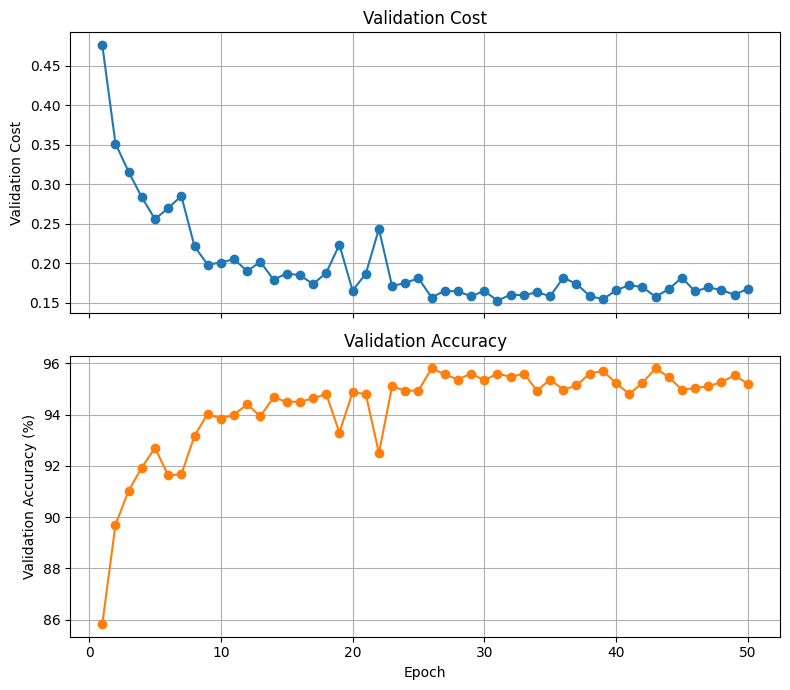

In [ ]:
#plot cost and accuracy of each epoch at the end of training process
epochs = range(1, len(val_cost_list) + 1) #generate x-axis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Cost graph
ax1.plot(epochs, val_cost_list, marker="o", color="tab:blue")
ax1.set_ylabel("Validation Cost")
ax1.set_title("Validation Cost")
ax1.grid(True)

# Accuracy graph
ax2.plot(epochs, val_accuracy_list, marker="o", color="tab:orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy (%)")
ax2.set_title("Validation Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

---

# 11. Model Checkpointing and Early Stopping
From the above graph, you can clearly see that as the validation cost decreases, the accuracy of our neural network steadily increases.

However, if we look closely at the visualization, we can observe two major issues:
* **Wasted Computation:** After approximately 20+ epochs, both the cost and accuracy curves almost flatten out, excluding a few minor random spikes. This means that at this point, the NN has already learned whatever it can and has stopped learning. Despite this, the training loop stubbornly continues to run for the remaining epochs, wasting valuable time and computing resources. This problem is solved by Early Stopping.
* **OverWriting the Best Parameters:** There is almost always a specific peak epoch where the validation cost hits its absolute lowest point (and accuracy hits its maximum) compared to the epochs that follow it. However, because the loop runs blindly to the very end, the final network is left holding whatever parameter values were calculated during the last epoch — effectively overwriting the best parameter settings that were discovered along the way. This is highly undesirable and is solved by Model Checkpointing.

## 11.1 Implementing Model Checkpointing
Implementing model checkpointing is really easy.

To implement this, we need to track what the best parameters are by monitoring a metric like validation cost or validation accuracy. In practice, we almost always monitor validation cost. This is because once a model's architecture becomes complex, the dataset grows, or the number of epochs increases, accuracy can become quite noisy and stagnant. It often hits a flat ceiling and remains completely constant while the validation loss is still steadily but subtly decreasing—meaning that the network is still refining its confidence and learning, even if the raw accuracy percentage doesn't show it.

To track the validation cost in code, we will initialize a variable named `best_check_val_cost` with a very high starting value (infinity). At the end of each epoch, we will compare the current validation cost against the best_check_val_cost.

If the current cost is lower, it means the network just achieved a new historical high score. We then update the tracker with `best_check_val_cost = current_val_cost` and save a permanent backup of all the parameters. By doing this, once the last epoch concludes, we can safely use those saved arrays, guaranteeing we hold the absolute best version of the parameters instead of being stuck with whatever was left over from the last epoch.

## 11.2 Implementing Early Stopping
To implement early stopping, we will monitor the validation cost once again. However, this time we will perform plateau detection, meaning we want to detect when the validation cost flattens out and remains approximately stagnant.

Just like we did with model checkpointing, we will initialize a tracking variable named `best_stop_val_cost` to a very high value (infinity). We will also introduce a new hyperparameter called minimum delta ($\Delta_{min}$), which is the minimum amount of improvement we require to consider that the network is still actively learning.

We need this minimum delta because the validation cost naturally fluctuates and is almost never a perfectly smooth, downward line. Once the network stops learning meaningful patterns, its loss begins to oscillate up and down within a tight, stagnant range. The minimum delta acts as a threshold that defines this baseline range.

For example, let's say the current best_stop_val_cost is 0.1546 and the minimum delta is set to 0.004. To prove it is still learning, the network must achieve a validation cost lower than $0.1546 - 0.004 = \mathbf{0.1506}$. If the network turns in a validation cost of 0.1521, it failed to clear the strict improvement threshold. This failure triggers the stagnation alert.

Also, to prevent false alarms, we cannot judge the network over just two epochs. We must check if the validation cost remains stagnant over a continuous window of $x$ epochs. Only if the validation cost fails to make a meaningful improvement for multiple epochs in a row can we confidently state that the NN has truly plateaued and stopped learning. To implement this window, we use another hyperparameter named patience.

The logic operates step-by-step at the end of each epoch:
* **Stagnation (Increment Patience):** Every time the current validation cost is **greater** than best_stop_val_cost - minimum delta (meaning there is no meaningful improvement), the network is stalling. We increment the patience_counter by 1. If the patience_counter reaches the maximum patience limit, we break out of the training loop entirely and thus stop training the NN.
* **Improvement (Reset Patience):** Every time the current validation cost is **lesser** than best_stop_val_cost - minimum delta (meaning the model successfully achieved a significant drop in error), we reset the patience_counter back to 0 and update best_stop_val_cost to match this new, lower validation cost.

## 11.3 Decoupled Model Checkpointing and Early Stopping
Notice how model checkpointing and early stopping are beautifully decoupled from each other?

This is because checkpointing is greedy: we want to save the network's parameters even if they result in a microscopic, tiny improvement to validation cost. But for plateau detection, this is not true; we want to actively ignore those tiny fluctuations so we can accurately spot when the learning curves have flattened out. This is the exact reason why both systems maintain their own separate tracking variables for validation cost.

Now, let's integrate both model checkpointing and early stopping directly into our training pipeline. Also this time let's separate all the dataset downloading and pre-processing part into a separate code cell so that we need not execute it again and again:



In [ ]:
import torch #using pytorch only to download the dataset :)
import torchvision
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

#Download the training dataset (60,000 imgs)
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
)

#Download the testing dataset (10,000 imgs)
test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
)

def load_dataset(path, isLabel=False):
     with open(path, 'rb') as f:
         data = np.frombuffer(f.read(), dtype=np.uint8, offset=16 if not isLabel else 8) #we still need numpy to read the dataset
         return data

def relu (x): #relu activation function with GPU support
  return cp.maximum(0, x)

def diff_relu(x): #differentiaiton of ReLU with GPU support
  return cp.where(x > 0, 1.0, 0.0)

def batch_softmax(x): #CuPy version of batch_softmax
 return cp.exp(x - cp.max(x, axis=1, keepdims=True)) / cp.sum(cp.exp(x - cp.max(x, axis=1, keepdims=True)), axis=1, keepdims=True)

def batch_cross_entropy(y, y_hat): #batch_cross_entropy
  total_loss = -cp.sum(y * cp.log(y_hat + 1e-15), axis=1, keepdims=True)
  return cp.mean(total_loss)


#load training dataset
X_train = load_dataset("./data/MNIST/raw/train-images-idx3-ubyte")
Y_train = load_dataset("./data/MNIST/raw/train-labels-idx1-ubyte", True)

#load testing dataset
X_test = load_dataset("./data/MNIST/raw/t10k-images-idx3-ubyte")
Y_test = load_dataset("./data/MNIST/raw/t10k-labels-idx1-ubyte", True)

#copy the training and testing dataset to GPU us CuPy so that all of the next operations over the dataset are GPU supported
X_train, Y_train = cp.asarray(X_train), cp.asarray(Y_train)
X_test, Y_test = cp.asarray(X_test), cp.asarray(Y_test)

#Data preprocessing - GPU supported
X_train = X_train.reshape(60000, 784) #directly reshape to (60000, 784)
X_test = X_test.reshape(10000, 784) #directly reshape to (10000, 784)

X_train = X_train.astype(cp.float32) / 255.0
X_test = X_test.astype(cp.float32) / 255.0

eye = cp.identity(10)
Y_train = eye[Y_train]
Y_test = eye[Y_test]

#Generate weight matrices
limit = 1 / cp.sqrt(784)
w1 = cp.random.uniform(low=-limit, high=limit, size=(784, 16)) #generates random but uniformly distributed values within the given boundary - using CuPy

limit = 1 / cp.sqrt(16)
w2 = cp.random.uniform(low=-limit, high=limit, size=(16, 16))
w3 = cp.random.uniform(low=-limit, high=limit, size=(16, 10))

#Generate bias vectors
b1 = cp.zeros((1, 16))
b2 = cp.zeros((1, 16))
b3 = cp.zeros((1, 10))

In [ ]:
#Training and Validation splits
split = 0.95
shuffle = cp.random.permutation(len(X_train)) #generates indices from 0 to 59999 in a random order - using CuPy
X_train, Y_train = X_train[shuffle], Y_train[shuffle]

train_split = int(len(X_train) * split)
X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]
X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]

lr = 0.02 #learning rate
epochs = 50
batch_size = 32

#intialize variables for model checkpointing
best_check_val_cost = cp.inf #initialized to infinity
#intialze variables to hold the best weights and biases
bestw1, bestw2, bestw3 = None, None, None
bestb1, bestb2, bestb3 = None, None, None

#intialize variables for early stopping
best_stop_val_cost = cp.inf
min_delta = 1e-3
patience = 5
patience_counter = 0
batches = (len(X_train_split) + batch_size - 1) // batch_size #calculated no of batches just for information purpose - not actually needed in the code
val_cost_list = []
val_accuracy_list = []

for i in range(epochs):
  print(f"\n#----------Epoch: {i+1}/{epochs}----------#")
  shuffle = cp.random.permutation(len(X_train_split))
  X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle] #shuffle before starting the epoch
  batch_counter = 0 #keep track of batch
  for j in range(0, len(X_train_split), batch_size): #loop from 0(inclusive) to end index of X_train_split (exclusive) with step size = batch_size
    batch_counter += 1
    end = j + batch_size #end index = start index + batch_size
    print(f"\rBatch: {batch_counter}/{batches} | start={j} | end={min(end, len(X_train_split))}", end="", flush=True)
    X_train_batch = X_train_split[j:end]
    Y_train_batch = Y_train_split[j:end] #we also need to slice the labels according the batch

    #forward pass - GPU supported
    z1 = cp.dot(X_train_batch, w1) + b1
    a1 = relu(z1) #shape(no. of images in batch, no of neurons in L=1(16))

    z2 = cp.dot(a1, w2) + b2
    a2 = relu(z2) #shape(no. of images in batch, no of neurons in L=2(16))

    z3 = cp.dot(a2, w3) + b3
    a3 = batch_softmax(z3) #shape(no. of images in batch, no of neurons in L=3(10))

    cost = batch_cross_entropy(Y_train_batch, a3)

    #backward pass - GPU supported
    delta3 = a3 - Y_train_batch
    delta2 = cp.dot(delta3, w3.T) * diff_relu(z2)
    delta1 = cp.dot(delta2, w2.T) * diff_relu(z1)

    dw3 = cp.dot(a2.T, delta3) / X_train_batch.shape[0] #divide the resultant matrix (elementwise) by no. of images in batch to calculate average gradients
    dw2 = cp.dot(a1.T, delta2) / X_train_batch.shape[0]
    dw1 = cp.dot(X_train_batch.T, delta1) / X_train_batch.shape[0]

    db1 = cp.mean(delta1, axis=0, keepdims=True)
    db2 = cp.mean(delta2, axis=0, keepdims=True)
    db3 = cp.mean(delta3, axis=0, keepdims=True)

    #update the parameters with average gradients over all the images present in the batch
    w1 -= lr * dw1
    w2 -= lr * dw2
    w3 -= lr * dw3

    b1 -= lr * db1
    b2 -= lr * db2
    b3 -= lr * db3

  #Evaluate NN's learning for this epoch against the validation split

  z1 = cp.dot(X_val_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)

  #Calculate the validation cost and it to the val_cost_list
  val_cost = batch_cross_entropy(Y_val_split, a3)
  val_cost_list.append(float(val_cost)) #move data from GPU to CPU and then add it to the list

  #Calculate the validation accuracy and it to the val_accuracy_list
  predictions = cp.argmax(a3, axis=1) #returns index of maximum a^3 activations along each row
                                      #returns the digit that NN thinks is present in each image of the validaiton split
  actual = cp.argmax(Y_val_split, axis=1) #returns index of maximum value along each row of one hot encoded labels of validation splits
                                          #i.e. returns the correct digit corresponding to each image in the validation split
  equals = cp.equal(predictions, actual) #does row-wise comparison and returns True/1 if the rows are equal and False/0 for the provided matrices
  accuracy = cp.mean(equals) * 100 #simply add all the vaues of equals matrix and divide it by the number of rows present in it which is nothing but mean
                                   #and then multiply by 100 to find out the percentage of images the NN correctly classified. This is the accuracy of NN
  val_accuracy_list.append(float(accuracy)) #move data from GPU to CPU and then add it to the list

  #model checkpointing logic
  if val_cost < best_check_val_cost:
    best_check_val_cost = val_cost
    bestw1, bestw2, bestw3 = cp.copy(w1), cp.copy(w2), cp.copy(w3) #we need to copy the weight matrices. we can't bestw1 = w1 because this creates a memory reference of w1
                                                                   #and stores it to bestw1. As a result when w1 changes bestw1 points to the latest changed w1 matrix.
    bestb1, bestb2, bestb3 = cp.copy(b1), cp.copy(b2), cp.copy(b3)
    print("\nCheckpoint created!")

  #early stopping logic
  if val_cost < best_stop_val_cost - min_delta:
    #change in val_cost detected
    best_stop_val_cost = val_cost
    patience_counter = 0
  else:
    #no change detected
    patience_counter += 1
    if patience_counter >= patience:
      break #stop training if val_cost is stagnant for no. of epochs = patience


#----------Epoch: 1/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 2/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 3/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 4/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 5/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 6/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 7/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 8/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 9/50----------#
Batch: 1782/1782 | start=56992 | end=57000
#----------Epoch: 10/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 11/50----------#
Batch: 1782/1782 | start=

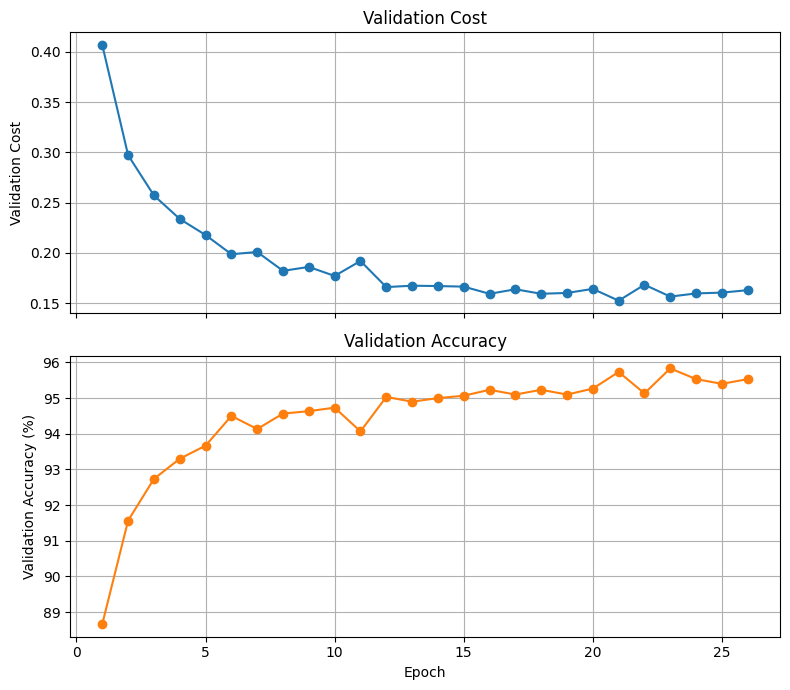

In [ ]:
#plot cost and accuracy of each epoch at the end of training process
epochs = range(1, len(val_cost_list) + 1) #generate x-axis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Cost graph
ax1.plot(epochs, val_cost_list, marker="o", color="tab:blue")
ax1.set_ylabel("Validation Cost")
ax1.set_title("Validation Cost")
ax1.grid(True)

# Accuracy graph
ax2.plot(epochs, val_accuracy_list, marker="o", color="tab:orange")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation Accuracy (%)")
ax2.set_title("Validation Accuracy")
ax2.grid(True)

plt.tight_layout()
plt.show()

This time we will also truly test the NN by evaluating it against the test dataset. As explained before since this dataset is never seen by the NN before, hence its perfect to truly test the NN.

Note:- Do not expect the cost and accuracy of testing dataset to be exactly the same or always aproximately equal to that of best validation cost and accuracy. This is because validation and testing datasets are both different datasets and also often the testing dataset has harder data points as compared to the datapoints present in the validation dataset.

In [ ]:
#use best parameters discovered during training process to test the model
z1 = cp.dot(X_test, bestw1) + bestb1
a1 = relu(z1) #shape(no. of images in test dataset, no of neurons in L=1(16))

z2 = cp.dot(a1, bestw2) + bestb2
a2 = relu(z2) #shape(no. of images in test dataset, no of neurons in L=2(16))

z3 = cp.dot(a2, bestw3) + bestb3
a3 = batch_softmax(z3) #shape(no. of images in test dataset, no of neurons in L=3(10))

cost = batch_cross_entropy(Y_test, a3)
print("Cost: ", cost)

predictions = cp.argmax(a3, axis=1)
actual = cp.argmax(Y_test, axis=1)
equals = cp.equal(predictions, actual)
accuracy = cp.mean(equals) * 100
print("Accuracy: ", accuracy)

Cost:  0.15546195387131137
Accuracy:  95.69


# 12. Learning Rate Reduction
It's a common practice in modern training pipelines to start initially with a higher learning rate (lr) and then, as epochs progress and the neural network's improvement flattens out, systematically reduce it.

This strategy allows the network to learn incredibly quickly over the early epochs. Then, as its progress stalls, reducing the learning rate helps the network carefully fine-tune its parameters to grasp the remaining underlying data structures.

Returning to our foggy mountain analogy, it's like taking massive, aggressive leaps downward early on when you know you are high up on the mountain. This helps you get down the steep slopes rapidly. However, as you approach the basin at the bottom of the mountain, you must switch to tiny, careful steps. If you keep taking massive leaps at the bottom, you will completely overshoot the lowest valley and find yourself endlessly wandering back and forth across the walls of the basin. Taking smaller steps as you near the floor allows the algorithm to settle into the absolute lowest minimum point possible, which big steps would have jumped right over.

To implement this, we need to establish two new hyperparameters that act as constraints to prevent the code from infinitely shrinking the learning rate:
* `min_lr`: The absolute minimum learning rate allowed. If our decay logic attempts to reduce the learning rate beyond the minimum learning rate allowed, we will gracefully stop the training process. A learning rate smaller than min_lr means the parameter updates are so microscopically small that further calculation becomes computationally useless.
* `lr_maxcon_reductions`: The maximum allowed number of consecutive learning rate reductions. If the network triggers a learning rate reduction multiple times in a row without finding any new performance high-scores, it means the network has officially learned everything it possibly can, or has already settled into the absolute bottom of its minimum point. Shrinking the step size any further is a waste of time, so we stop the training process.

The remaining variables we need to track this mechanic are:
* `lr_reduction_factor`: A hyperparameter multiplier (like 0.5 or 0.1) specifying the fraction by which the current learning rate should be reduced.
* `lr_reduction_counter`: A counter variable to keep track of the number of consecutive learning rate reductions that have occurred.

Because we only want to shrink the learning rate when the network hits a true learning plateau, we can seamlessly integrate this decay logic directly into the existing Early Stopping block. The integrated logic branches out at the end of each epoch like this:
* **Meaningful Improvement:** When a significant change in validation cost — meaning the current validation cost is lesser than best_stop_val_cost - min_delta — the NN is still learning nicely. In this case, we reset the lr_reduction_counter back to 0.
* **Stagnation / Plateau Detected:** When there is no meaningful change — meaning the current validation cost is greater than or equal to best_stop_val_cost - min_delta — we increment the patience_counter by 1. If the patience_counter exceeds the maximum allowed patience, a plateau has been detected. Now, instead of instantly killing the training loop via Early Stopping, we attempt to save the run by reducing the learning rate. First, we check if the lr_reduction_counter is still within the safe limit (< lr_maxcon_reductions). If it is safe, we reduce the current learning rate by  lr_reduction_factor and reset the patience_counter back to 0 to give the network a fresh window (or a chance) to test this new, smaller step size. Finally, we run a safety check: if this newly reduced learning rate has dipped below the min_lr, we break out of the training loop entirely and stop the training process. Also before doing the learning rate reduction while checking if the number of consecutive reductions are lesser than maximum allowed consecutive reductions (`lr_maxcon_reductions`). if this condition returns false even then we break out of the training loop and stop the training process.

By combining learning rate decay with early stopping and checkpointing, we create a highly defensive, incredibly smart training loop that maximizes the model's accuracy while perfectly conserving the compute resources.

Also this time we will track the training cost and training accuracy which is similar to calculating the validation cost and validation accuracy except the cost and accuracy at the end of each epoch is calculated against the entire training dataset (forward pass on the entire training dataset). We will also plot the training cost and accuracy along with the validation cost and accuracy.

Now, let's implement this in code:



#----------Epoch: 1/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 2/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

Reduced LR: 0.025

#----------Epoch: 3/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Reduced LR: 0.0125

#----------Epoch: 4/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 5/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Reduced LR: 0.00625

#----------Epoch: 6/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 7/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Reduced LR: 0.003125

#----------Epoch: 8/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Reduced LR: 0.0015625

#----------Epoch: 9/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Checkpoint created!

#----------Epoch: 10/50----------#
Batch: 1782/1782 | start=56992 | end=57000
Reduced LR: 0.0007

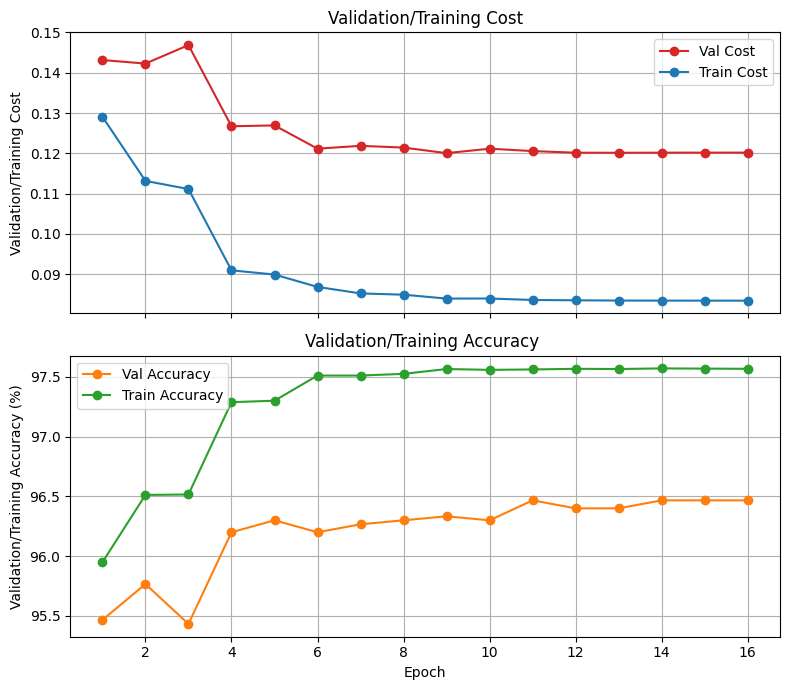

Cost:  0.14457929069241285
Accuracy:  95.98


In [ ]:
#Training and Validation splits
split = 0.95
shuffle = cp.random.permutation(len(X_train))
X_train, Y_train = X_train[shuffle], Y_train[shuffle]

train_split = int(len(X_train) * split)
X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]
X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]

epochs = 50
batch_size = 32

#intialize variables for model checkpointing
best_check_val_cost = cp.inf
bestw1, bestw2, bestw3 = None, None, None
bestb1, bestb2, bestb3 = None, None, None

#intialize variables for early stopping
best_stop_val_cost = cp.inf
min_delta = 1e-3
patience = 5
patience_counter = 0
batches = (len(X_train_split) + batch_size - 1) // batch_size #calculated no of batches just for information purpose - not actually needed in the code

val_cost_list = []
val_accuracy_list = []
train_cost_list = [] #list to track the trainng cost at the end of each epoch
train_accuracy_list = [] #list to track the trainng accuracy at the end of each epoch

#initialize variables for lr reduction
lr = 0.05 #intial learning rate, higher than earlier intial lrs
min_lr = 1e-6 #minimum allowed lr
lr_reduction_factor = 0.5
lr_maxcon_reductions = 6 #max consecutive lr reductions allowed
lr_reduction_counter = 0

for i in range(epochs):
  print(f"\n#----------Epoch: {i+1}/{epochs}----------#")
  shuffle = cp.random.permutation(len(X_train_split))
  X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle]
  batch_counter = 0
  for j in range(0, len(X_train_split), batch_size):
    batch_counter += 1
    end = j + batch_size
    print(f"\rBatch: {batch_counter}/{batches} | start={j} | end={min(end, len(X_train_split))}", end="", flush=True)
    X_train_batch = X_train_split[j:end]
    Y_train_batch = Y_train_split[j:end]

    #forward pass - GPU supported
    z1 = cp.dot(X_train_batch, w1) + b1
    a1 = relu(z1) #shape(no. of images in batch, no of neurons in L=1(16))

    z2 = cp.dot(a1, w2) + b2
    a2 = relu(z2) #shape(no. of images in batch, no of neurons in L=2(16))

    z3 = cp.dot(a2, w3) + b3
    a3 = batch_softmax(z3) #shape(no. of images in batch, no of neurons in L=3(10))

    cost = batch_cross_entropy(Y_train_batch, a3)

    #backward pass - GPU supported
    delta3 = a3 - Y_train_batch
    delta2 = cp.dot(delta3, w3.T) * diff_relu(z2)
    delta1 = cp.dot(delta2, w2.T) * diff_relu(z1)

    dw3 = cp.dot(a2.T, delta3) / X_train_batch.shape[0]
    dw2 = cp.dot(a1.T, delta2) / X_train_batch.shape[0]
    dw1 = cp.dot(X_train_batch.T, delta1) / X_train_batch.shape[0]

    db1 = cp.mean(delta1, axis=0, keepdims=True)
    db2 = cp.mean(delta2, axis=0, keepdims=True)
    db3 = cp.mean(delta3, axis=0, keepdims=True)

    #update the parameters with average gradients over all the images present in the batch
    w1 -= lr * dw1
    w2 -= lr * dw2
    w3 -= lr * dw3

    b1 -= lr * db1
    b2 -= lr * db2
    b3 -= lr * db3

  #Evaluate NN's learning for this epoch against the training dataset
  z1 = cp.dot(X_train_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)
  #Calculate the training cost and it to the train_cost_list
  train_cost = batch_cross_entropy(Y_train_split, a3)
  train_cost_list.append(float(train_cost))
  #Calculate the training accuracy and it to the train_accuracy_list
  predictions = cp.argmax(a3, axis=1)
  actual = cp.argmax(Y_train_split, axis=1)
  equals = cp.equal(predictions, actual)
  accuracy = cp.mean(equals) * 100
  train_accuracy_list.append(float(accuracy))

  #Evaluate NN's learning for this epoch against the validation split
  z1 = cp.dot(X_val_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)
  #Calculate the validation cost and it to the val_cost_list
  val_cost = batch_cross_entropy(Y_val_split, a3)
  val_cost_list.append(float(val_cost)) #move data from GPU to CPU and then add it to the list
  #Calculate the validation accuracy and it to the val_accuracy_list
  predictions = cp.argmax(a3, axis=1)
  actual = cp.argmax(Y_val_split, axis=1)
  equals = cp.equal(predictions, actual)
  accuracy = cp.mean(equals) * 100
  val_accuracy_list.append(float(accuracy)) #move data from GPU to CPU and then add it to the list

  #model checkpointing logic
  if val_cost < best_check_val_cost:
    best_check_val_cost = val_cost
    bestw1, bestw2, bestw3 = cp.copy(w1), cp.copy(w2), cp.copy(w3) #we need to copy the weight matrices. we can't bestw1 = w1 because this creates a memory reference of w1
                                                                   #and stores it to bestw1. As a result when w1 changes bestw1 points to the latest changed w1 matrix.
    bestb1, bestb2, bestb3 = cp.copy(b1), cp.copy(b2), cp.copy(b3)
    print("\nCheckpoint created!")

  #lr reduciton and early stopping logic
  if val_cost < best_stop_val_cost - min_delta:
    #change in val_cost detected
    best_stop_val_cost = val_cost
    patience_counter = 0
    lr_reduction_counter = 0
  else:
    #no change detected
    if lr_reduction_counter < lr_maxcon_reductions:
      lr -= lr * lr_reduction_factor
      print("\nReduced LR:", lr)
      if lr < min_lr:
        break #stop training if reduced lr is lesser than minimum allowed lr
      lr_reduction_counter += 1
      patience_counter = 0
    else:
      break #stop training if number of consecutive lr reductions are equal to or greater than the maximum allowed

#plot cost and accuracy of each epoch at the end of training process
epochs = range(1, len(val_cost_list) + 1) #generate x-axis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Cost graph
ax1.plot(epochs, val_cost_list, marker="o", color="tab:red", label="Val Cost")
ax1.plot(epochs, train_cost_list, marker="o", color="tab:blue", label="Train Cost")
ax1.set_ylabel("Validation/Training Cost")
ax1.set_title("Validation/Training Cost")
ax1.legend()
ax1.grid(True)

# Accuracy graph
ax2.plot(epochs, val_accuracy_list, marker="o", color="tab:orange", label="Val Accuracy")
ax2.plot(epochs, train_accuracy_list, marker="o", color="tab:green", label="Train Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation/Training Accuracy (%)")
ax2.set_title("Validation/Training Accuracy ")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#Test the NN with testing dataset using the best parameters
z1 = cp.dot(X_test, bestw1) + bestb1
a1 = relu(z1) #shape(no. of images in test dataset, no of neurons in L=1(16))

z2 = cp.dot(a1, bestw2) + bestb2
a2 = relu(z2) #shape(no. of images in test dataset, no of neurons in L=2(16))

z3 = cp.dot(a2, bestw3) + bestb3
a3 = batch_softmax(z3) #shape(no. of images in test dataset, no of neurons in L=3(10))

cost = batch_cross_entropy(Y_test, a3)
print("Cost: ", cost)

predictions = cp.argmax(a3, axis=1)
actual = cp.argmax(Y_test, axis=1)
equals = cp.equal(predictions, actual)
accuracy = cp.mean(equals) * 100
print("Accuracy: ", accuracy)

# 13. Analyzing Graph - Understanding Training Curves
Take a close look at the graph just plotted above. It actually reveals a wealth of hidden information about the neural network's internal learning journey.

Note: Because our weights are initialized randomly and our data is shuffled, the exact curves on your graph might change slightly each time you re-execute the training cell, but the underlying patterns will look nearly identical.

To read this graph like a professional machine learning engineer, you need to understand the three distinct phases a network passes through during training:

1. **Underfitting (The Early Phase):** During the initial few epochs (typically epochs 1 to 5 in the above graph), both the training and validation costs are incredibly high, and the accuracy curves are sitting very low. At this point, the neural network simply hasn't had enough time or updates to learn the structure of the data. It is currently underperforming because its parameters are still mostly random.
2. **Generalization (The Sweet Spot Phase):** During the middle epochs, you will see both the training and validation cost curves steadily sloping downward together, while both accuracy curves climb upward in parallel. This is the ideal state known as Generalization. It proves that the network is successfully discovering the universal, underlying shapes and patterns of the data (digits in our case) that apply equally to both the data it is learning from and the validation data.
3. **Overfitting (The Late Phase):** If you look toward the far right side of the graph at the final epochs, you will notice a separation forming between the curves. The training lines will continue to improve, but the validation cost curve will stall out or begin to bend upward. This creates a prominent, widening gap between the training performance and the validation performance. This state is called Overfitting — the point where the network stops learning generalized rules and instead begins blindly memorizing the specific pixels and noise of the training images. As we have implemented Early Stopping, overfitting might not be prominently visible in the above graph.

To instantly recognize these behaviors on any machine learning plot, remember these simple structural hints:


| Phase | Training Cost Line | Training Accuracy Line | Validation Cost Line | Validation Accuracy Line | The Visual Cue |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Underfitting** | Stays High | Stays Low | Stays High | Stays Low | All lines remain almost flat |
| **Generalization** | Slopes Down | Climbs Up | Slopes Down | Climbs Up | The cost lines fall together, and the accuracy lines rise together in parallel harmony. |
| **Overfitting** | Drops to near 0 | Hits near 100% | Stalls or bends **UP** | Stalls or bends **DOWN** | The lines split apart. Training lines get perfect, but validation lines get worse, creating a massive gap. |


The ultimate goal when training a neural network is to capture the parameters exactly at the peak of the Generalization phase, right before the destructive split of the Overfitting phase takes over. This is the exact reason why we implemented our Model Checkpointing and Early Stopping safeguards in the previous sections.

## 13.1 Diagnosing Underfitting and Overfitting
In a healthy training pipeline, the graph should naturally transition from left to right through these three phases. However, sometimes the plot won't show this progression at all. If the network gets permanently locked into only underfitting or only overfitting across the entire timeline, it indicates that something is fundamentally broken with the network's capacity:
* **Permanent Underfitting (The Flatlining Network):** Imagine looking at the graph and seeing all four lines completely flatlining horizontally from epoch 1 to the ending epoch. The training and validation cost lines are trapped high up on the graph, while the training and validation accuracy lines are stuck down at the bottom.This indicates that all four lines are performing terribly together. The network is fundamentally too weak to learn. Its hidden layers are either too narrow (not enough neurons) or too shallow (not enough layers) to capture the complex mathematical curves of handwritten digits. It can also mean the learning rate (α) is set catastrophically low, causing the network to take tiny, invisible baby steps that never make it down the mountain.

* **Instant Overfitting (The Broken Split):** Imagine looking at the graph and seeing a massive, immediate seperation between the training lines and the validation lines right from epoch 1. The training cost line plunges straight to zero, and the training accuracy line rockets to a perfect 100%. However, on the exact same graph, the validation cost line stays high or shoots upward, while the validation accuracy line stays completely flat and low. This indicates that the training lines look perfect, but the validation lines look terrible. This happens when the network has a massive over-abundance of brainpower (too many neurons/layers) but is being fed a training dataset that is far too small. Instead of extracting general, global rules, the network instantly uses its millions of free parameters to hardcode a perfect digital photocopy of the few training images into its memory. It becomes a brainless memorizer that aces the practice homework but fails the unseen exam instantly.


# 14. L2 Regularization (Weight Decay)

Now that we know that the problem called "Overfitting" exists and what exactly it is. We can look for its solution.

To find the solution to this problem we must know what actually happens to the parameters when the NN starts overfitting or when it switches from learning patterns to memorizing pixels.

## 14.1 Extreme Parameters - The Root of Overfitting
When a neural network has thousands of free parameters and is left completely unchecked, it will always choose the path of least mathematical resistance. If it discovers a tiny, accidental quirk in the training images — like a random scratch on a background pixel of a specific digit 5 (just an example) — it will aggressively crank the weights connected to that scratch to massive, extreme positive or negative numbers (like changing a weight from 0.1 to 850.0).

These giant weights act like hyper-sensitive amplifiers. If a clean validation image lacks that exact scratch, the giant weight multiplies that tiny pixel difference into a massive, erratic signal that completely throws off the final Softmax prediction. This is why the training lines look flawless while the validation lines bend destructively upward during overfitting.

To prevent this memorization, we need a mathematical tool that acts like an anchor, forcing the network to keep its weight parameters small, balanced, and stable. This technique is called Regularization, and the absolute gold standard in deep learning is L2 Regularization (also known as Weight Decay).

## 14.2 Understanding L2 Regularization Mathematically
L2 Regularization solves overfitting by playing a small, yet smart trick on the Gradient Descent algorithm: it modifies Loss Function — to punish the network for having large weights.

Originally, the loss function cared about only one thing: How far off is the network's prediction from the true label?

With L2 Regularization, we alter our equation by tacking on a brand-new penalty term right at the end. The formula for our regularized batch loss looks like this:$$\text{Loss}_{\text{total}}=\text{Loss}_{\text{original}}+\frac{\lambda }{2n}\sum (w)^{2}$$

Let's break down exactly what this penalty term means:
* $\sum (w)^2$: This is the "L2" part. We take every single weight parameter present across all layers of our network, square it (which eliminates negative signs and penalizes larger values exponentially), and sum them all together.
* $n$: The number of data points (images) in our batch, used to scale the penalty fairly.
* $\lambda$ (Lambda): This is a new optimization hyperparameter called the Regularization Strength. It acts like a dial that controls how harshly we want to punish the network for having large weights. If this is set to $\lambda = 0$, regularization turns off completely.

## 14.3 Diving deeper into Math of L2 Regularization
To understand exactly how **L2 Regularization** prevents overfitting, we must look beyond the formula itself and understand how it fundamentally changes the optimization process during Gradient Descent.

When a neural network is trained using only the original classification loss, Gradient Descent has one objective: **reduce the training loss as much as possible.** It does not care **how** that reduction is achieved. If exploiting a random coincidence in the training data helps reduce the loss, Gradient Descent will happily do so.

Imagine that a small handful of training images representing the digit **5** happen to share an accidental quirk — for example, a tiny stray ink blob appearing at a particular location in the image. This blob is completely unrelated to what actually makes a handwritten **5** a **5**, yet it consistently appears in a few training samples.

To minimize the training loss, the network may begin increasing the magnitude of one or more weights that respond strongly to this accidental feature. Ads a result, these weights gradually become highly specialized at detecting the stray ink blob rather than the true visual structure of the digit.

The problem becomes obvious when the network encounters a completely new image. A handwritten **3**, **6**, or **8** might accidentally contain a similar ink artifact even though it is not a **5**. Because the learned weight associated with that spurious feature has become excessively influential, it can dominate the network's decision, causing the image to be classified incorrectly. The network has effectively memorized a coincidence instead of learning a genuine visual pattern.

To discourage this behaviour, we modify the loss function by introducing the **L2 penalty term**:

$$
\boxed{\text{Loss}_{\text{total}} = \text{Loss}_{\text{classification}} + \frac{\lambda}{2n}\sum_i w_i^2}
$$

The first term, $\text{Loss}_{\text{classification}}$ which is nothing but the pure Loss, still measures how accurately the network classifies the training data. The second term assigns an additional cost to large weight values. Since every weight is squared, larger weights contribute **disproportionately more** to the total loss than smaller ones. This makes excessively large weights increasingly expensive to maintain.

However, the real magic of L2 Regularization is revealed during Backpropagation.

When we differentiate the new loss function, the gradient of the penalty term is added to the original weight gradient:

$$
\boxed{
\frac{\partial \text{Loss}_{\text{total}}}{\partial w^L}
=\frac{\partial \text{Loss}_{\text{classification}}}{\partial w^L}
+
\frac{\lambda}{n}w^L
}
$$

From this point onward, every weight update becomes a continuous mathematical **Tug-of-War** between two competing forces.

The **classification-loss gradient** tries to move each weight in whichever direction reduces the prediction errors, while the **L2 penalty gradient** constantly pulls every weight back toward zero.

Importantly, the L2 penalty does **not** know which weights are useful and which are useless. It applies exactly the same mathematical rule to **every** weight in the network. The final update direction is determined entirely by whichever gradient dominates for that particular weight.

Now consider how this tug-of-war unfolds for two different kinds of weights.

### 14.3.1 The Spurious Weight Loses the Tug-of-War

Suppose a particular weight has grown unusually large because it detects the accidental ink blob rather than a genuine feature of the digit.

Since this quirk appears in only a tiny fraction of the training images, changing this weight has very little effect on the overall classification loss of the entire dataset. Consequently, the classification-loss gradient with respect to this weight is relatively weak.

The L2 penalty, however, sees only one thing: **the weight has become large.** Because the **penalty gradient is directly proportional to the weight's magnitude**,

$$
\frac{\lambda}{n}w
$$

its pull becomes increasingly stronger as the weight grows.

When both gradients are added together, the penalty gradient dominates the total gradient for this weight. During Gradient Descent, this weight is therefore pushed aggressively back towards zero. Over successive updates, the influence of this spurious feature gradually disappears because the network can no longer justify maintaining such a large parameter for a feature that contributes so little to reducing the overall classification loss.

### 14.3.2 The Important Weight Wins the Tug-of-War

Now consider a completely different weight — one responsible for detecting a genuine visual feature, such as the curved lower stroke of a handwritten **5** or the horizontal top bar of a **7**.

This feature appears consistently across thousands of training images. Even a small change to this weight noticeably increases the classification loss across a large portion of the dataset.

As a result, the classification-loss gradient associated with this weight remains consistently strong. Although the L2 penalty is still pulling this weight toward zero using exactly the same mathematical rule as before, the classification-loss gradient now dominates the total gradient because preserving this weight is essential for keeping the prediction errors low.

Consequently, Gradient Descent only nudges this weight slightly toward zero before the much stronger classification-loss gradient pulls it back toward the value required for accurate classification. The weight therefore remains active because its contribution to reducing the classification loss consistently outweighs the additional penalty imposed by L2 Regularization.

---

By the end of training, an elegant filtering process has taken place automatically.

Weights that became large merely to memorize random quirks could not justify their magnitude against the continuous pull of the L2 penalty and were gradually driven toward zero. In contrast, weights representing genuine, repeatable visual patterns consistently produced strong classification gradients that allowed them to overcome the regularization pressure and remain significant.

The remarkable aspect of L2 Regularization is that it never explicitly identifies which features are useful and which are not. Instead, it simply makes **every large weight expensive**. Gradient Descent then naturally preserves only those weights whose contribution to reducing the classification loss is valuable enough to justify paying that additional cost. As a result, the network shifts its focus away from memorizing accidental details and toward learning the robust, generalized patterns that truly define the data.

One last thing to know before we implement L2 Regularization in code is, we do not need to actually calculate the cost with added penalty term. Instead we can directly add the gradient of the penalty term to the weight gradient matrcies.
This is because during backpropagation, the calculation of gradient of any of the parameter does not require the loss/cost value. However to implement L2 Regularization we need to consider that the loss/cost has the L2 penalty term added to it and hence while calculating the gradient matrices of the weights we can simply add the gradient of this L2 penalty term.

Also we can apply this L2 reeuglarization to all the layers of NN that have weights associated to them. This means we can use L2 regularization for all the layers except the input layer.

So let's now implement L2 Regularization in our training pipeline:


#----------------Epoch: 1/50----------------#
Batch: 1782/1782 | Cost: 0.0259 | L2 Cost: 0.0273 | Window: [56992:57000]
Checkpoint created!

#----------------Epoch: 2/50----------------#
Batch: 1782/1782 | Cost: 0.0147 | L2 Cost: 0.0161 | Window: [56992:57000]
Checkpoint created!

#----------------Epoch: 3/50----------------#
Batch: 1782/1782 | Cost: 0.0637 | L2 Cost: 0.0652 | Window: [56992:57000]
Reduced LR: 0.025

#----------------Epoch: 4/50----------------#
Batch: 1782/1782 | Cost: 0.2539 | L2 Cost: 0.2554 | Window: [56992:57000]
Checkpoint created!

#----------------Epoch: 5/50----------------#
Batch: 1782/1782 | Cost: 0.4165 | L2 Cost: 0.4181 | Window: [56992:57000]
Reduced LR: 0.0125

#----------------Epoch: 6/50----------------#
Batch: 1782/1782 | Cost: 0.1301 | L2 Cost: 0.1316 | Window: [56992:57000]
Checkpoint created!

#----------------Epoch: 7/50----------------#
Batch: 1782/1782 | Cost: 0.1732 | L2 Cost: 0.1747 | Window: [56992:57000]
Reduced LR: 0.00625

#--------------

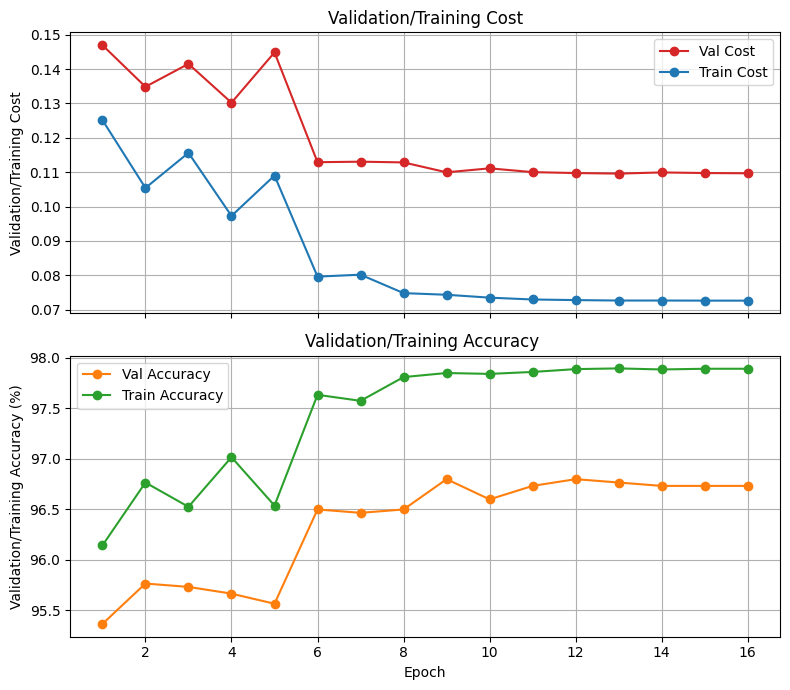

Cost:  0.14322082746997986
Accuracy:  96.2


In [ ]:
#Training and Validation splits
split = 0.95
shuffle = cp.random.permutation(len(X_train))
X_train, Y_train = X_train[shuffle], Y_train[shuffle]

train_split = int(len(X_train) * split)
X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]
X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]

epochs = 50
batch_size = 32

#intialize variables for model checkpointing
best_check_val_cost = cp.inf
bestw1, bestw2, bestw3 = None, None, None
bestb1, bestb2, bestb3 = None, None, None

#intialize variables for early stopping
best_stop_val_cost = cp.inf
min_delta = 1e-3
patience = 5
patience_counter = 0
batches = (len(X_train_split) + batch_size - 1) // batch_size #calculated no of batches just for information purpose - not actually needed in the code

val_cost_list = []
val_accuracy_list = []
train_cost_list = [] #list to track the trainng cost at the end of each epoch
train_accuracy_list = [] #list to track the trainng accuracy at the end of each epoch

#initialize variables for lr reduction
lr = 0.05 #intial learning rate, higher than earlier intial lrs
min_lr = 1e-6 #minimum allowed lr
lr_reduction_factor = 0.5
lr_maxcon_reductions = 6 #max consecutive lr reductions allowed
lr_reduction_counter = 0

regularization_strength = 1e-4 #hyperparameter for L2 regularization

for i in range(epochs):
  print(f"\n#----------------Epoch: {i+1}/{epochs}----------------#")
  shuffle = cp.random.permutation(len(X_train_split))
  X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle]
  batch_counter = 0
  for j in range(0, len(X_train_split), batch_size):
    batch_counter += 1
    end = j + batch_size
    X_train_batch = X_train_split[j:end]
    Y_train_batch = Y_train_split[j:end]

    #forward pass - GPU supported
    z1 = cp.dot(X_train_batch, w1) + b1
    a1 = relu(z1) #shape(no. of images in batch, no of neurons in L=1(16))

    z2 = cp.dot(a1, w2) + b2
    a2 = relu(z2) #shape(no. of images in batch, no of neurons in L=2(16))

    z3 = cp.dot(a2, w3) + b3
    a3 = batch_softmax(z3) #shape(no. of images in batch, no of neurons in L=3(10))

    no_of_samples = len(X_train_batch) #no of image/samples present in the batch
    cost = batch_cross_entropy(Y_train_batch, a3)
    l2_cost = cost + (regularization_strength/(2 * no_of_samples)) * (cp.sum(cp.square(w1)) + cp.sum(cp.square(w2)) + cp.sum(cp.square(w3))) #add L2 penalty term to cost
    #calculated L2 penalized cost just for printing it - we don't require it any further
    print(f"\rBatch: {batch_counter}/{batches} | Cost: {cost:.4f} | L2 Cost: {l2_cost:.4f} | Window: [{j}:{min(end, len(X_train_split))}]", end="", flush=True)

    #backward pass - GPU supported
    delta3 = a3 - Y_train_batch
    delta2 = cp.dot(delta3, w3.T) * diff_relu(z2)
    delta1 = cp.dot(delta2, w2.T) * diff_relu(z1)


    dw3 = cp.dot(a2.T, delta3) / X_train_batch.shape[0] + (regularization_strength/no_of_samples) * w3
    dw2 = cp.dot(a1.T, delta2) / X_train_batch.shape[0] +  (regularization_strength/no_of_samples) * w2
    dw1 = cp.dot(X_train_batch.T, delta1) / X_train_batch.shape[0] +  (regularization_strength/no_of_samples) * w1

    db1 = cp.mean(delta1, axis=0, keepdims=True)
    db2 = cp.mean(delta2, axis=0, keepdims=True)
    db3 = cp.mean(delta3, axis=0, keepdims=True)

    #update the parameters with average gradients over all the images present in the batch
    w1 -= lr * dw1
    w2 -= lr * dw2
    w3 -= lr * dw3

    b1 -= lr * db1
    b2 -= lr * db2
    b3 -= lr * db3

  #Evaluate NN's learning for this epoch against the training dataset
  z1 = cp.dot(X_train_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)
  #Calculate the training cost and it to the train_cost_list
  train_cost = batch_cross_entropy(Y_train_split, a3)
  train_cost_list.append(float(train_cost))
  #Calculate the training accuracy and it to the train_accuracy_list
  predictions = cp.argmax(a3, axis=1)
  actual = cp.argmax(Y_train_split, axis=1)
  equals = cp.equal(predictions, actual)
  accuracy = cp.mean(equals) * 100
  train_accuracy_list.append(float(accuracy))

  #Evaluate NN's learning for this epoch against the validation split
  z1 = cp.dot(X_val_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)
  #Calculate the validation cost and it to the val_cost_list
  val_cost = batch_cross_entropy(Y_val_split, a3)
  val_cost_list.append(float(val_cost)) #move data from GPU to CPU and then add it to the list
  #Calculate the validation accuracy and it to the val_accuracy_list
  predictions = cp.argmax(a3, axis=1)
  actual = cp.argmax(Y_val_split, axis=1)
  equals = cp.equal(predictions, actual)
  accuracy = cp.mean(equals) * 100
  val_accuracy_list.append(float(accuracy)) #move data from GPU to CPU and then add it to the list

  #model checkpointing logic
  if val_cost < best_check_val_cost:
    best_check_val_cost = val_cost
    bestw1, bestw2, bestw3 = cp.copy(w1), cp.copy(w2), cp.copy(w3) #we need to copy the weight matrices. we can't bestw1 = w1 because this creates a memory reference of w1
                                                                   #and stores it to bestw1. As a result when w1 changes bestw1 points to the latest changed w1 matrix.
    bestb1, bestb2, bestb3 = cp.copy(b1), cp.copy(b2), cp.copy(b3)
    print("\nCheckpoint created!")

  #lr reduciton and early stopping logic
  if val_cost < best_stop_val_cost - min_delta:
    #change in val_cost detected
    best_stop_val_cost = val_cost
    patience_counter = 0
    lr_reduction_counter = 0
  else:
    #no change detected
    if lr_reduction_counter < lr_maxcon_reductions:
      lr -= lr * lr_reduction_factor
      print("\nReduced LR:", lr)
      if lr < min_lr:
        break #stop training if reduced lr is lesser than minimum allowed lr
      lr_reduction_counter += 1
      patience_counter = 0
    else:
      break #stop training if number of consecutive lr reductions are equal to or greater than the maximum allowed

#plot cost and accuracy of each epoch at the end of training process
epochs = range(1, len(val_cost_list) + 1) #generate x-axis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Cost graph
ax1.plot(epochs, val_cost_list, marker="o", color="tab:red", label="Val Cost")
ax1.plot(epochs, train_cost_list, marker="o", color="tab:blue", label="Train Cost")
ax1.set_ylabel("Validation/Training Cost")
ax1.set_title("Validation/Training Cost")
ax1.legend()
ax1.grid(True)

# Accuracy graph
ax2.plot(epochs, val_accuracy_list, marker="o", color="tab:orange", label="Val Accuracy")
ax2.plot(epochs, train_accuracy_list, marker="o", color="tab:green", label="Train Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation/Training Accuracy (%)")
ax2.set_title("Validation/Training Accuracy ")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#Test the NN with testing dataset using the best parameters
z1 = cp.dot(X_test, bestw1) + bestb1
a1 = relu(z1) #shape(no. of images in test dataset, no of neurons in L=1(16))

z2 = cp.dot(a1, bestw2) + bestb2
a2 = relu(z2) #shape(no. of images in test dataset, no of neurons in L=2(16))

z3 = cp.dot(a2, bestw3) + bestb3
a3 = batch_softmax(z3) #shape(no. of images in test dataset, no of neurons in L=3(10))

cost = batch_cross_entropy(Y_test, a3)
print("Cost: ", cost)

predictions = cp.argmax(a3, axis=1)
actual = cp.argmax(Y_test, axis=1)
equals = cp.equal(predictions, actual)
accuracy = cp.mean(equals) * 100
print("Accuracy: ", accuracy)

If you observe the graph we just plotted above, you might notice something highly unexpected: it now shows even stronger overfitting toward the final epochs than our previous run. But we implemented L2 Regularization specifically to fix overfitting. Why did it make our validation curves look worse?

This happens because if you inspect the earlier training graph — before L2 Regularization was introduced to the pipeline — it was already nearly perfect. It displayed the natural, slight divergence at the final epochs and maintained an excellent, healthy generalization curve throughout the middle phase. In other words, by introducing L2 Regularization, we actually ended up trying to solve a problem that never existed in the network to begin with.

**This teaches us a golden rule in the world of machine learning engineering: It is incredibly easy to over-optimize a neural network, and blindly throwing complex fixes at a model that is already working can lead to highly catastrophic results** (although in our case the final test accuracy and test cost are not particularly bad).

However, in the context of this notebook, our goal in implementing the L2 Regularization pipeline wasn't strictly to patch this specific simple NN (which was already performing as best as it could anyway). Our true goal was to master the grassroots mechanics of how weight decay operates mathematically, so that it can be used perfectly for far more complicated real world Neural Nets.

---

# 15. Dropout Regularization

## 15.1 Need for Dropout
Although L2 Regularization successfully prevents the network from assigning excessively large values to its weights, it still allows another subtle form of overfitting to develop.

A neural network is free to repeatedly use the same collection of neurons every time it sees a training image. Over time, these neurons begin depending heavily on one another, collectively forming highly specialized pathways that work exceptionally well on the training data.

These specialized groups of neurons are often called **co-adapted neurons**.

The problem is that these neurons never learn to solve the classification problem independently. Instead, each neuron silently assumes that the others will always be present to complete the computation. Rather than learning a complete and reliable representation of the underlying pattern on its own, a neuron gradually learns only part of the feature while relying on neighbouring neurons to provide the remaining information.

As a result, even if one neuron produces an incomplete or slightly incorrect activation, the remaining neurons compensate for it, allowing the final prediction to remain correct. Because these neurons continuously cover each other's shortcomings, many of them never become independently reliable feature detectors.

This becomes particularly dangerous when one of these neurons starts responding to a spurious feature — such as an accidental background artifact that appears in only a few training images. Since the neighbouring neurons have already adapted to working alongside it, they gradually begin relying on this spurious information as well. Eventually, the entire pathway becomes dependent on the accidental artifact instead of learning the true visual structure of the digit.

This creates another form of memorization and ultimately leads to overfitting.

To prevent neurons from developing these fragile dependencies, we need a mechanism that occasionally removes some of them entirely during training. By forcing every neuron to operate without knowing which of its neighbouring neurons will be available during the next forward pass, the network can no longer rely on others to compensate for its incomplete representations. Instead, every neuron is encouraged to learn useful and robust features independently. This technique is called Dropout.

## 15.2 Understanding Dropout Mathematically
The central idea behind Dropout is surprisingly simple.

Instead of allowing every neuron in a hidden layer to participate in every forward pass, we deliberately force a randomly selected fraction of them to remain inactive. In other words, every time a batch of training images passes through the network, a slightly different neural network is created by temporarily removing some of its neurons.

The first question that naturally arises is: How do we decide which neurons should be removed?

The answer is by generating a Dropout Mask. Suppose a hidden layer produces the following activation vector:
$$a^L = \begin{bmatrix} 0.8 & 0.0 & 2.3 & 1.5 & 0.6 \end{bmatrix}$$
We now create another vector having exactly the same shape as the activation vector:
$$m^L$$
called the Dropout Mask. Every element of this mask corresponds to one neuron in the hidden layer.
Its job is extremely simple:
* A value of 1 means keep the corresponding neuron active.
* A value of 0 means temporarily remove the corresponding neuron from the network.

Each element of the mask is generated independently using a Bernoulli Distribution:
$$m^L \sim \text{Bernoulli}(p_{\text{keep}})$$
Here, $m^L$ denotes the Dropout Mask for layer L and $p_{\text{keep}}$ is a hyperparameter called the "Keep Probability", representing the probability that any individual neuron remains active during a forward pass.

The distribution thus produces two possible outcomes:
* 1 with probability $p_{\text{keep}}$
* 0 with probability $1 - p_{\text{keep}}$

For example, if $p_{\text{keep}} = 0.8$ then every neuron independently has an 80% chance of surviving and a 20% chance of being dropped. One possible mask generated during a forward pass in this case might be:
$$m^L = \begin{bmatrix} 1 & 0 & 1 & 1 & 0 \end{bmatrix}$$

Every forward pass generates a completely new random mask with the given keep probabilities and hence no neuron is permanently removed. A neuron that is inactive during one batch may become active again in the very next batch.

Once the mask has been generated, we simply perform an element-wise multiplication between the activation vector and the Dropout Mask:
$$a^L = a^L ⊙ m^L$$

Applying the previous mask gives:

$$\begin{bmatrix} 0.8 & 0.0 & 2.3 & 1.5 & 0.6 \end{bmatrix} ⊙ \begin{bmatrix} 1 & 0 & 1 & 1 & 0 \end{bmatrix} = \begin{bmatrix} 0.8 & 0 & 2.3 & 1.5 & 0​ \end{bmatrix}$$

Every neuron whose corresponding mask value becomes 0 immediately produces an activation of 0. Since this new activation is passed to the next layer, the dropped neuron contributes absolutely nothing to the remaining forward computation.


However, by randomly removing neurons, we are also reducing the total amount of information flowing through the network. In the above example we are keeping only 80% of the neurons and hence the average magnitude of the activations entering the next layer also becomes approximately 80% of what it originally was. Hence, during training, the next layer receives smaller activations because Dropout is active. During inference, however, we want to use the Neural Network at its full potential and hence Dropout is disabled, meaning every neuron suddenly becomes active again. This means that the next layer would now receive much larger activations than it experienced during training. This mismatch can cause the neural network to produce highly incorrect predictions during inference.

To compensate for the neurons that were removed, we simply divide the surviving activations by the keep probability:
$$a^L = \frac{a^L ⊙ m^L}{p_{\text{keep}}}$$

In case of our example every activation will be multiplied by $\frac{1}{0.8}=1.25$. To understand how this actually scales up the magnitude of activations flowing into the next layer consider this simple example. Suppose, without Dropout, the layer produces activations having a total magnitude of 4. With Dropout, when $p_\text{keep} = 0.5(50\%)$, this magnitude will reduce to 2. But by again multiplying it by $\frac{1}{0.5}=2$ it again gets scaled up to 4 to match the original non-Dropout magnitude.

AAs a result, the expected value of each activation after Dropout becomes equal to its original value before Dropout. In other words, although individual forward passes become random, the average signal entering the next layer remains almost unchanged.

Interestingly, this was not how Dropout was originally proposed. The original Dropout algorithm performed no scaling during training. Instead, once training finished, all activations were multiplied by the keep probability during inference. Although mathematically correct, this required performing additional scaling every time the trained model made a prediction during inference. This introduces an additional computation during inference, slightly increasing inference latency. Hence to solve this problem we use Inverted Dropout which is exactly what is explained above i.e. dividing the activations during training itself by keep probability. As a result, the network naturally learns using correctly scaled activations, allowing Dropout to be disabled entirely during inference without requiring any additional computations. This is the version implemented by virtually every modern deep learning framework today.

## 15.3 How Genuine Features Naturally Survive
At first randomly dropping neurons from a layer might seem like it would also hamper the network's ability to remember or learn genuine features that help it classify a particular digit correctly. But this is not what actually happens. In fact, it forces all the neurons to fairly and independently learn the genuine features without relying on other neurons.

Consider a neuron responsible for detecting a genuine visual feature, such as the curved lower stroke of the digit 5. Even if this neuron is randomly dropped during one training iteration, hundreds of other neurons still receive gradients from thousands of training images containing that same curved feature. Since the feature consistently appears throughout the dataset, Gradient Descent repeatedly discovers that learning this pattern is one of the most effective ways to reduce the classification loss. As training progresses, many different neurons begin learning similar representations of this important feature. Instead of relying on one another to complete incomplete representations or compensate for one another's shortcomings, these neurons gradually become reliable feature detectors in their own right. Consequently, even if one neuron is temporarily removed by Dropout, the remaining neurons can still recognize the same underlying pattern, allowing the network to make correct predictions.

Now contrast this with a neuron specializing in an accidental ink blob that appears in only a handful of training images.

Whenever this neuron is randomly dropped, the fragile pathway built around that spurious feature immediately collapses. The neighbouring neurons can no longer rely on it to compensate for their incomplete representations, causing the classification loss to increase. Since this accidental feature rarely appears across the rest of the dataset, Gradient Descent finds very little benefit in repeatedly rebuilding such an unreliable pathway. Instead, Gradient Descent gradually discovers that the limited learning capacity is far better invested in features that consistently reduce the classification loss across thousands of training examples. Over many iterations, these unstable shortcuts lose their influence, while neurons detecting genuine visual patterns continue to receive strong gradients and become increasingly robust.

By the end of training, Dropout has accomplished exactly what it was designed to do. Rather than allowing neurons to specialize in fragile groups that compensate for one another's weaknesses, it forces every neuron to become as useful and independent as possible. The network therefore learns multiple reliable representations of the true underlying patterns instead of memorizing accidental coincidences, resulting in significantly better generalization on previously unseen data.


## 15.4 Droput Regularization Implementation
Dropout Regularization can be applied to any layer except the output layer. Since the output layer directly produces the final prediction probabilities, randomly dropping some of its neurons would mean deliberately corrupting the network's predictions, making the loss function itself unreliable during training.

Although Dropout can also be applied to the input layer, it is used there much less frequently. Randomly dropping input features means intentionally hiding portions of the input data from the network. While this can sometimes improve robustness in certain applications, it may also remove important information required for accurate classification. Consequently, most neural network architectures either do not apply Dropout to the input layer at all or use a much smaller Dropout rate than they do for the hidden layers.

Now let's actually implement dropout regularization. In our case we will apply it only for the two hidden layers:


#----------------Epoch: 1/50----------------#
Batch: 1782/1782 | Cost: 0.1272 | L2 Cost: 0.1298 | Window: [56992:57000]
Checkpoint created!

#----------------Epoch: 2/50----------------#
Batch: 1782/1782 | Cost: 0.5596 | L2 Cost: 0.5628 | Window: [56992:57000]
Reduced LR: 0.025

#----------------Epoch: 3/50----------------#
Batch: 1782/1782 | Cost: 0.5867 | L2 Cost: 0.5903 | Window: [56992:57000]
Reduced LR: 0.0125

#----------------Epoch: 4/50----------------#
Batch: 1782/1782 | Cost: 0.7153 | L2 Cost: 0.7191 | Window: [56992:57000]
Reduced LR: 0.00625

#----------------Epoch: 5/50----------------#
Batch: 1782/1782 | Cost: 1.1966 | L2 Cost: 1.2005 | Window: [56992:57000]
Reduced LR: 0.003125

#----------------Epoch: 6/50----------------#
Batch: 1782/1782 | Cost: 0.6377 | L2 Cost: 0.6416 | Window: [56992:57000]
Checkpoint created!

#----------------Epoch: 7/50----------------#
Batch: 1782/1782 | Cost: 0.1555 | L2 Cost: 0.1595 | Window: [56992:57000]
Checkpoint created!

#-------------

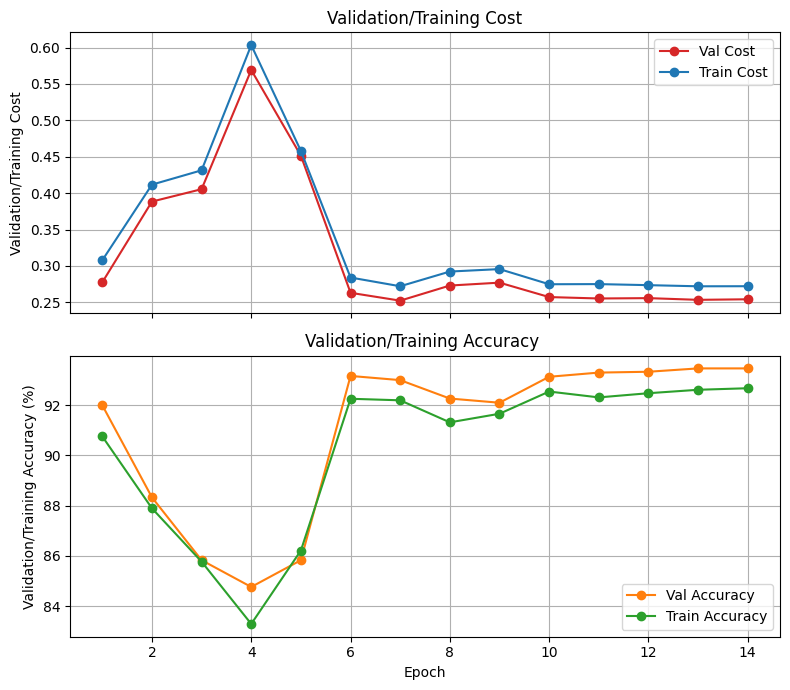

Cost:  0.27076980861392747
Accuracy:  92.19000000000001


In [ ]:
#Training and Validation splits
split = 0.95
shuffle = cp.random.permutation(len(X_train))
X_train, Y_train = X_train[shuffle], Y_train[shuffle]

train_split = int(len(X_train) * split)
X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]
X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]

epochs = 50
batch_size = 32

#intialize variables for model checkpointing
best_check_val_cost = cp.inf
bestw1, bestw2, bestw3 = None, None, None
bestb1, bestb2, bestb3 = None, None, None

#intialize variables for early stopping
best_stop_val_cost = cp.inf
min_delta = 1e-3
patience = 5
patience_counter = 0
batches = (len(X_train_split) + batch_size - 1) // batch_size #calculated no of batches just for information purpose - not actually needed in the code

val_cost_list = []
val_accuracy_list = []
train_cost_list = [] #list to track the trainng cost at the end of each epoch
train_accuracy_list = [] #list to track the trainng accuracy at the end of each epoch

#initialize variables for lr reduction
lr = 0.05 #intial learning rate, higher than earlier intial lrs
min_lr = 1e-6 #minimum allowed lr
lr_reduction_factor = 0.5
lr_maxcon_reductions = 6 #max consecutive lr reductions allowed
lr_reduction_counter = 0

regularization_strength = 1e-4 #hyperparameter for L2 regularization

pkeep = 0.9 #pkeep hyperparameter for dropout -90% neurons are active while 10% of the neurons are randomly deactivated- we will use same pkeep for both hidden layers

for i in range(epochs):
  print(f"\n#----------------Epoch: {i+1}/{epochs}----------------#")
  shuffle = cp.random.permutation(len(X_train_split))
  X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle]
  batch_counter = 0
  for j in range(0, len(X_train_split), batch_size):
    batch_counter += 1
    end = j + batch_size
    X_train_batch = X_train_split[j:end]
    Y_train_batch = Y_train_split[j:end]

    #forward pass - GPU supported
    z1 = cp.dot(X_train_batch, w1) + b1
    a1 = relu(z1) #shape(no. of images in batch, no of neurons in L=1(16))

    #dropout
    #generate mask vector for a1. We will use binomial distribution for this and pass number of trials n=1 to make it Bernoulli distribution (no direct support for Bernoulli distribution)
    a1_mask = cp.random.binomial(n=1, p=pkeep, size=a1.shape)
    a1_mask = a1_mask.astype(cp.float32) #ensure that the elements of mask are float32 to match the datatype of elements of a1 for elementwise multiplication
    a1 = a1 * a1_mask / pkeep #apply inverted dropout to a1

    z2 = cp.dot(a1, w2) + b2
    a2 = relu(z2) #shape(no. of images in batch, no of neurons in L=2(16))

    #dropout
    #generate mask vector for a2
    a2_mask = cp.random.binomial(n=1, p=pkeep, size=a2.shape)
    a2_mask = a2_mask.astype(cp.float32) #ensure that the elements of mask are float32 to match the datatype of elements of a2 for elementwise multiplication
    a2 = a2 * a2_mask / pkeep #apply inverted dropout to a2

    z3 = cp.dot(a2, w3) + b3
    a3 = batch_softmax(z3) #shape(no. of images in batch, no of neurons in L=3(10))

    no_of_samples = len(X_train_batch) #no of image/samples present in the batch
    cost = batch_cross_entropy(Y_train_batch, a3)
    l2_cost = cost + (regularization_strength/(2 * no_of_samples)) * (cp.sum(cp.square(w1)) + cp.sum(cp.square(w2)) + cp.sum(cp.square(w3))) #add L2 penalty term to cost
    #calculated L2 penalized cost just for printing it - we don't require it any further
    print(f"\rBatch: {batch_counter}/{batches} | Cost: {cost:.4f} | L2 Cost: {l2_cost:.4f} | Window: [{j}:{min(end, len(X_train_split))}]", end="", flush=True)

    #backward pass - GPU supported
    delta3 = a3 - Y_train_batch
    delta2 = cp.dot(delta3, w3.T) * diff_relu(z2)
    delta1 = cp.dot(delta2, w2.T) * diff_relu(z1)


    dw3 = cp.dot(a2.T, delta3) / X_train_batch.shape[0] + (regularization_strength/no_of_samples) * w3
    dw2 = cp.dot(a1.T, delta2) / X_train_batch.shape[0] +  (regularization_strength/no_of_samples) * w2
    dw1 = cp.dot(X_train_batch.T, delta1) / X_train_batch.shape[0] +  (regularization_strength/no_of_samples) * w1

    db1 = cp.mean(delta1, axis=0, keepdims=True)
    db2 = cp.mean(delta2, axis=0, keepdims=True)
    db3 = cp.mean(delta3, axis=0, keepdims=True)

    #update the parameters with average gradients over all the images present in the batch
    w1 -= lr * dw1
    w2 -= lr * dw2
    w3 -= lr * dw3

    b1 -= lr * db1
    b2 -= lr * db2
    b3 -= lr * db3

  #Evaluate NN's learning for this epoch against the training dataset
  z1 = cp.dot(X_train_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)
  #Calculate the training cost and it to the train_cost_list
  train_cost = batch_cross_entropy(Y_train_split, a3)
  train_cost_list.append(float(train_cost))
  #Calculate the training accuracy and it to the train_accuracy_list
  predictions = cp.argmax(a3, axis=1)
  actual = cp.argmax(Y_train_split, axis=1)
  equals = cp.equal(predictions, actual)
  accuracy = cp.mean(equals) * 100
  train_accuracy_list.append(float(accuracy))

  #Evaluate NN's learning for this epoch against the validation split
  z1 = cp.dot(X_val_split, w1) + b1
  a1 = relu(z1)
  z2 = cp.dot(a1, w2) + b2
  a2 = relu(z2)
  z3 = cp.dot(a2, w3) + b3
  a3 = batch_softmax(z3)
  #Calculate the validation cost and it to the val_cost_list
  val_cost = batch_cross_entropy(Y_val_split, a3)
  val_cost_list.append(float(val_cost)) #move data from GPU to CPU and then add it to the list
  #Calculate the validation accuracy and it to the val_accuracy_list
  predictions = cp.argmax(a3, axis=1)
  actual = cp.argmax(Y_val_split, axis=1)
  equals = cp.equal(predictions, actual)
  accuracy = cp.mean(equals) * 100
  val_accuracy_list.append(float(accuracy)) #move data from GPU to CPU and then add it to the list

  #model checkpointing logic
  if val_cost < best_check_val_cost:
    best_check_val_cost = val_cost
    bestw1, bestw2, bestw3 = cp.copy(w1), cp.copy(w2), cp.copy(w3) #we need to copy the weight matrices. we can't bestw1 = w1 because this creates a memory reference of w1
                                                                   #and stores it to bestw1. As a result when w1 changes bestw1 points to the latest changed w1 matrix.
    bestb1, bestb2, bestb3 = cp.copy(b1), cp.copy(b2), cp.copy(b3)
    print("\nCheckpoint created!")

  #lr reduciton and early stopping logic
  if val_cost < best_stop_val_cost - min_delta:
    #change in val_cost detected
    best_stop_val_cost = val_cost
    patience_counter = 0
    lr_reduction_counter = 0
  else:
    #no change detected
    if lr_reduction_counter < lr_maxcon_reductions:
      lr -= lr * lr_reduction_factor
      print("\nReduced LR:", lr)
      if lr < min_lr:
        break #stop training if reduced lr is lesser than minimum allowed lr
      lr_reduction_counter += 1
      patience_counter = 0
    else:
      break #stop training if number of consecutive lr reductions are equal to or greater than the maximum allowed

#plot cost and accuracy of each epoch at the end of training process
epochs = range(1, len(val_cost_list) + 1) #generate x-axis

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)

# Cost graph
ax1.plot(epochs, val_cost_list, marker="o", color="tab:red", label="Val Cost")
ax1.plot(epochs, train_cost_list, marker="o", color="tab:blue", label="Train Cost")
ax1.set_ylabel("Validation/Training Cost")
ax1.set_title("Validation/Training Cost")
ax1.legend()
ax1.grid(True)

# Accuracy graph
ax2.plot(epochs, val_accuracy_list, marker="o", color="tab:orange", label="Val Accuracy")
ax2.plot(epochs, train_accuracy_list, marker="o", color="tab:green", label="Train Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Validation/Training Accuracy (%)")
ax2.set_title("Validation/Training Accuracy ")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

#Test the NN with testing dataset using the best parameters
z1 = cp.dot(X_test, bestw1) + bestb1
a1 = relu(z1) #shape(no. of images in test dataset, no of neurons in L=1(16))

z2 = cp.dot(a1, bestw2) + bestb2
a2 = relu(z2) #shape(no. of images in test dataset, no of neurons in L=2(16))

z3 = cp.dot(a2, bestw3) + bestb3
a3 = batch_softmax(z3) #shape(no. of images in test dataset, no of neurons in L=3(10))

cost = batch_cross_entropy(Y_test, a3)
print("Cost: ", cost)

predictions = cp.argmax(a3, axis=1)
actual = cp.argmax(Y_test, axis=1)
equals = cp.equal(predictions, actual)
accuracy = cp.mean(equals) * 100
print("Accuracy: ", accuracy)

As we can clearly observe from the graph above, both the validation and training accuracies have dropped noticeably after introducing Dropout Regularization.

This is completely expected because our original neural network was not overfitting in the first place. Its training and validation performances were already very close, indicating good generalization. Instead of reducing overfitting, Dropout simply reduced the learning capacity of an already small network containing only 16 neurons in each hidden layer, making it harder for the network to learn the MNIST dataset effectively.

This does not mean that Dropout is ineffective. On the contrary, it is one of the most successful regularization techniques used in modern deep learning. Our network is simply too small, and the dataset too simple, for Dropout to demonstrate its true strengths.

Nevertheless, the objective of this section was never to maximize the final accuracy of this toy neural network, but rather to develop a solid mathematical understanding of how Dropout works internally and how it is implemented in practice.

Now that we have built a solid understanding of the mathematics behind neural networks and the various advanced training techniques used while training them, we are finally ready to encapsulate our implementation inside a reusable DNN class, allowing us to easily create neural networks with arbitrary architectures, hyperparameters, and training features.

---

# 16. Building a Reusable Deep Neural Network Class
## 16.1 Designing the DNN Class
Until now, the neural network implementation was intentionally written in a straightforward manner so that we could understand every mathematical operation involved in forward propagation, backpropagation, loss computation, and the various advanced training techniques.

However, such an implementation quickly becomes difficult to maintain and extend. Every time we wish to experiment with a different architecture, add another hidden layer, change a hyperparameter, or introduce a new training feature, we would have to manually modify multiple sections of the code.

To solve this problem, we will now encapsulate our entire implementation inside a reusable DNN class. This class abstracts away the low-level implementation details while still preserving the exact same mathematics developed throughout this notebook.

The class supports:

* Creating neural networks with an arbitrary number of layers.
* Configuring the number of neurons in each layer.
* L2 Regularization.
* Dropout Regularization.
* Mini-batch Gradient Descent.
* Model Checkpointing.
* Early Stopping.
* Adaptive Learning Rate Reduction.
* **Saving and loading trained parameters (Additional)**

Although the implementation appears much longer than our previous code, notice that almost all of the mathematical operations remain unchanged. The additional code simply provides the flexibility required to build and train neural networks of different architectures with minimal effort.

The next step is to determine how many elements each data structure will contain. This is particularly important for the lists because almost every computation inside our class simply iterates over these lists. Throughout the following description, 'n' denotes the number of elements stored in the corresponding list.

To create this class we first identify all the data that needs to be stored throughout the training process. Some of these variables store the network parameters, while others store intermediate values required during forward pass, backward pass, plotting, checkpointing and various training features.

For lists, the number of elements that they contain is represented below by **n**.

* `self.layers = []`: stores the number of neurons in every layer of the Neural Network.  
  **n = number of layers**

* `self.weights = []`: stores all the weight matrices of the Neural Network.  
  **n = number of layers − 1**

* `self.biases = []`: stores all the bias vectors of the Neural Network.  
  **n = number of elements in `self.weights`**

* `self.zs = []`: stores the pre-activation output (`z`) of every layer except the input layer.  
  **n = number of elements in `self.weights`**

* `self.acts = []`: stores the activated outputs (`a`) of every layer except the input layer.  
  **n = number of elements in `self.weights`**

* `self.pkeeps = []`: stores the keep probability (`pkeep`) for every layer. Setting `pkeep = 1` disables Dropout for that layer.  
  **n = number of elements in `self.layers`**

* `self.masks = []`: stores the Dropout mask generated for every layer during training.  
  **n = number of elements in `self.layers`**

* `self.weight_decays = []`: stores the L2 regularization strength (`λ`) for every layer. Setting `λ = 0` disables L2 Regularization for that layer.  
  **n = number of elements in `self.weights`**

* `self.train_costs = []`: stores the training loss computed after every epoch.  
  **n = number of completed epochs**

* `self.train_accuracies = []`: stores the training accuracy computed after every epoch.  
  **n = number of completed epochs**

* `self.val_costs = []`: stores the validation loss computed after every epoch.  
  **n = number of completed epochs**

* `self.val_accuracies = []`: stores the validation accuracy computed after every epoch.  
  **n = number of completed epochs**

* `self.early_stop_min_delta`: minimum improvement in validation loss required to reset the Early Stopping patience counter.

* `self.early_stop_patience`: maximum number of consecutive epochs without sufficient improvement before Early Stopping is triggered.

* `self.early_stopping_enabled`: boolean used to enable or disable Early Stopping.

* `self.adaptive_lr_enabled`: boolean used to enable or disable Adaptive Learning Rate.

* `self.adaptive_lr_maxcon_reductions`: maximum number of consecutive learning-rate reductions allowed.

* `self.adaptive_lr_reduction_factor`: fraction by which the learning rate is reduced whenever Adaptive Learning Rate is triggered.

* `self.min_adaptive_lr`: minimum learning rate that the optimizer is allowed to reach.

Understanding these data structures is especially important because the entire implementation simply revolves around iterating over them correctly. During the forward pass, we move sequentially from the first element to the last, gradually constructing the activations of deeper and deeper layers. During the backward pass, we perform the exact opposite, iterating from the last element back to the first while propagating gradients towards the input layer.

Finally, notice that nothing inside this class is hardcoded for a particular network architecture. Instead, the implementation relies entirely on dynamic shapes and the general mathematical equations that we derived throughout this notebook. As a result, the exact same code can train a neural network having any number of layers and any number of neurons per layer without requiring any modifications.

In [ ]:
import torch #using pytorch only to download the dataset :)
import torchvision
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

class DNN:
    def __init__(self):
        self.layers = []
        self.weights = []
        self.biases = []
        self.zs = []
        self.acts = []

        self.pkeeps = []
        self.masks = []
        self.weight_decays = []

        self.val_costs = []
        self.val_accuracies = []

        self.train_costs = []
        self.train_accuracies = []

        self.early_stop_min_delta = None
        self.early_stop_patience = None
        self.early_stopping_enabled = None

        self.adaptive_lr_enabled = None
        self.adaptive_lr_maxcon_reductions = None
        self.adaptive_lr_reduction_factor = None
        self.min_adaptive_lr = None



    def relu(self, x):
        return cp.maximum(0, x)

    def softmax(self, x):
        return cp.exp(x - cp.max(x, axis=1, keepdims=True)) / cp.sum(cp.exp(x - cp.max(x, axis=1, keepdims=True)),
                                                                     axis=1, keepdims=True)
    def cross_entropy(self, y, y_hat):
        total_loss = -cp.sum(y * cp.log(y_hat + 1e-15), axis=1, keepdims=True)
        return cp.mean(total_loss)

    def diff_relu(self, x):
        return cp.where(x > 0, 1.0, 0.0)

    def create_layer_params(self, l2_reg_rate=0.00):
        if len(self.layers) > 1:
            last_layer = self.layers[-1]
            prev_layer = self.layers[-2]
            w = cp.random.uniform(-1/cp.sqrt(last_layer), 1/cp.sqrt(last_layer), (prev_layer, last_layer))
            self.weights.append(w)
            b = cp.zeros((1, last_layer))
            self.biases.append(b)
            self.weight_decays.append(l2_reg_rate)

    def add_layer(self, neurons, l2_reg_rate=0.00, pkeep=1.00):
        self.layers.append(neurons)
        self.create_layer_params(l2_reg_rate)
        self.pkeeps.append(pkeep)


    def forward_pass(self, X, Y=None, params = None, inference=False):
        self.zs.clear()
        self.acts.clear()
        self.masks.clear()

        if not inference:
            input_mask = cp.random.binomial(n=1, p=self.pkeeps[0], size=X.shape)
            X = X * input_mask / self.pkeeps[0]
            self.masks.append(input_mask)

        if params is not None:
            self.weights = [cp.asarray(w) if isinstance(w, np.ndarray) else w for w in params[0]] #convert to CuPy if in Numpy
            self.biases = [cp.asarray(b) if isinstance(b, np.ndarray) else b for b in params[1]]

        for i in range(len(self.weights)):
            if i == 0:
                z = cp.dot(X, self.weights[i]) + self.biases[i]
            else:
                z = cp.dot(self.acts[-1], self.weights[i]) + self.biases[i]

            if i != len(self.weights) - 1:
                a = self.relu(z)
            else:
                a = self.softmax(z)

            if not inference:
                mask = cp.random.binomial(n=1, p=self.pkeeps[i + 1], size=a.shape)
                a *= mask / self.pkeeps[i + 1]
                self.masks.append(mask)

            self.zs.append(z)
            self.acts.append(a)

        if Y is not None:
            raw_cost = self.cross_entropy(Y, self.acts[-1])
            if not inference:
                squared_weight_sum = 0
                for i in range(len(self.weights)):
                    squared_weight_sum += self.weight_decays[i] * (cp.sum(cp.square(self.weights[i])))
                l2_reg_cost = raw_cost + (1 / (2 * X.shape[0])) * squared_weight_sum
                return self.acts[-1], raw_cost, l2_reg_cost
            else:
                return self.acts[-1], raw_cost
        else:
            return self.acts[-1]

    def backward_pass(self, X, Y, lr):
        deltas = [None] * len(self.weights)
        dWs = [None] * len(self.weights)
        dBs = [None] * len(self.weights)

        for i in range(len(self.weights)-1, -1, -1):

            if i == len(self.weights) - 1:
                delta = self.acts[-1] - Y
            else:
                delta = cp.dot(deltas[i+1], self.weights[i+1].T) * self.diff_relu(self.zs[i])

            delta *= self.masks[i+1] / self.pkeeps[i+1]
            deltas[i] = delta

        for i in range(len(deltas)-1, -1, -1):
            if i != 0:
                dW = cp.dot(self.acts[i - 1].T, deltas[i]) / X.shape[0] + (self.weight_decays[i] / X.shape[0]) * self.weights[i]
            else:
                dW = cp.dot(X.T, deltas[0]) / X.shape[0] + (self.weight_decays[i] / X.shape[0]) * self.weights[i]
            dWs[i] = dW

            dB = cp.mean(deltas[i], axis=0, keepdims=True)
            dBs[i] = dB

        for i in range(len(self.weights)-1, -1, -1):
            self.weights[i] -= lr * dWs[i]
            self.biases[i] -= lr * dBs[i]


    def conf_early_stopping(self, enabled=False, early_stop_patience=5, min_delta = 0.00):
        self.early_stopping_enabled = enabled
        self.early_stop_patience = early_stop_patience
        self.early_stop_min_delta = min_delta

    def conf_adaptive_lr(self, enabled=False, min_lr = 1e-6, lr_reduction_factor = 0.5, lr_maxcon_reductions = 4):
        self.adaptive_lr_enabled = enabled
        self.min_adaptive_lr = min_lr
        self.adaptive_lr_reduction_factor = lr_reduction_factor
        self.adaptive_lr_maxcon_reductions = lr_maxcon_reductions

    def train(self, X, Y, train_split, initial_lr, batch_size=None, epochs=1):
        self.val_costs.clear()
        self.val_accuracies.clear()
        self.train_costs.clear()
        self.train_accuracies.clear()

        shuffle = cp.random.permutation(len(X))
        X_train, Y_train = X[shuffle], Y[shuffle]
        train_split = int(len(X_train) * train_split)
        X_train_split, Y_train_split = X_train[:train_split], Y_train[:train_split]
        X_val_split, Y_val_split = X_train[train_split:], Y_train[train_split:]

        best_check_val_cost = cp.inf
        bestWs = []
        bestBs = []

        patience_counter = 0
        best_stop_val_cost = cp.inf

        lr = initial_lr
        lr_reduction_counter = 0

        if batch_size is None:
            batch_size = X_train_split.shape[0]
        batches = (len(X_train_split) + batch_size - 1) // batch_size
        print("Total batches = ", batches)
        print("#---------------------------------TRAINING STARTED---------------------------------#")
        for j in range(epochs):
            print(f"#---------------------Epoch: {j+1}/{epochs}---------------------#")
            shuffle = cp.random.permutation(len(X_train_split))
            X_train_split, Y_train_split = X_train_split[shuffle], Y_train_split[shuffle]

            batch_counter = 0
            for i in range(0, len(X_train_split), batch_size):
                batch_counter += 1
                end = i + batch_size
                X_train_batch = X_train_split[i:end]
                Y_train_batch = Y_train_split[i:end]

                self.forward_pass(X_train_batch, Y_train_batch)
                self.backward_pass(X_train_batch, Y_train_batch, lr)

            #Evaluate NN's learning for this epoch against the validation split
            predictions, val_cost = self.forward_pass(X_val_split, Y_val_split, inference=True)

            prediction = cp.argmax(predictions, axis=1)
            actual = cp.argmax(Y_val_split, axis=1)
            equals = cp.equal(prediction, actual)
            accuracy = cp.mean(equals) * 100
            print("Validation cost: ", val_cost)
            print("Validation Accuracy: ", accuracy)
            self.val_costs.append(float(val_cost))
            self.val_accuracies.append(float(accuracy))

            #Evaluate NN's learning for this epoch against the training split
            predictions, train_cost = self.forward_pass(X_train_split, Y_train_split, inference=True)
            prediction = cp.argmax(predictions, axis=1)
            actual = cp.argmax(Y_train_split, axis=1)
            equals = cp.equal(prediction, actual)
            accuracy = cp.mean(equals) * 100
            print("Training cost: ", train_cost)
            print("Training Accuracy: ", accuracy)
            self.train_costs.append(float(train_cost))
            self.train_accuracies.append(float(accuracy))

            if val_cost < best_check_val_cost:
                best_check_val_cost = val_cost
                bestWs.clear()
                bestBs.clear()
                for i in range(len(self.weights)):
                    bestWs.append(cp.copy(self.weights[i]))
                    bestBs.append(cp.copy(self.biases[i]))
                print("CheckPoint @ epoch:", j + 1)

            if self.early_stopping_enabled or self.adaptive_lr_enabled:
                if val_cost < best_stop_val_cost - self.early_stop_min_delta:
                    best_stop_val_cost = val_cost
                    patience_counter = 0
                    lr_reduction_counter = 0
                else:
                    patience_counter += 1
                    if patience_counter >= self.early_stop_patience:
                        if lr_reduction_counter < self.adaptive_lr_maxcon_reductions and self.adaptive_lr_enabled:
                            lr -= lr * self.adaptive_lr_reduction_factor
                            print("Reduced LR:", lr)
                            if lr < self.min_adaptive_lr:
                                break
                            lr_reduction_counter += 1
                            patience_counter = 0
                        else:
                            if self.early_stopping_enabled:
                                break
        print("#---------------------------------TRAINING FINISHED---------------------------------#")

        #load best parameters to CPU for saving
        bestWs_cpu = [cp.asnumpy(w) for w in bestWs]
        bestBs_cpu = [cp.asnumpy(b) for b in bestBs]

        weights_obj = np.empty(len(bestWs_cpu), dtype=object)
        weights_obj[:] = bestWs_cpu

        biases_obj = np.empty(len(bestBs_cpu), dtype=object)
        biases_obj[:] = bestBs_cpu
        np.savez("model.npz", weights=weights_obj, biases=biases_obj)

        return [bestWs, bestBs]

    def plot(self):
        epochs = range(1, len(self.val_costs) + 1)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
        ax1.set_xlim(1, len(self.val_costs))
        ax2.set_xlim(1, len(self.val_costs))

        # Cost graph
        ax1.plot(epochs, self.val_costs, marker="o", color="tab:red", label="Val Cost")
        ax1.plot(epochs, self.train_costs, marker="o", color="tab:blue", label="Train Cost")
        ax1.set_ylabel("Validation/Training Cost")
        ax1.set_title("Validation/Training Cost")
        ax1.legend()
        ax1.grid(True)

        # Accuracy graph
        ax2.plot(epochs, self.val_accuracies, marker="o", color="tab:orange", label="Val Accuracy")
        ax2.plot(epochs, self.train_accuracies, marker="o", color="tab:green", label="Train Accuracy")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Validation/Training Accuracy (%)")
        ax2.set_title("Validation/Training Accuracy ")
        ax2.legend()
        ax2.grid(True)

        plt.tight_layout()
        plt.show()

Total batches =  844
#---------------------------------TRAINING STARTED---------------------------------#
#---------------------Epoch: 1/200---------------------#
Validation cost:  0.5078170683636646
Validation Accuracy:  86.5
Training cost:  0.5148837336112391
Training Accuracy:  86.58888888888889
CheckPoint @ epoch: 1
#---------------------Epoch: 2/200---------------------#
Validation cost:  0.33861198842559753
Validation Accuracy:  90.28333333333333
Training cost:  0.34374936330891337
Training Accuracy:  90.16851851851851
CheckPoint @ epoch: 2
#---------------------Epoch: 3/200---------------------#
Validation cost:  0.28014772945803734
Validation Accuracy:  91.68333333333332
Training cost:  0.2826986606325279
Training Accuracy:  91.82222222222222
CheckPoint @ epoch: 3
#---------------------Epoch: 4/200---------------------#
Validation cost:  0.2463874941923164
Validation Accuracy:  92.5
Training cost:  0.2473160432366613
Training Accuracy:  92.84259259259258
CheckPoint @ epoch: 4
#

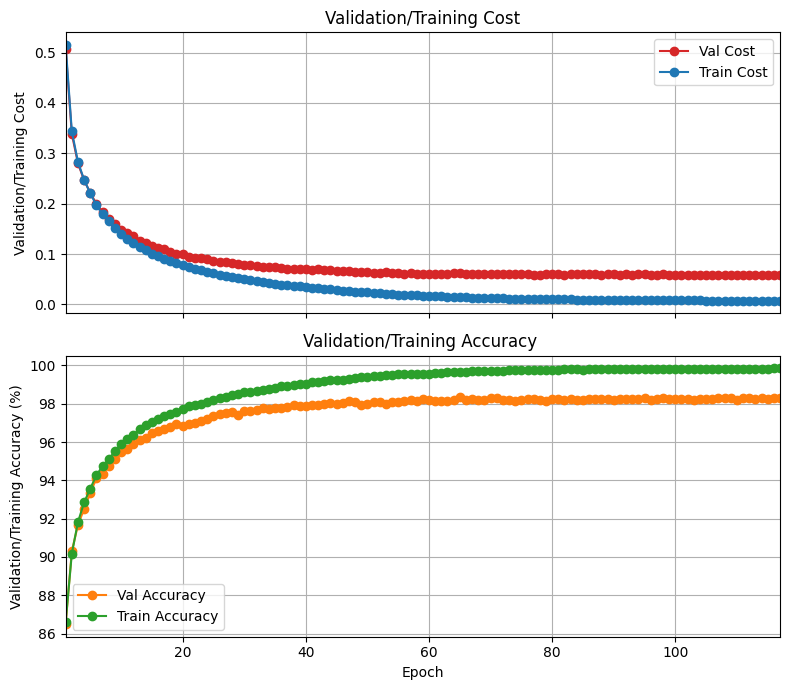

Test Cost = 0.05961579964128425
Test Accuracy = 98.240%


In [ ]:
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True)

test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True)

def load_dataset(path, isLabel=False):
     with open(path, 'rb') as f:
         data = np.frombuffer(f.read(), dtype=np.uint8, offset=16 if not isLabel else 8) #we still need numpy to read the dataset
         return data


#load training dataset
X_train = load_dataset("./data/MNIST/raw/train-images-idx3-ubyte")
Y_train = load_dataset("./data/MNIST/raw/train-labels-idx1-ubyte", True)

#load testing dataset
X_test = load_dataset("./data/MNIST/raw/t10k-images-idx3-ubyte")
Y_test = load_dataset("./data/MNIST/raw/t10k-labels-idx1-ubyte", True)

#copy the training and testing dataset to GPU us CuPy so that all of the next operations over the dataset are GPU supported
X_train, Y_train = cp.asarray(X_train), cp.asarray(Y_train)
X_test, Y_test = cp.asarray(X_test), cp.asarray(Y_test)

#Data preprocessing - GPU supported
X_train = X_train.reshape(60000, 784)
X_test = X_test.reshape(10000, 784)

X_train = X_train.astype(cp.float32) / 255.0
X_test = X_test.astype(cp.float32) / 255.0

eye = cp.identity(10)
Y_train = eye[Y_train]
Y_test = eye[Y_test]

#use DNN class to create DNN object named model
model = DNN()
model.add_layer(784) #input layer 784 neurons
model.add_layer(256, l2_reg_rate=5e-4, pkeep=0.8) #256 neurons, l2 strength = 5e-4, dropout pkeep = 0.8 (80%) for first hidden layer
model.add_layer(128, l2_reg_rate=5e-4, pkeep=0.8) #second hidden layer
model.add_layer(64, l2_reg_rate=5e-4, pkeep=0.9) #third hidden layer
model.add_layer(10) #output layer

model.conf_early_stopping(True, early_stop_patience=10, min_delta=5e-4) #enable and configure early stopping  -  enabled=True, early_stop_patience=6, min_delta = 1e-4
model.conf_adaptive_lr(True,  min_lr=1e-5, lr_reduction_factor=0.5, lr_maxcon_reductions=3) #enable and configure adaptive LR - enabled=True, min_lr = 1e-5, lr_reduction_factor = 0.5, lr_maxcon_reductions = 3
# train_split, initial_lr, batch_size=None, epochs=1
best_params = model.train(X_train, Y_train, 0.9, 0.01, 64, 200) #train split = 0.9 = 90%, initial LR = 0.01, batch size = 64, epochs = 150

#test the new model/NN on the testing dataset with the best parameters
preds, cost = model.forward_pass(X_test, Y_test, best_params, inference=True)
predictions = np.argmax(preds, axis=1)
actual = np.argmax(Y_test, axis=1)
equals = np.equal(predictions, actual)
accuracy = np.mean(equals) * 100

model.plot()
print(f'Test Cost = {cost}\nTest Accuracy = {accuracy:.3f}%')


In [ ]:
#Just an example to read the parameters from saved file and use them to run the inference
params = np.load("model.npz", allow_pickle=True)
params = [list(params["weights"]), list(params["biases"])]
preds, cost = model.forward_pass(X_test, Y_test, params, inference=True)
predictions = np.argmax(preds, axis=1)
actual = np.argmax(Y_test, axis=1)
equals = np.equal(predictions, actual)
accuracy = np.mean(equals) * 100

#Observer that these are almost the same
print(f'Using Best Saved Parameters:-\nTest Cost = {cost}\nTest Accuracy = {accuracy:.3f}% ')

Using Best Saved Parameters:-
Test Cost = 0.05961579964128425
Test Accuracy = 98.240% 


Parameters are saved in the file named "model.npz" you can directly download the file.

## 16.2 Comparing Regularized vs Unregularized Training
Now that we have implemented a complete Deep Neural Network framework supporting L2 Regularization, Dropout, Model Checkpointing, Adaptive Learning Rate and Early Stopping, let us finally observe why these techniques are needed.

To make the comparison fair, we keep the network architecture exactly the same and simply disable all the regularization and training features. The goal here is not to obtain the highest possible accuracy. Instead, we wish to observe how the training and validation curves behave when the Neural Network is allowed to freely memorize the training dataset.

After that, we compare the obtained curves with the fully regularized model trained in the previous section.

Total batches =  844
#---------------------------------TRAINING STARTED---------------------------------#
#---------------------Epoch: 1/50---------------------#
Validation cost:  0.4999704312588607
Validation Accuracy:  86.4
Training cost:  0.5061568059188389
Training Accuracy:  85.7574074074074
CheckPoint @ epoch: 1
#---------------------Epoch: 2/50---------------------#
Validation cost:  0.3389802363078444
Validation Accuracy:  90.08333333333334
Training cost:  0.3394405839678373
Training Accuracy:  90.39259259259259
CheckPoint @ epoch: 2
#---------------------Epoch: 3/50---------------------#
Validation cost:  0.28996266063386567
Validation Accuracy:  91.56666666666666
Training cost:  0.2889568522181199
Training Accuracy:  91.73148148148148
CheckPoint @ epoch: 3
#---------------------Epoch: 4/50---------------------#
Validation cost:  0.2574342150522715
Validation Accuracy:  92.63333333333334
Training cost:  0.25516292484362646
Training Accuracy:  92.71666666666667
CheckPoint @ epo

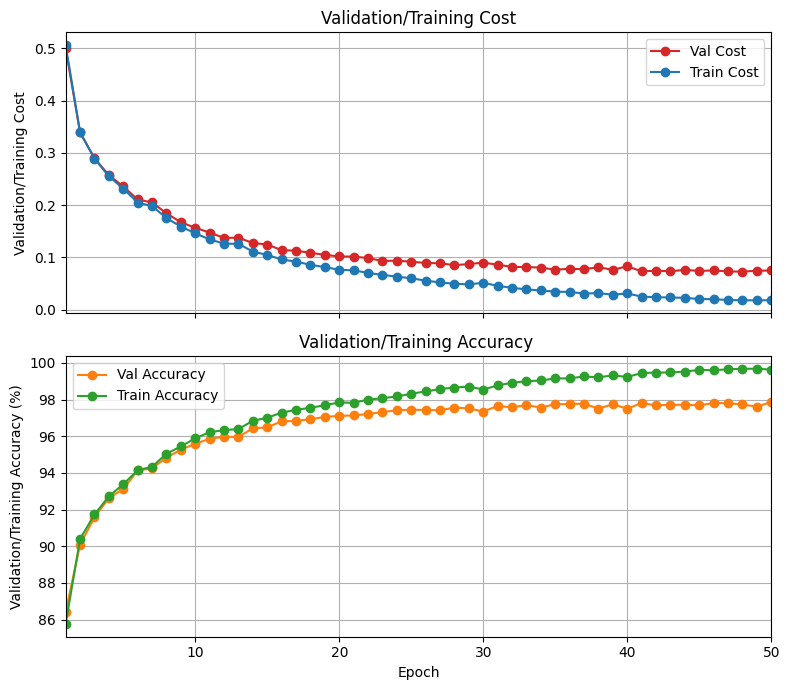

In [ ]:
# Same architecture but WITHOUT any regularization
plain_model = DNN()

plain_model.add_layer(784)
plain_model.add_layer(256)
plain_model.add_layer(128)
plain_model.add_layer(64)
plain_model.add_layer(10)

# Disable all training features
plain_model.conf_early_stopping(False)
plain_model.conf_adaptive_lr(False)

plain_model.train(X_train, Y_train, train_split=0.9, initial_lr=0.01, batch_size=64, epochs=50)

plain_model.plot()

Notice how the training cost continues decreasing rapidly throughout the entire training process. The training accuracy also keeps increasing.

However, the validation cost eventually stops improving and/or begins increasing, while the validation accuracy either stagnates or improves only marginally.

This behaviour indicates that the Neural Network has started memorizing the training dataset instead of learning patterns that generalize well to unseen images. This phenomenon, as explained earlier, is called **Overfitting**.

Now compare these curves with those obtained from our fully regularized model.

Although the regularized model converges slightly more slowly, its validation cost remains significantly more stable throughout training. Once the validation cost stops improving meaningfully, the Adaptive Learning Rate automatically reduces the learning rate, allowing the optimizer to search for an even better minimum. Finally, when no further meaningful improvement is observed, Early Stopping terminates the training process while the best-performing parameters are preserved using Model Checkpointing.

Together, these techniques produce a model that generalizes considerably better to unseen data while also avoiding unnecessary training after convergence.

---

# 17. Conclusion
With this, we conclude our journey into building Deep Neural Networks completely from scratch.

What initially began as a collection of pixels and random numbers has gradually evolved into a fully functional learning system capable of recognizing handwritten digits with remarkable accuracy. More importantly, we have not treated the Neural Network as a mysterious black box. Every major component—from the forward pass and backpropagation to Gradient Descent, mini-batch training, regularization techniques, checkpointing, learning rate scheduling, and early stopping—has been derived, implemented, and understood from first principles.

By building each component ourselves, we have gained something far more valuable than simply learning how to use an existing deep learning library. We now understand why each mathematical equation exists, how it influences the learning process, and what role it plays in helping a Neural Network discover meaningful patterns within data.

The implementation developed throughout this notebook is intentionally generic and flexible. It supports arbitrary network architectures, configurable training hyperparameters, multiple regularization techniques, model checkpointing, adaptive learning rate scheduling, and early stopping, providing a strong foundation upon which considerably more sophisticated models can be built.

Finally, take a moment to appreciate what has been accomplished. Every prediction made by the Neural Network is no longer magic—it is the culmination of thousands of mathematical computations and optimization steps, all working together to transform raw data into intelligent decisions.

---

# Thank You!

Thank you for taking the time to work through this notebook.

If you found it helpful in understanding Neural Networks, Backpropagation, or the mathematics behind Deep Learning, consider giving the GitHub repository a ⭐. It helps more learners discover the project and motivates further improvements.

If you find any mistakes, have suggestions, or would like to contribute, feel free to open an issue or submit a pull request.

Happy Learning!

— **Maitreya Bhatkhande**